<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🏦 Credit Score Classification 💳
    </h1>
</div>


# 📂 Overview

**Background**

This dataset contains **financial and demographic information** of bank customers, prepared for the purpose of predicting **credit score categories**.
It is a **multi-class classification problem**, simulating real-world credit scoring systems used by financial institutions to assess a customer's likelihood of repaying loans.

The dataset has already been **cleaned and preprocessed**, making it suitable for direct model experimentation and performance comparison.

**Goal of the Project**

The goal of this project is to **predict a customer's credit score category** — identifying whether a customer has a **Good**, **Standard**, or **Poor** credit score based on their demographic, financial, and behavioral features.

This can support **risk assessment**, **loan approval decisions**, and **customer segmentation** for banks or credit bureaus.

**Key Features**

| Feature Name               | Description                                                        |
| -------------------------- | ------------------------------------------------------------------ |
| `id`                       | Row identifier (technical index, not used for modeling)            |
| `customer_id`              | Unique customer identifier (keep for customer-level analysis)      |
| `month`                    | Month of record (financial data timestamp)                         |
| `name`                     | Customer name (identifier only)                                    |
| `age`                      | Customer’s age                                                     |
| `ssn`                      | Social security number (unique personal ID, not used for modeling) |
| `occupation`               | Customer’s occupation (e.g., Engineer, Lawyer, Scientist)          |
| `annual_income`            | Customer’s annual income                                           |
| `monthly_inhand_salary`    | Average monthly income credited to the account                     |
| `credit_history_age`       | Duration of the customer’s credit history (in months)              |
| `total_emi_per_month`      | Total monthly EMI payments made by the customer                    |
| `num_bank_accounts`        | Number of bank accounts held by the customer                       |
| `num_credit_card`          | Number of credit cards owned                                       |
| `interest_rate`            | Interest rate on current credit products                           |
| `num_of_loan`              | Number of active loans                                             |
| `type_of_loan`             | Types of loans held (text field containing multiple categories)    |
| `delay_from_due_date`      | Average number of days delayed in payments                         |
| `num_of_delayed_payment`   | Total number of delayed payments                                   |
| `changed_credit_limit`     | Amount by which the credit limit has changed                       |
| `num_credit_inquiries`     | Number of credit inquiries made                                    |
| `credit_mix`               | Type of credit mix (Good / Standard / Bad)                         |
| `outstanding_debt`         | Total unpaid debt amount                                           |
| `credit_utilization_ratio` | Ratio of used credit to total credit limit                         |
| `payment_of_min_amount`    | Whether the customer pays only the minimum amount due              |
| `amount_invested_monthly`  | Average monthly investment made by the customer                    |
| `payment_behaviour`        | Customer’s payment pattern or spending behavior                    |
| `monthly_balance`          | Average monthly balance maintained                                 |
| `credit_score` (🎯 Target) | Credit score class: 🟢 Good, 🟡 Standard, 🔴 Poor                  |

**Files Provided**

* `credit_score_cleaned_train.csv` — Main dataset for training and EDA, containing both features and target variable (`Credit_Score`).

**Project Objective**

The objective is to **build a robust machine learning pipeline** to classify customers’ creditworthiness into *Good*, *Standard*, or *Poor* groups, enabling better decision-making in:

* Loan approval and interest rate assignment
* Early detection of high-risk borrowers
* Credit product recommendations
* Customer segmentation and marketing

**Key Steps**

* **Exploratory Data Analysis (EDA)**
  Understand customer profiles, income distribution, debt levels, and payment behavior.

* **Feature Engineering**

  * Handle categorical encoding (`Occupation`, `Credit_Mix`, etc.)
  * Normalize financial values (`Annual_Income`, `Outstanding_Debt`)
  * Derive new ratios or trends (e.g., Debt-to-Income, Payment Delay Rate)

* **Modeling**
  Apply and compare multiple classifiers such as:

  * Logistic Regression
  * Random Forest
  * XGBoost
  * LightGBM
  * CatBoost
  * Neural Networks (MLPClassifier)

* **Evaluation Framework**

  * Use **Stratified K-Fold Cross Validation**
  * Metrics:

    * Accuracy
    * Precision
    * Recall
    * F1-Score
    * ROC-AUC
    * Confusion Matrix for class balance analysis

**Business Impact**

Accurate credit score classification can help financial institutions:

* Reduce loan default risks
* Optimize interest rate policies
* Identify potential premium customers
* Enhance credit product targeting and profitability.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [55]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Statistical functions
from scipy.stats import skew, kurtosis, probplot

# Display utilities for Jupyter notebooks
from IPython.display import display, HTML

# Machine learning preprocessing and modeling
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Metrics
from sklearn.metrics import (roc_curve, roc_auc_score, classification_report, confusion_matrix,
                             precision_recall_curve, auc, average_precision_score)

# Statistical
from scipy.stats import chi2_contingency
from scipy.stats import probplot
from scipy.stats import kruskal
import scikit_posthocs as sp
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import levene
from scipy import stats
import pingouin as pg
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

In [56]:
class Config:
    SEED = 42
    MAX_ITER = 50000
    N_SPLIT = 1
    TEST_SIZE = 0.2

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [57]:
# Load the datasets
df = pd.read_csv("credit_score_cleaned_train.csv")

# Verify shapes
print("Data Shape:", df.shape)

Data Shape: (96696, 28)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [58]:
# Display few rows of dataset
print("Data Preview:")
display(df.head())

Data Preview:


,id,customer_id,month,name,age,ssn,occupation,annual_income,monthly_inhand_salary,credit_history_age,total_emi_per_month,num_bank_accounts,num_credit_card,interest_rate,num_of_loan,type_of_loan,delay_from_due_date,num_of_delayed_payment,changed_credit_limit,num_credit_inquiries,credit_mix,outstanding_debt,credit_utilization_ratio,payment_of_min_amount,amount_invested_monthly,payment_behaviour,monthly_balance,credit_score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.8434,89,49.574947,3,4,3,4,"['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']",3,7,11.27,4,Good,809.98,26.822620,No,80.415300,High_spent_Small_value_payments,312.49408,2
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.8434,93,49.574947,3,4,3,4,"['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']",-1,7,11.27,4,Good,809.98,31.944960,No,118.280220,Low_spent_Large_value_payments,284.62915,2
2,0x1604,CUS_0xd40,March,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.8434,91,49.574947,3,4,3,4,"['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']",3,7,11.27,4,Good,809.98,28.609352,No,81.699524,Low_spent_Medium_value_payments,331.20987,2
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.8434,92,49.574947,3,4,3,4,"['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']",5,4,6.27,4,Good,809.98,31.377861,No,199.458070,Low_spent_Small_value_payments,223.45131,2
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.8434,93,49.574947,3,4,3,4,"['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']",6,4,11.27,4,Good,809.98,24.797346,No,41.420155,High_spent_Medium_value_payments,341.48923,2


In [59]:
# Replace space to under score.
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Display information about the DataFrames
print("Data Info:")
df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96696 entries, 0 to 96695
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        96696 non-null  object 
 1   customer_id               96696 non-null  object 
 2   month                     96696 non-null  object 
 3   name                      96696 non-null  object 
 4   age                       96696 non-null  int64  
 5   ssn                       96696 non-null  object 
 6   occupation                96696 non-null  object 
 7   annual_income             96696 non-null  float64
 8   monthly_inhand_salary     96696 non-null  float64
 9   credit_history_age        96696 non-null  int64  
 10  total_emi_per_month       96696 non-null  float64
 11  num_bank_accounts         96696 non-null  int64  
 12  num_credit_card           96696 non-null  int64  
 13  interest_rate             96696 non-null  int64  


## Insights from Initial Data Exploration

**Dataset Size and Structure**  
   - The **dataset** contains **96696** samples with **28** columns, including the target variable `credit_score`.

**Feature Overview**  
   - Both datasets include all important attributes:
     - **Numerical features:** `age`, `annual_income`, `monthly_inhand_salary`, `credit_history_age`, `total_emi_per_month`, `num_bank_accounts`, `num_credit_card`, `interest_rate`, `num_of_loan`,  `delay_from_due_date`, `num_of_delayed_payment`, `changed_credit_limit`, `num_credit_inquiries`,`outstanding_debt`, `credit_utilization_ratio`, `amount_invested_monthly`, `monthly_balance`.
     - **Categorical features:** `occupation`, `credit_mix`, `payment_of_min_amount`, `payment_behaviour`, `type_of_loan`, `month`.
   - The target variable is **categorical** variable (`credit_score`).

**Data Completeness**  
   - Data types are appropriate: numerical features are int64 and float64 and categorical features is object.
   - The column `id`, `name`, `ssn` and `customer_id` is not meaningful for analysis. So this column is not really a part of the information we should care about. We can drop this column for data.

In [60]:
num_features = ["age", "annual_income", "monthly_inhand_salary", "credit_history_age", "total_emi_per_month", "num_bank_accounts",
                "num_credit_card", "interest_rate", "num_of_loan", "delay_from_due_date", "num_of_delayed_payment",
                "changed_credit_limit", "num_credit_inquiries", "outstanding_debt", "credit_utilization_ratio",
                "amount_invested_monthly", "monthly_balance"]
cat_features = ["occupation", "credit_mix", "payment_of_min_amount", "payment_behaviour", "type_of_loan", "month"]
list_features_frop = ["id", "name", "ssn", "customer_id"]
df.drop(columns=list_features_frop, axis=1, inplace=True)
print("Data describe:")
cm = sns.light_palette("blue", as_cmap=True)
display(df[num_features].describe().T.style.background_gradient(cmap=cm))

Data describe:


,count,mean,std,min,25%,50%,75%,max
age,96696.000000,33.942448,10.377550,16.000000,25.000000,34.000000,42.000000,56.000000
annual_income,96696.000000,50898.597475,38543.773796,7006.035000,19480.040000,37367.340000,72245.760000,179987.280000
monthly_inhand_salary,96696.000000,4231.402393,3207.836030,303.645420,1634.720800,3116.120850,6016.623500,15204.634000
credit_history_age,96696.000000,78.471529,33.291894,-1.000000,53.000000,78.000000,106.000000,147.000000
total_emi_per_month,96696.000000,106.502641,130.404213,0.000000,28.636501,65.712006,145.756870,3776.000000
num_bank_accounts,96696.000000,5.319134,2.597916,0.000000,3.000000,5.000000,7.000000,11.000000
num_credit_card,96696.000000,5.498211,2.057083,0.000000,4.000000,5.000000,7.000000,11.000000
interest_rate,96696.000000,14.347646,8.708524,1.000000,7.000000,13.000000,20.000000,34.000000
num_of_loan,96696.000000,3.481344,2.435098,0.000000,2.000000,3.000000,5.000000,9.000000
delay_from_due_date,96696.000000,20.806931,14.785004,-5.000000,10.000000,18.000000,28.000000,67.000000


## Descriptive Insights from Dataset Statistics

* **Age:** Average 34 years → most customers are young adults.
* **Annual_Income:** Mean around $50K, wide spread (19K–180K) → high income disparity.
* **Monthly_Inhand_Salary:** Around $4.2K/month, consistent with annual income.
* **Credit_History_Age:** About 78 months (~6.5 years) → relatively stable credit history.
* **Num_Bank_Accounts / Num_Credit_Card:** Average ~5–6 → customers hold multiple financial products.
* **Interest_Rate:** Mean 14%, large standard deviation → credit risk varies widely.
* **Delay_from_due_date & Num_of_Delayed_Payment:** Average delay 20 days with ~13 late payments → signals potential high-risk borrowers.
* **Outstanding_Debt:** Mean ~1.4K, up to 5K → worth investigating high-debt segment.
* **Credit_Utilization_Ratio:** Average 32% → most customers use about one-third of their credit limit.
* **Amount_Invested_Monthly:** Highly variable (mean 641, max 10,000) → strong differences in investment behavior.
* **Monthly_Balance:** Average 406 → customers maintain relatively stable balances.

**Summary:**
Data shows high financial diversity; variables like **delays**, **interest_rate**, and **credit_utilization_ratio** are likely strong predictors of **Credit_Score**.

In [61]:
print("\nData describe:")
def convert_cat(features, df = df):
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")
convert_cat(cat_features)

display(df[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))


Data describe:


,count,unique,top,freq
occupation,96696,15,Lawyer,6888
credit_mix,96696,3,Standard,44048
payment_of_min_amount,96696,2,Yes,56128
payment_behaviour,96696,6,Low_spent_Small_value_payments,26503
type_of_loan,96696,5981,['No Loan'],11312
month,96696,8,April,12087


## Descriptive Insights for Categorical Features

* **Occupation:** 15 job types, most common is *Lawyer* (~6.9K) → diverse professional backgrounds.
* **Credit_Mix:** 3 categories (*Good / Standard / Bad*), with *Standard* dominant (~45%) → most customers have average credit profiles.
* **Payment_of_Min_Amount:** 2 values (*Yes / No*), over **58% only pay the minimum due** → potential financial risk indicator.
* **Payment_Behaviour:** 6 behavioral patterns, most frequent is *Low_spent_Small_value_payments* (~27%) → tendency toward small, frequent spending.
* **Type_of_Loan:** ~6K unique combinations, most common is *["No Loan"]* (~11K) → majority have no active loans.
* **Month:** 8 recorded months, highest frequency in *April* (~12K) → data roughly evenly distributed over time.

**Summary:**
Categorical variables show clear diversity in **occupation, credit behavior, and payment habits**, providing strong signals for differentiating between low- and high-risk customers.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Missing Value

In [62]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 40)
    if dataset_name:
        print(f"🔎 Missing Value Summary for: {dataset_name}")
    else:
        print("🔎 Missing Value Summary:")
    print("=" * 40)
    
    if total_missing == 0:
        print(f"✅ No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))
        
        print(f"\n⚠️  Total missing values: {total_missing:,} out of {total_rows:,} rows.")

displayNULL(df, dataset_name="Dataset")

🔎 Missing Value Summary for: Dataset
✅ No missing values detected in 96,696 rows.


## Checking duplicate Value

In [63]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    print("=" * 40)
    print(f"🔍 {dataset_name} Duplicate Analysis")
    print("=" * 40)
    
    if duplicates_count == 0:
        print(f"✅ No duplicates found in {total_rows:,} rows")
    else:
        print(f"⚠️  {duplicates_count} duplicates found ({duplicates_count/total_rows:.2%})")
        print(f"    Total rows affected: {duplicates_count:,}/{total_rows:,}")

datasets = {
    "Data": df
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }

🔍 Data Duplicate Analysis
✅ No duplicates found in 96,696 rows


## Checking Outlier Value

In [64]:
def checking_outlier(list_feature, df, dataset_name):
    print("=" * 40)
    print(f"🔍 {dataset_name} Checking outlier")
    print("=" * 40)
    outlier_info = []
    
    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        
        if len(outliers) > 0:
            outlier_info.append({
                "Feature": feature,
                "Outlier Count": len(outliers),
                # "Outlier Detail": outliers.tolist()
            })

    if len(outlier_info) == 0:
        print("✅ No outliers detected in the selected features.")
    else:
        return pd.DataFrame(outlier_info)

checking_outlier(list_feature=num_features, df=df, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,annual_income,1912
1,monthly_inhand_salary,1911
2,total_emi_per_month,4968
3,delay_from_due_date,3796
4,changed_credit_limit,1005
5,num_credit_inquiries,704
6,outstanding_debt,5592
7,credit_utilization_ratio,4
8,amount_invested_monthly,10248
9,monthly_balance,7280


## Data Quality Insights: Missing Values, Duplicates and Outliers.

**Missing Values Analysis**

* We conducted a thorough examination for missing values in the dataset.

* **No missing values** were detected — ensuring clean synthetic data for model training.

**Duplicate Records Analysis**

* We performed a check for exact duplicate rows that could artificially inflate performance or introduce bias.

  * **No duplicates** detected in 2512 rows — ensuring test predictions are made on unique samples.

**Outlier Analysis**

* We also examined the datasets for checking outliers.
* **The outliers** were found in dataset at features. But we can not remove them since these outliers reflect reality.
* The datasets contain **notable outliers** in `annual_income`, `monthly_inhand_salary`, `total_emi_per_month`, `delay_from_due_date`, `changed_credit_limit`, `num_credit_inquiries`, `outstanding_debt`, `credit_utilization_ratio`, `amount_invested_monthly`, `monthly_balance`.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [65]:
def color(n_colors=2):
    return sns.color_palette("RdYlGn", n_colors=n_colors)

In [66]:
def cal_ChiSquare(cat_feature, target_feature, df, show_expected=False, show_residuals=False):
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    print(f"\n🔍 Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    print(f"Chi-squared statistic: {chi2:.3f}")
    print(f"Degrees of freedom: {dof}")
    print(f"p-value: {p:.6f}")

    if p < 0.05:
        print("✅ Result: p-value < 0.05 → Reject H₀")
        print(f"→ There is a **statistically significant association** between '{cat_feature}' and '{target_feature}'.")
    else:
        print("❎ Result: p-value ≥ 0.05 → Fail to reject H₀")
        print(f"→ No statistically significant association between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        print("\n📊 Expected Frequencies:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))
    else:
        pass

    # Optional: show standardized residuals
    if show_residuals:
        cmap = sns.color_palette("RdYlGn", as_cmap=True)
        residuals = (crosstab - expected) / np.sqrt(expected)
        print("\n📈 Standardized Residuals:")
        print(round(residuals, 2))

        # Heatmap of residuals
        plt.figure(figsize=(10, 5))
        sns.heatmap(residuals, annot=True, cmap=cmap, center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=13, pad=25)
        plt.ylabel(cat_feature)
        plt.xlabel(target_feature)
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df, categorical_feature, numeric_feature):
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        print(f"❌ Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        print(f"\n🔍 Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        print(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        print(f"p-value: {p}")

        if p < 0.05:
            print("🟢 Significant difference found. Running Dunn's Post-Hoc Test...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            print("\nℹ️ No significant difference found (p >= 0.05)")

def check_normality_with_plots(df, feature, target_feature, threshold_skew_1=0.5, threshold_skew_2=1.0,
                               threshold_kurt=1.5, ncols=2):
    """
    Check the normality of numerical features *within each group* of a categorical feature,
    using Skewness, Kurtosis, and Q–Q plots. 
    If non-normality is detected in any group, automatically perform Kruskal–Wallis test.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing both numeric and categorical features.

    feature : numeric
        Numerical columns to test (e.g. ["Temparature"]).

    target_feature : str
        Categorical variable name (e.g. "Fertilizer_Name").

    threshold_skew_1 : float, default = 0.5
        Threshold for approximately symmetric (|skew| ≤ 0.5).

    threshold_skew_2 : float, default = 1.0
        Threshold for moderate skewness (0.5 < |skew| ≤ 1.0).

    threshold_kurt : float, default = 1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default = 2
        Number of Q–Q plots per row.
    """

    results = []
    non_normal_detected = False

    print(f"\n Checking normality of numeric feature(s) by target feature: '{target_feature}'")

    # ===  Evaluate normality within each group ===
    print(f"\n🔹 Feature: {feature}")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=11, weight="bold")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=13, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    if non_normal_detected == True:
        print("\n⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...")
    else:
        print("\n✅ All groups approximately follow normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df, numeric_feature, categorical_feature, typ=2):
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        print(f"❌ Error: ANOVA requires 3 or more groups.")
        return
    else:
        print(f"\n🔍 ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})")

        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        print("\n📊 ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            print("\n✅ Significant difference found (p < 0.05)")
            print("➡️ Performing Tukey's HSD post-hoc test:")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            print("\nℹ️ No significant difference found (p >= 0.05)")

def perform_welch_anova(df, numeric_feature, categorical_feature):
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        print("❌ Error: Welch’s ANOVA requires 3 or more groups.")
        return

    print(f"\n🔍 Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    print("Testing mean differences under heteroscedasticity assumption...")

    # Perform Welch's ANOVA (scipy.stats)
    welch_result = stats.f_oneway(*groups)
    print("\nWelch’s ANOVA Result:")
    print(f"F-statistic = {welch_result.statistic:.4f},  p-value = {welch_result.pvalue:.6f}")

    # Interpret result
    if welch_result.pvalue < 0.05:
        print("\n✅ Significant difference found (p < 0.05)")
        print("➡️ Performing Games–Howell post-hoc test:\n")

        # Perform Games–Howell post-hoc test (robust for unequal variances)
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)
        # display(gh_result)

        display(HTML("<b>Games–Howell Post-hoc Test (adjusted p-values)</b>"))
        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        print("\nℹ️ No significant difference found (p ≥ 0.05)")


def check_homogeneity_of_variance(df, feature, target_feature, alpha=0.05, ratio_threshold=2.0):
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.
    feature : str
        Numeric variable to test (e.g. "Temparature").
    target_feature : str
        Categorical grouping variable (e.g. "Fertilizer_Name").
    alpha : float, default = 0.05
        Significance level for hypothesis testing.
    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → ANOVA suitable
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → still OK for ANOVA
        - If ratio ≥ 2 OR p < 0.05  →  Use Welch’s ANOVA or Kruskal–Wallis
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="mean")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "✅ Homogeneous variances."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "⚠️ Statistically significant difference, but practically small — ANOVA or T-Test still acceptable."
        recommendation = "Use Welch’s ANOVA or Welch’s T-Test."
        anova_use = True
    else:
        status = "🚨 Variances differ substantially — Use non-parametric test."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test (Wilcoxon rank-sum test)."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Blues")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    print("\n🔍 Interpretation:")
    print(f"   {status}")
    print(f"   Recommendation → {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe, categorical_feature, num_feature):
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """

    groups = dataframe[categorical_feature].dropna().unique()

    if len(groups) != 2:
        print(f"❌ Error: Mann-Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    print(f"🔍 Mann–Whitney U Test for '{num_feature}' by '{categorical_feature}'\n")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    print(f"U statistic : {stat}")
    print(f"p-value     : {p}")

    # Interpretation
    if p <= 0.05:
        print("\n✅ Result: Statistically significant difference between the two groups (Reject H₀).")
        median1 = group1.median()
        median2 = group2.median()
        if median1 > median2:
            print(f" Interpretation: Group '{groups[0]}' has a higher median '{num_feature}' than Group '{groups[1]}'.")
        elif median1 < median2:
            print(f" Interpretation: Group '{groups[1]}' has a higher median '{num_feature}' than Group '{groups[0]}'.")
        else:
            print(" Interpretation: The medians are equal, but distributions may still differ.")
    else:
        print("\n⚪ Result: No statistically significant difference between the two groups (Fail to reject H₀).")

def t_test_with_cohens_d(data, categorical_feature, num_feature, equal_var=False):
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        print(f"❌ Error: Independent T-Test requires exactly 2 groups.")
        return

    print(f"🔍 Independent Two-Sample T-Test: {num_feature} ~ {categorical_feature}")
    print(f"→ Test Type: {'Student’s T-Test (equal variances)' if equal_var else 'Welch’s T-Test (unequal variances)'}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Output
    print(f"\nComparing groups: '{groups[0]}' vs. '{groups[1]}'")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Cohen's d: {cohens_d:.3f}")

    # Significance interpretation
    if p_value < 0.05:
        print("\n✅ Significant difference found (p < 0.05)")
    else:
        print("\nℹ️ No significant difference found (p ≥ 0.05)")

    # Effect size interpretation
    if abs(cohens_d) < 0.2:
        size = "small"
    elif abs(cohens_d) < 0.5:
        size = "medium"
    else:
        size = "large"

    print(f"Effect size interpretation: {size} effect ({abs(cohens_d)})")

## Credit Score Distribution

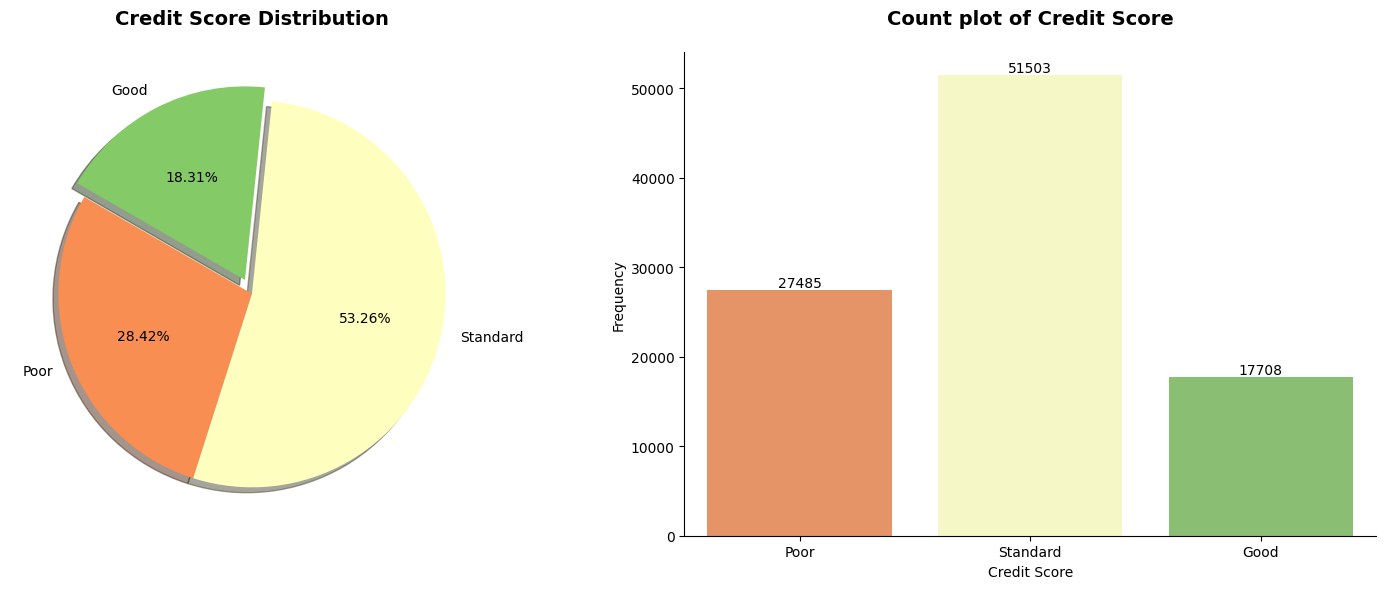

In [67]:
credit_score_distribution  = df["credit_score"].value_counts().sort_index(ascending=True)
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 6))
n_color = color(n_colors=df["credit_score"].nunique())
# ax[0]
ax[0].pie(credit_score_distribution, labels = ["Poor", "Standard", "Good"], colors = n_color,  autopct = "%1.2f%%",
          startangle = 150, explode = (0, 0, 0.08), shadow= True)
ax[0].set_title("Credit Score Distribution",  weight="bold", fontsize=14, pad=20)

# ax[1]
sns.countplot(data=df, x = "credit_score", palette=n_color, 
              ax=ax[1])
ax[1].set_title("Count plot of Credit Score", weight="bold", fontsize=14, pad=20)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%d", label_type="edge", fontsize=10)
ax[1].set_ylabel("Frequency")
ax[1].set_xticks([0, 1, 2], ["Poor", "Standard", "Good"])
ax[1].set_xlabel("Credit Score")
sns.despine(ax=ax[1], top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.show()

**Credit Score Distribution**

* **Standard (1):** Represents the majority with **53.26% (~51.5K customers)** → most customers have an **average credit score**, indicating generally reliable repayment behavior but not strong enough to be classified as “Good.”
* **Poor (0):** Accounts for **28.42% (~27.5K customers)** → customers with **high credit risk**, likely to face loan denials or stricter lending conditions.
* **Good (2):** Only **18.31% (~17.7K customers)** → relatively few customers have **strong, high-quality credit profiles**.

**Overall Insights:**

* The dataset shows a **class imbalance**, with the *Standard* group making up over half of all records.
* The distribution reflects a realistic scenario: most customers hold average credit scores, while truly good or poor credit profiles are less common.

## Numerical Feature Distributions

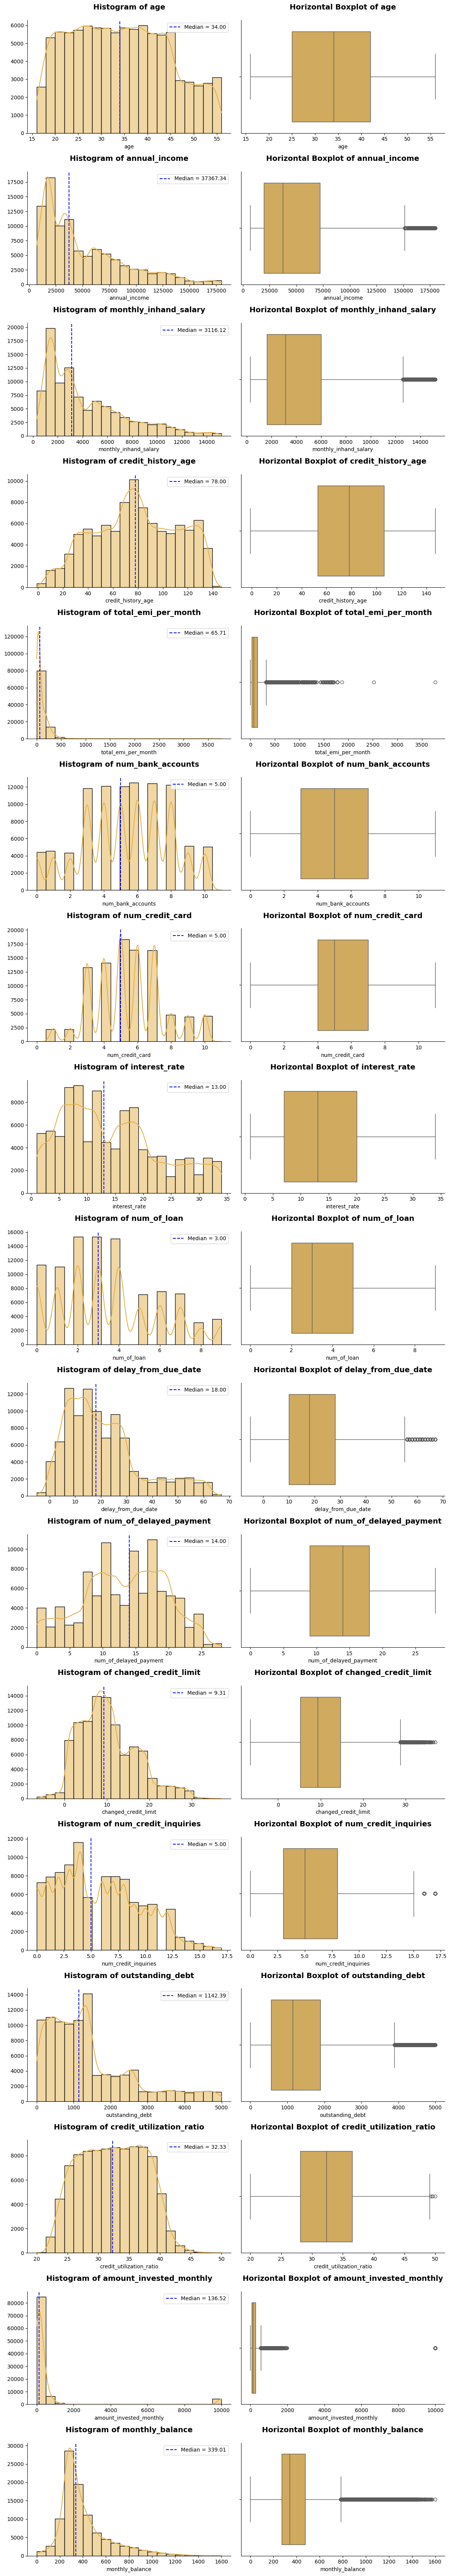

In [68]:
def plot_numerical_features(df=df, numerical_features = num_features):
    fig, ax = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(numerical_features):
        sns.histplot(data=df[feature], color="#E3B04B", bins = 20, kde=True, ax=ax[i, 0])
        ax[i, 0].set_title(f"Histogram of {feature}", weight="bold", fontsize=14, pad=20)
        ax[i, 0].set_ylabel("")
        median_val = df[feature].median()
        ax[i, 0].axvline(median_val, color="blue", linestyle="--", label=f"Median = {median_val:.2f}")
        ax[i, 0].legend()
        sns.despine(ax=ax[i, 0], top=True, right=True, left=False, bottom=False)

        sns.boxplot(data=df[feature], color="#E3B04B", orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Boxplot of {feature}", weight="bold", fontsize=14, pad=20)
        ax[i, 1].set_xlabel(feature)
        sns.despine(ax=ax[i, 1], top=True, right=True, left=False, bottom=False)

    plt.tight_layout()
    plt.show()

plot_numerical_features()

In [69]:
def check_skewness(data = df, numerical_features = num_features, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)
    else:
        pass
    
    print(f"\n🔍 Skewness for dataset:")
    print("-"*75)
    print(f"{'Feature':<35} | {'Skewness':<10} | {'Remark'}")
    print("-"*75)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"  
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"  
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<35} | {skew:>+10f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<35} | {skew:>+10f} | {remark}")
    print("-"*75)
    return skew_feature, skew_df

skew_feature, skew_df = check_skewness()


🔍 Skewness for dataset:
---------------------------------------------------------------------------
Feature                             | Skewness   | Remark
---------------------------------------------------------------------------
amount_invested_monthly             |  +4.306335 | Highly skewed
total_emi_per_month                 |  +4.142171 | Highly skewed
monthly_balance                     |  +1.570108 | Highly skewed
outstanding_debt                    |  +1.242221 | Highly skewed
annual_income                       |  +1.117978 | Highly skewed
monthly_inhand_salary               |  +1.116250 | Highly skewed
delay_from_due_date                 |  +0.992354 | Moderately skewed
changed_credit_limit                |  +0.661909 | Moderately skewed
interest_rate                       |  +0.520011 | Moderately skewed
num_of_loan                         |  +0.469714 | Approximately symmetric
num_credit_inquiries                |  +0.437872 | Approximately symmetric
num_credit_card   

**Shape and Spread of Distributions**

* **Histograms** show that most numerical features are **right-skewed**, especially for income, debt, and investment-related variables.
  This indicates that a large portion of customers fall into **lower or mid-value ranges**, while a few have very high values (long right tail).
* **Boxplots** confirm the presence of **outliers** in several financial variables such as `total_emi_per_month`, `amount_invested_monthly`, and `outstanding_debt`, highlighting strong variability across customers.

**Skewness Analysis**

* Several financial features exhibit **high positive skewness**, meaning the data is concentrated toward smaller values with few large outliers:

  * `amount_invested_monthly`, `total_emi_per_month`, `monthly_balance`, `outstanding_debt`, `annual_income`, and `monthly_inhand_salary` → **Highly skewed**
* Moderate skewness is observed in:

  * `delay_from_due_date`, `changed_credit_limit`, and `interest_rate` → **Moderately skewed**
* The remaining features such as `age`, `num_bank_accounts`, `num_credit_card`, `credit_history_age`, and `credit_utilization_ratio` are **approximately symmetric**, which is favorable for model training.

## Correlation Analysis of Numerical Features

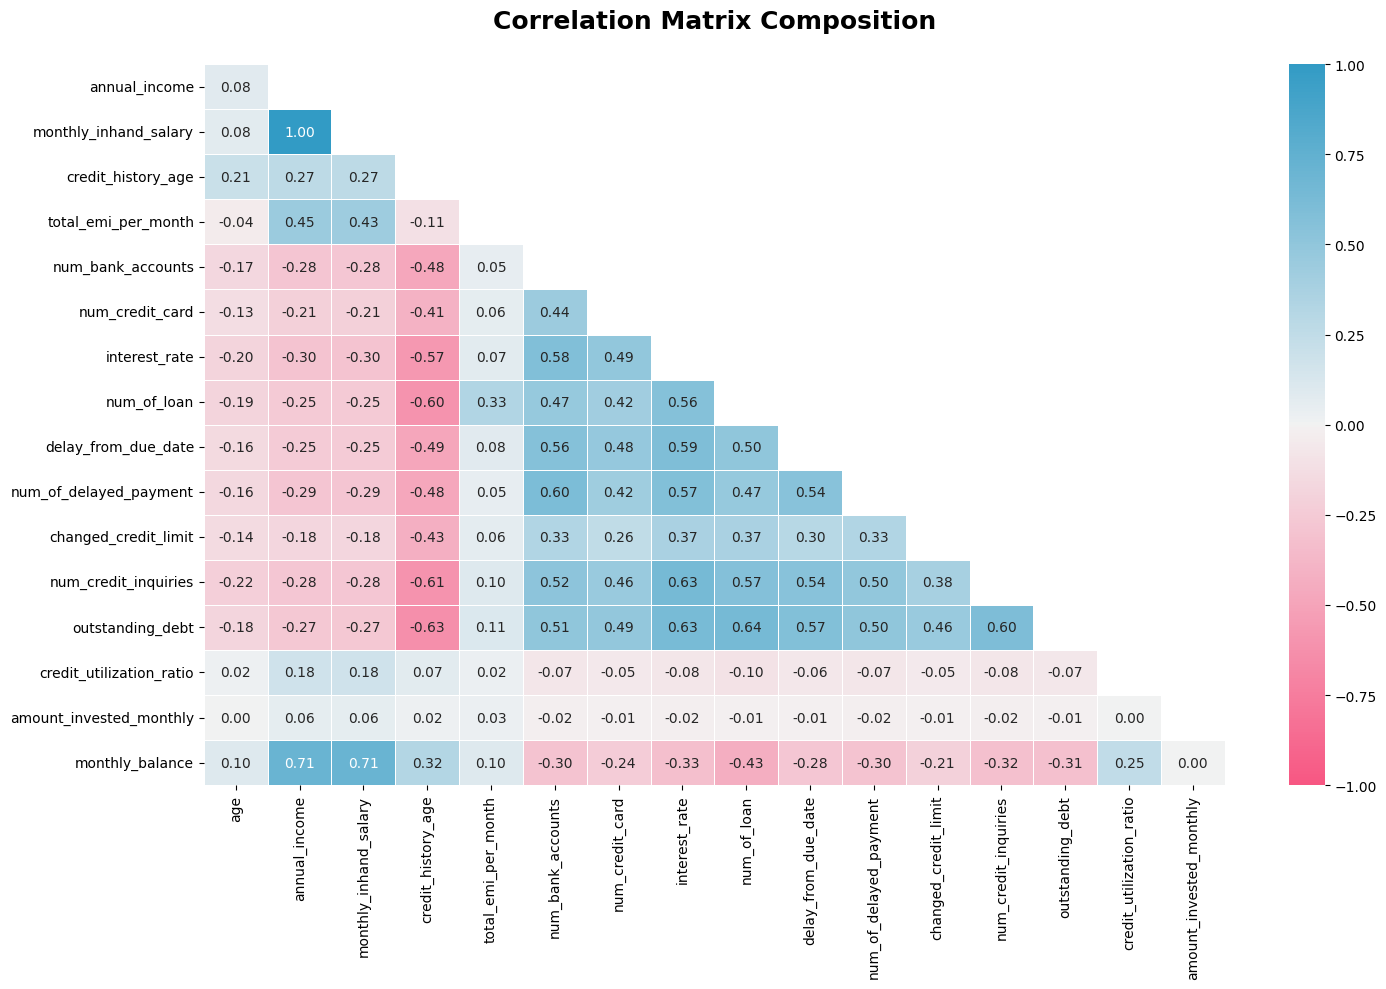

In [70]:
corr_matrix = df[num_features].corr(numeric_only=True)
# one_like can build a matrix of boolean(True, False) with the same shape as our data
ones_corr = np.ones_like(corr_matrix, dtype=bool)
mask = np.triu(ones_corr)
adjusted_mask = mask[1:, :-1]
adjusted_cereal_corr = corr_matrix.iloc[1:, :-1]

fig, ax = plt.subplots(figsize = (15, 10))
# That method uses HUSL colors, so you need hue, saturation, and lightness. 
# I used hsluv.org to select the colors of this chart.
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

sns.heatmap(data=adjusted_cereal_corr, mask=adjusted_mask,
            annot=True, fmt=".2f", cmap=cmap,
            vmin=-1, vmax=1, linecolor="white", linewidths=0.5)

title = "Correlation Matrix Composition\n"
ax.set_title(title, loc="center", fontsize=18, weight="bold")
plt.tight_layout()
plt.show()

**Correlation Analysis – Key Insights**

* **Strong positive correlations**:

  * `monthly_inhand_salary` ↔ `annual_income` (**r = 1.00**) – perfectly correlated, indicating redundancy (one can be removed).
  * `monthly_balance` ↔ `monthly_inhand_salary` (**r ≈ 0.71**) – higher income leads to higher monthly balance.
  * `num_of_delayed_payment`, `delay_from_due_date`, and `num_of_loan` show **moderate positive correlation** (r ≈ 0.5–0.6), suggesting consistent payment delay behavior.

* **Strong negative correlations**:

  * `outstanding_debt` ↔ `total_emi_per_month` (**r = -0.63**) and `num_of_loan` (**r = -0.60**) – customers with higher EMI or more loans tend to carry less unpaid debt (likely paying regularly).
  * `interest_rate` ↔ `total_emi_per_month` (**r = -0.57**) – higher EMI values are often linked to lower interest rates (possible secured or consolidated loans).

* **Weak or near-zero correlations**:

  * Variables like `age`, `credit_utilization_ratio`, and `amount_invested_monthly` show **low correlation** with most others → potentially independent predictors.

**Summary:**
The dataset shows **some multicollinearity** among income- and debt-related features.

## Categorical Feature Distributions

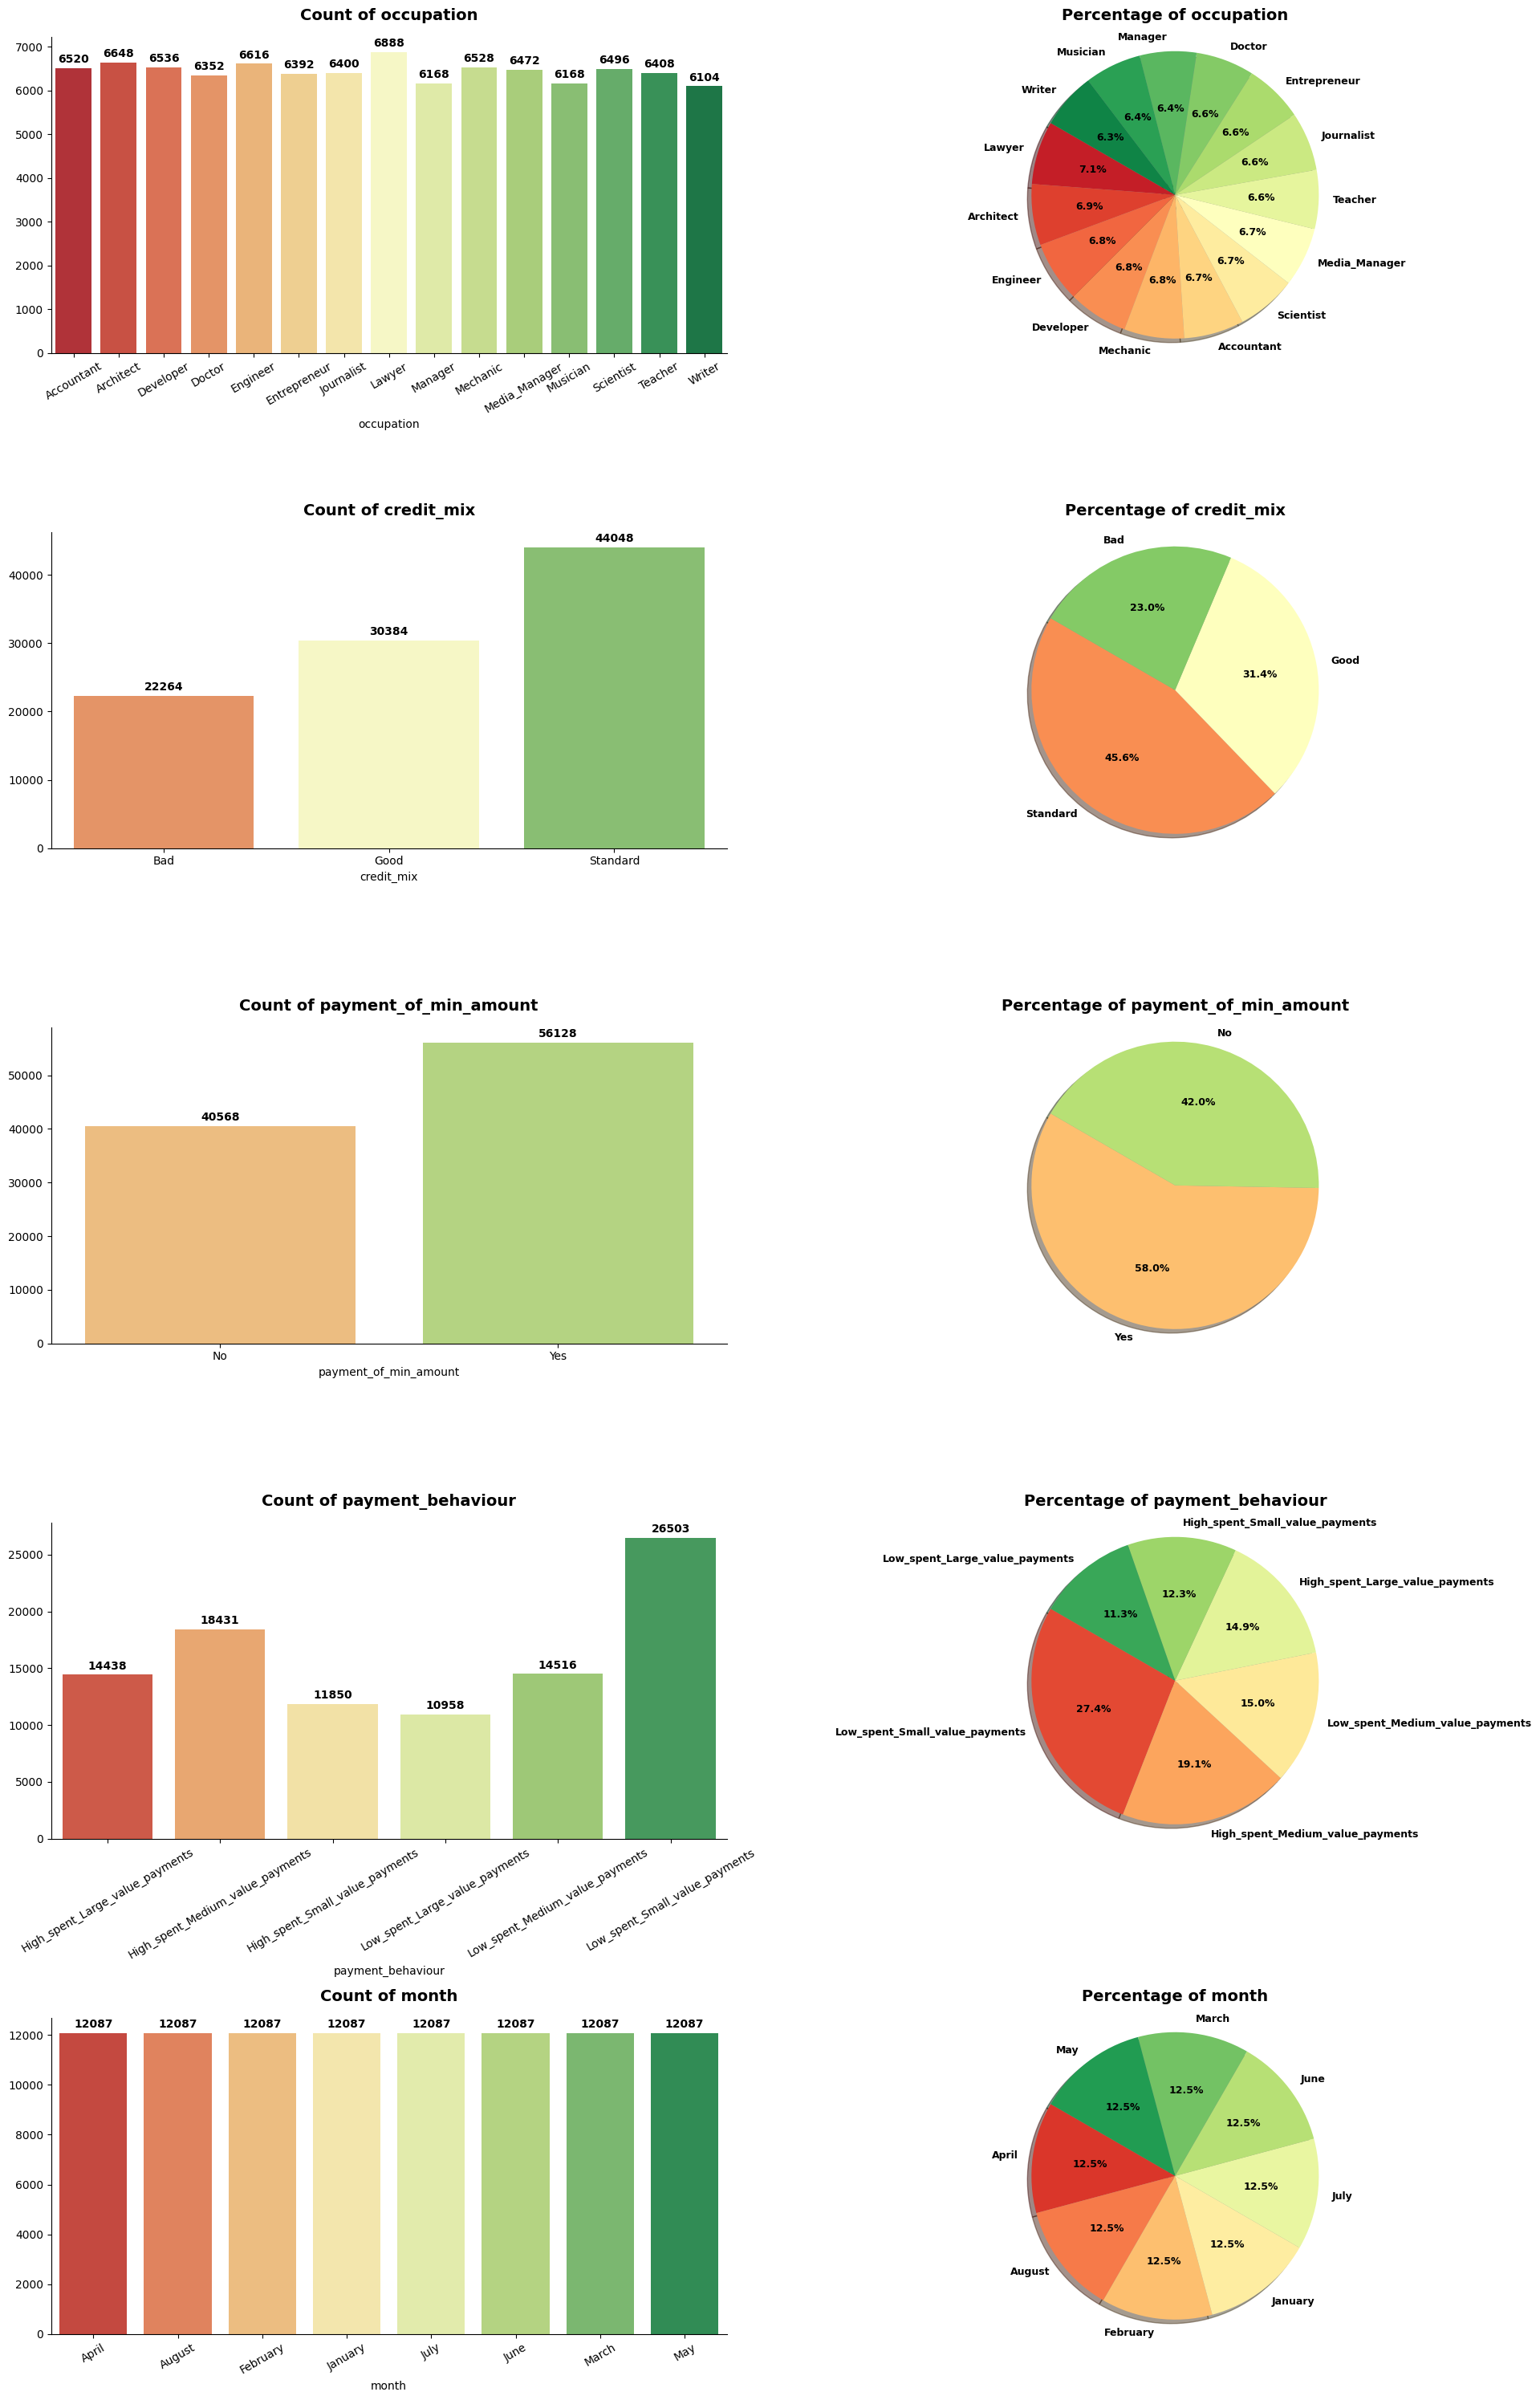

In [71]:
cat_features = ["occupation", "credit_mix", "payment_of_min_amount", "payment_behaviour", "month"]

def plot_categorical_distribution(df, cat_features):
    fig, ax = plt.subplots(len(cat_features), 2, figsize=(20, len(cat_features) * 6))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(cat_features):
        # ----------------------------
        # LEFT: Countplot
        # ----------------------------
        sns.countplot(
            data=df, x=feature, ax=ax[i, 0],
            palette=color(n_colors=len(df[feature].unique()))
        )
        ax[i, 0].set_title(f"Count of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 0].set_xlabel(feature)
        ax[i, 0].set_ylabel("")
        if len(df[feature].unique()) > 4:
            ax[i, 0].set_xticklabels(ax[i, 0].get_xticklabels(), rotation=30)
        sns.despine(ax=ax[i, 0], top=True, right=True)

        # Add count labels
        for p in ax[i, 0].patches:
            height = p.get_height()
            x = p.get_x() + p.get_width() / 2
            ax[i, 0].text(x, height + max(df[feature].value_counts()) * 0.01,
                          f"{int(height)}", ha="center", va="bottom",
                          fontsize=10, fontweight="bold")

        # ----------------------------
        # RIGHT: Pie Chart
        # ----------------------------
        feature_counts = df[feature].value_counts(normalize=True)
        labels = feature_counts.index
        sizes = feature_counts.values * 100  # percentage
        colors = color(n_colors=len(df[feature].unique()))

        wedges, texts, autotexts = ax[i, 1].pie(
            sizes, labels=labels, autopct="%1.1f%%", shadow= True,
            startangle=150, colors=colors, textprops={"fontsize": 9, "weight": "bold"}
        )
        ax[i, 1].set_title(f"Percentage of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 1].axis("equal")

    plt.tight_layout()
    plt.show()

plot_categorical_distribution(df=df, cat_features=cat_features)

**Categorical Feature Summary**

* **Occupation:** 15 job types, evenly distributed → diverse customer base.
* **Credit Mix:** Majority are *Standard* (46%), followed by *Good* (31%) and *Bad* (23%) → most customers have average credit quality.
* **Payment of Min Amount:** 58% pay only the minimum → signals higher credit risk.
* **Payment Behaviour:** Dominated by *Low_spent_Small_value_payments* (27%) → most customers spend cautiously.
* **Month:** Evenly spread across 8 months → no seasonal bias.

## Bivariate Analysis

,credit_score,Count,Mean,Median,Std
0,2,17708,36.540603,36.000000,10.999530
1,1,51503,34.036755,34.000000,10.425147
2,0,27485,32.091796,32.000000,9.459847



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: age


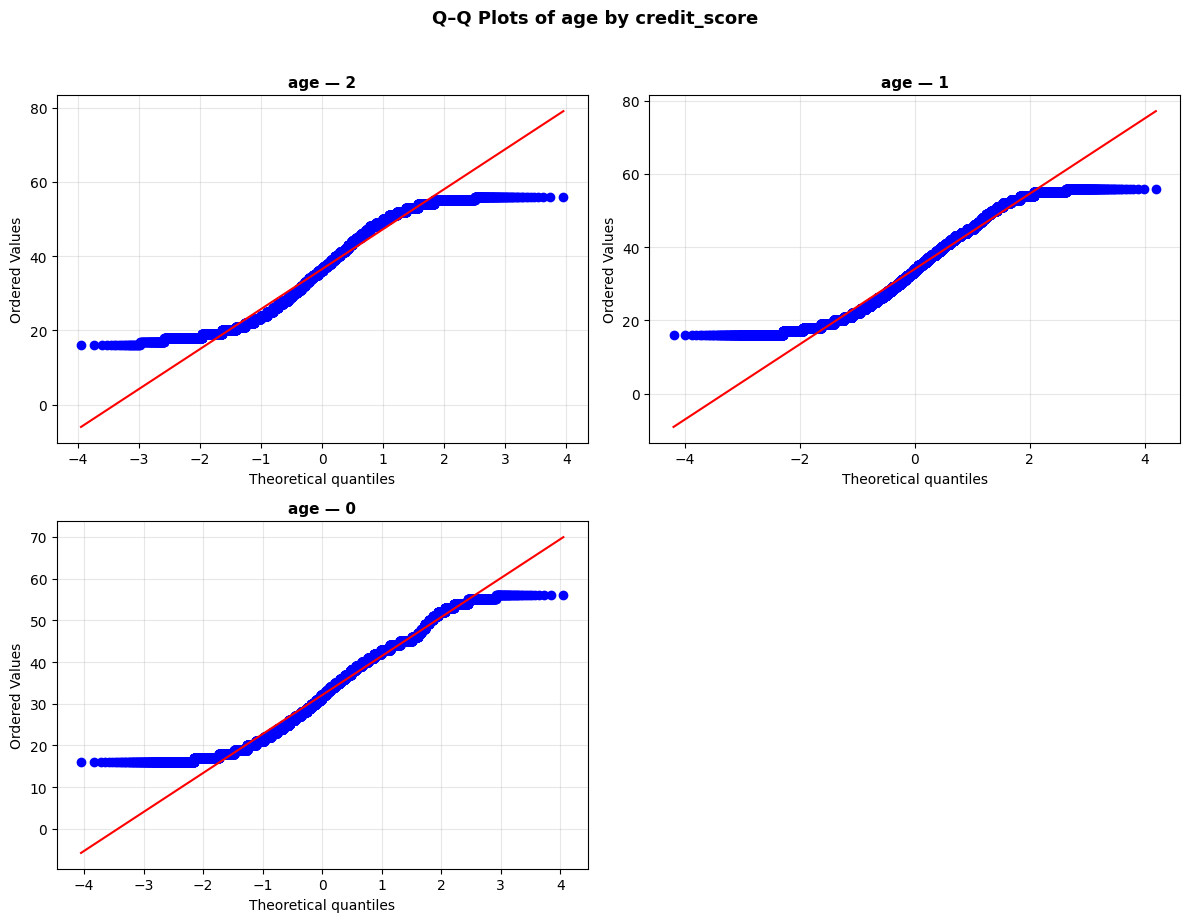

,Feature,Group,Skewness,Kurtosis,Remark
0,age,0,0.2060,-0.8098,"Approximately symmetric, Normal tails"
1,age,1,0.1865,-0.9505,"Approximately symmetric, Normal tails"
2,age,2,0.0158,-1.1731,"Approximately symmetric, Normal tails"



✅ All groups approximately follow normal distribution.


,Metric,Value
0,Levene’s Statistic,416.7097
1,p-value,0.000000
2,Max/Min Variance Ratio,1.35



🔍 Interpretation:
   ⚠️ Statistically significant difference, but practically small — ANOVA or T-Test still acceptable.
   Recommendation → Use Welch’s ANOVA or Welch’s T-Test.

🔍 Welch’s ANOVA Test: age ~ credit_score
Testing mean differences under heteroscedasticity assumption...

Welch’s ANOVA Result:
F-statistic = 1015.0055,  p-value = 0.000000

✅ Significant difference found (p < 0.05)
➡️ Performing Games–Howell post-hoc test:



,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,0,1,32.0918,34.0368,-1.9450,0.0733,-26.5509,60984.5066,0.0000,-0.1926
1,0,2,32.0918,36.5406,-4.4488,0.1004,-44.2927,33676.9266,0.0000,-0.4409
2,1,2,34.0368,36.5406,-2.5038,0.0946,-26.4773,29370.5853,0.0000,-0.2368


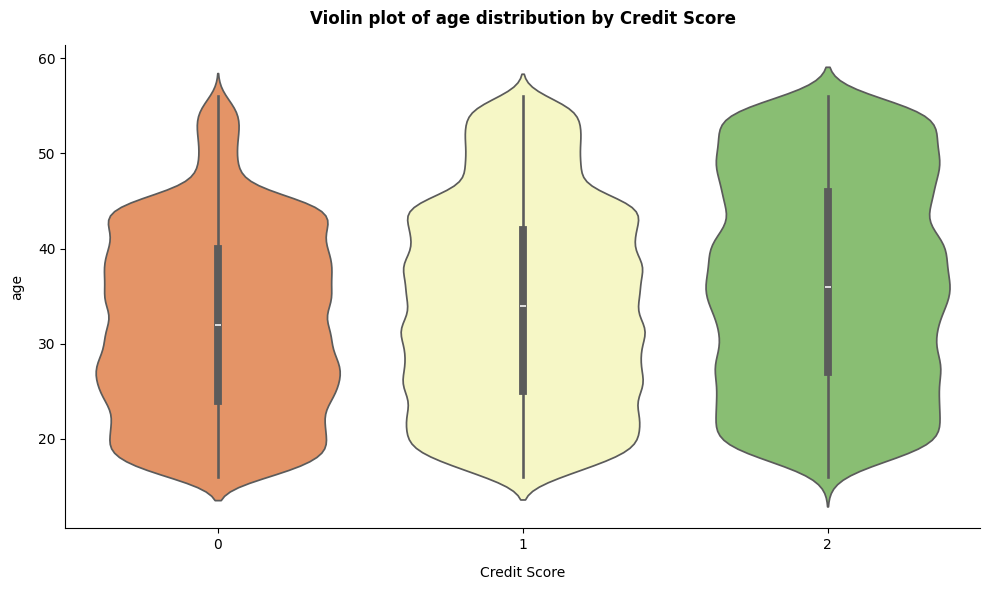

,credit_score,Count,Mean,Median,Std
0,2,17708,65281.602107,44941.950000,44507.939177
1,1,51503,51256.110736,36898.490000,37751.886550
2,0,27485,40962.004735,32151.760000,32365.928930



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: annual_income


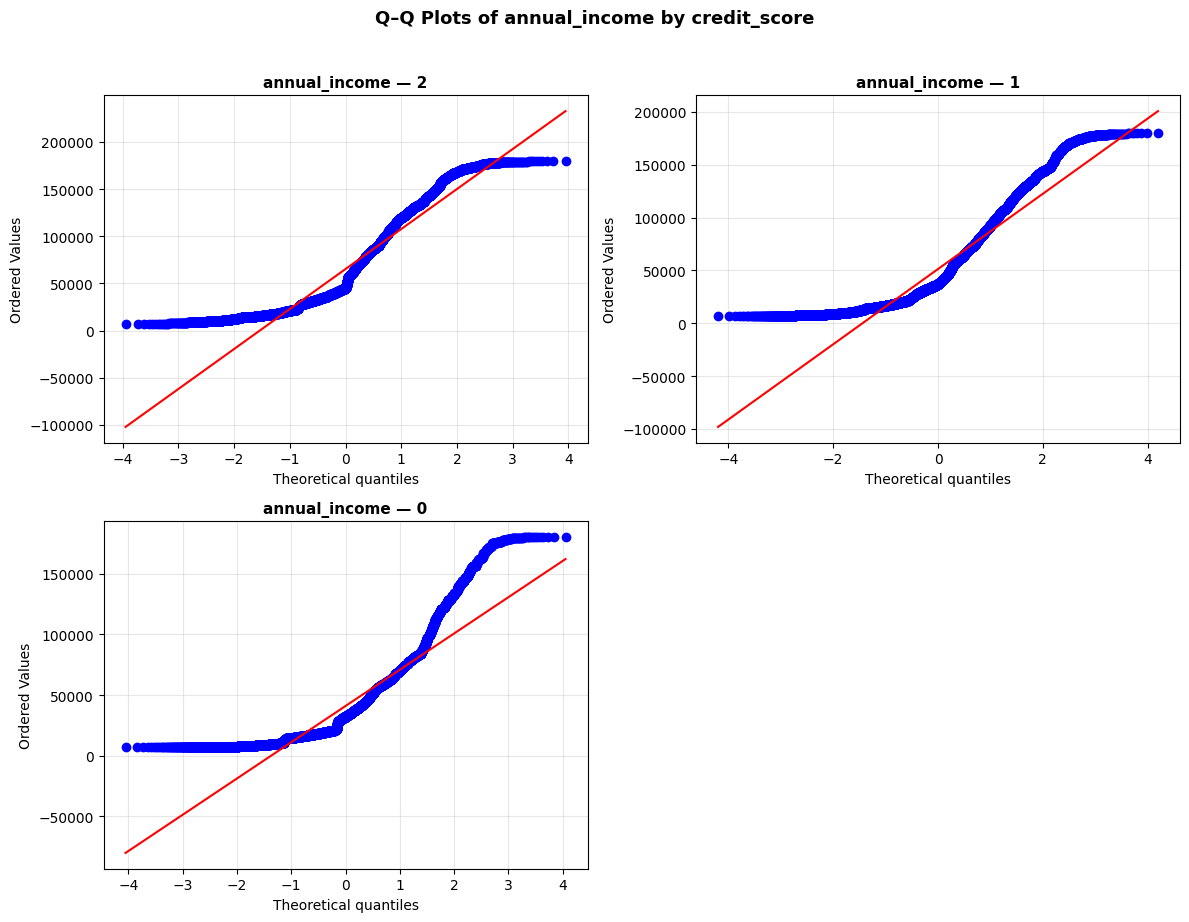

,Feature,Group,Skewness,Kurtosis,Remark
0,annual_income,0,1.5033,2.4247,"Highly skewed, Heavy/light tails"
1,annual_income,1,1.0390,0.3467,"Highly skewed, Normal tails"
2,annual_income,2,0.7368,-0.5556,"Moderately skewed, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: annual_income ~ credit_score
Kruskal-Wallis H-statistic: 4128.286
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


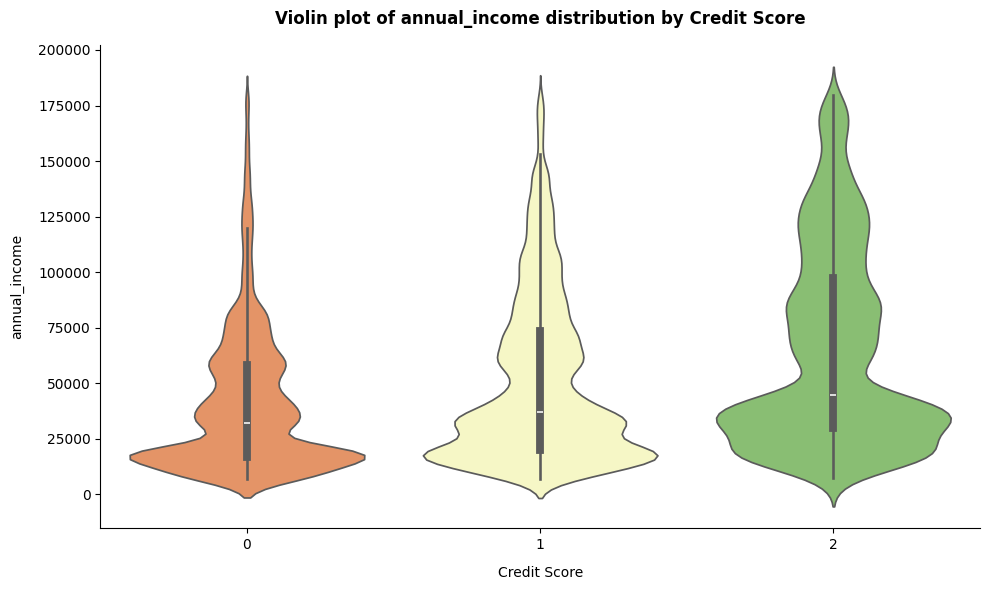

,credit_score,Count,Mean,Median,Std
0,2,17708,5409.838193,3836.909150,3699.897337
1,1,51503,4263.189897,3113.508300,3144.070927
2,0,27485,3412.596029,2690.065000,2700.546957



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: monthly_inhand_salary


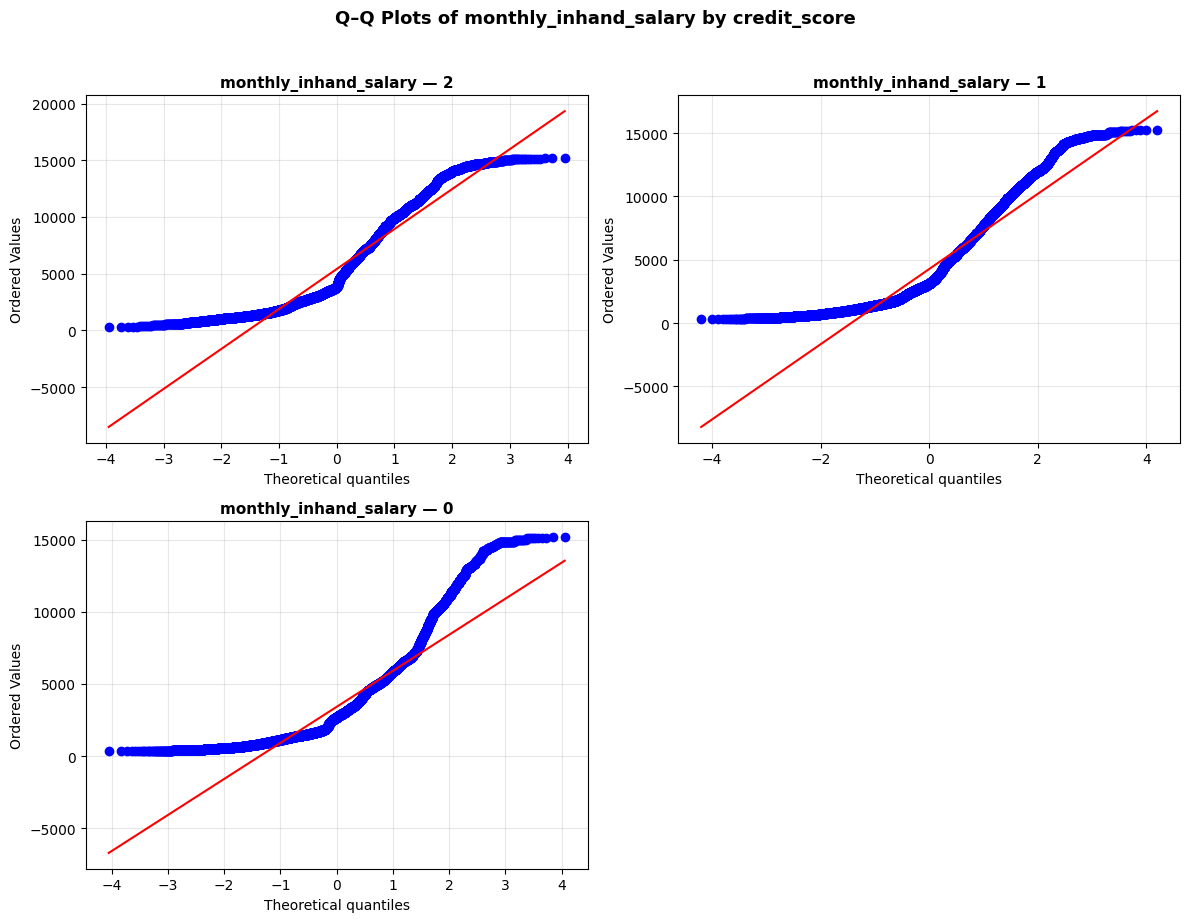

,Feature,Group,Skewness,Kurtosis,Remark
0,monthly_inhand_salary,0,1.4981,2.4142,"Highly skewed, Heavy/light tails"
1,monthly_inhand_salary,1,1.0362,0.3506,"Highly skewed, Normal tails"
2,monthly_inhand_salary,2,0.7430,-0.5302,"Moderately skewed, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: monthly_inhand_salary ~ credit_score
Kruskal-Wallis H-statistic: 3986.425
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0              1              2
0  1.0   0.000000e+00   0.000000e+00
1  0.0   1.000000e+00  4.392915e-297
2  0.0  4.392915e-297   1.000000e+00


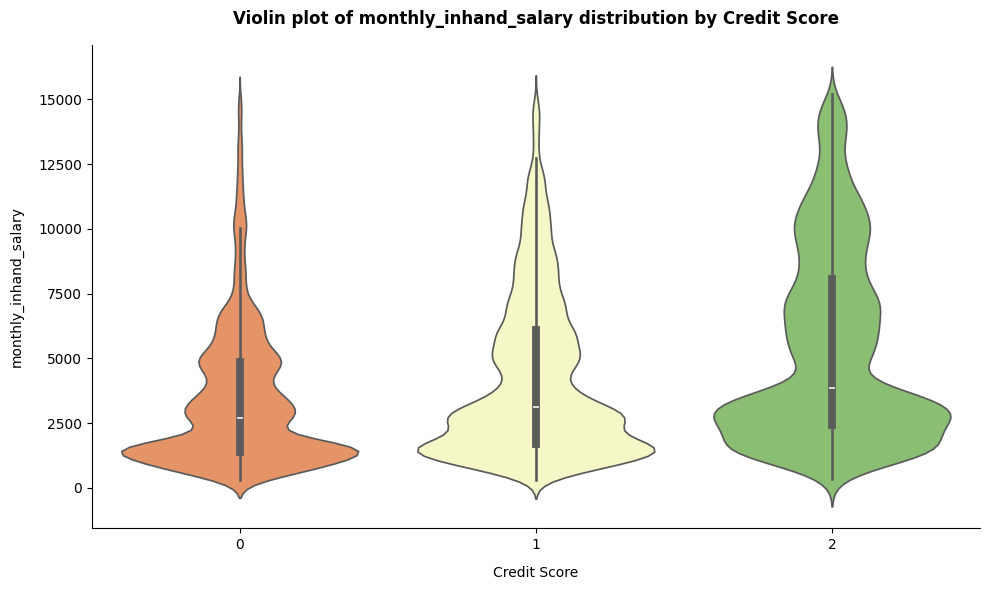

,credit_score,Count,Mean,Median,Std
0,2,17708,99.144003,100.000000,24.334319
1,1,51503,80.578471,80.000000,33.148828
2,0,27485,61.204584,58.000000,29.613966



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: credit_history_age


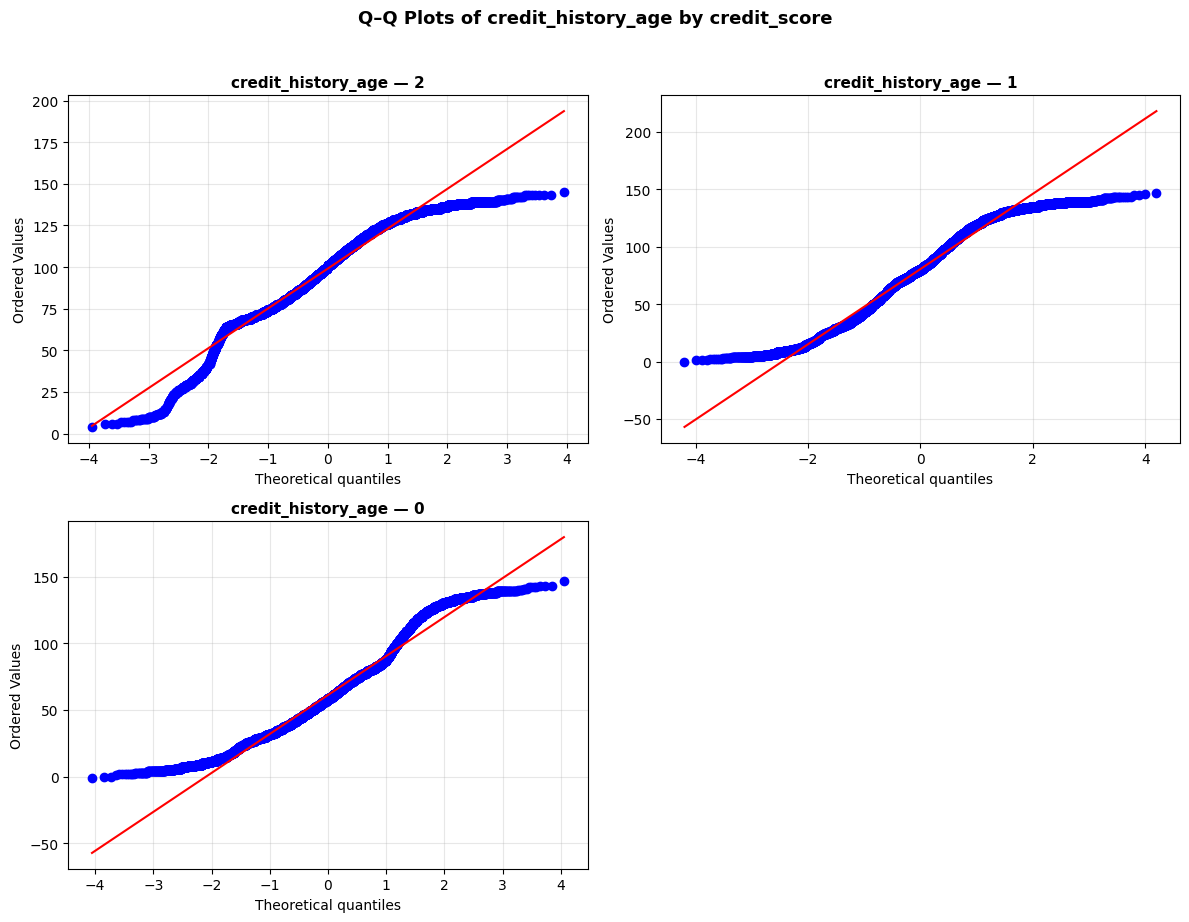

,Feature,Group,Skewness,Kurtosis,Remark
0,credit_history_age,0,0.5381,-0.1612,"Moderately skewed, Normal tails"
1,credit_history_age,1,-0.1711,-0.8345,"Approximately symmetric, Normal tails"
2,credit_history_age,2,-0.4930,0.0805,"Approximately symmetric, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: credit_history_age ~ credit_score
Kruskal-Wallis H-statistic: 15085.388
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


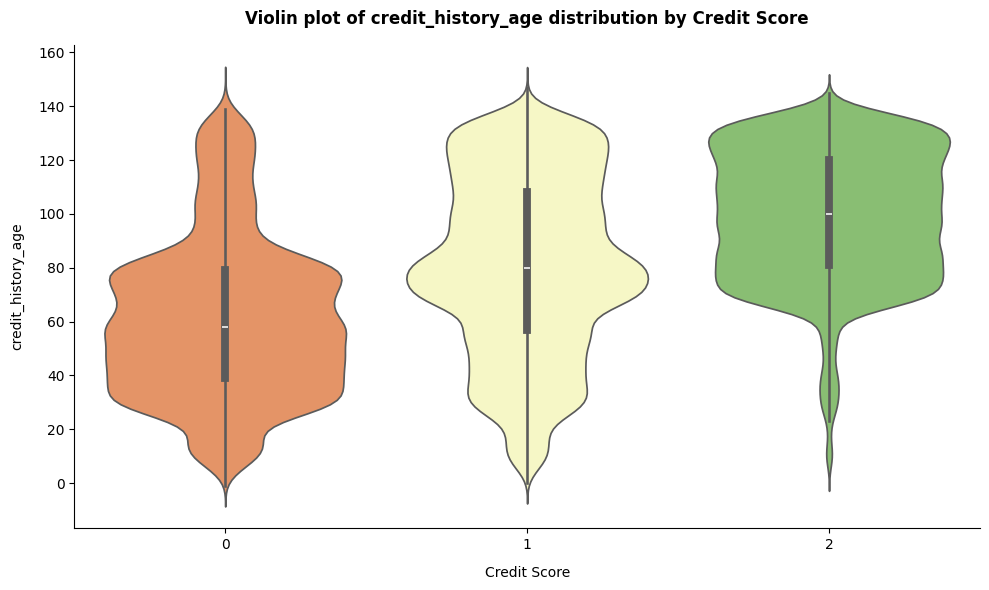

,credit_score,Count,Mean,Median,Std
0,2,17708,120.521505,60.567360,187.759198
1,0,27485,110.324910,74.272415,101.495552
2,1,51503,99.642825,62.242580,119.109448



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: total_emi_per_month


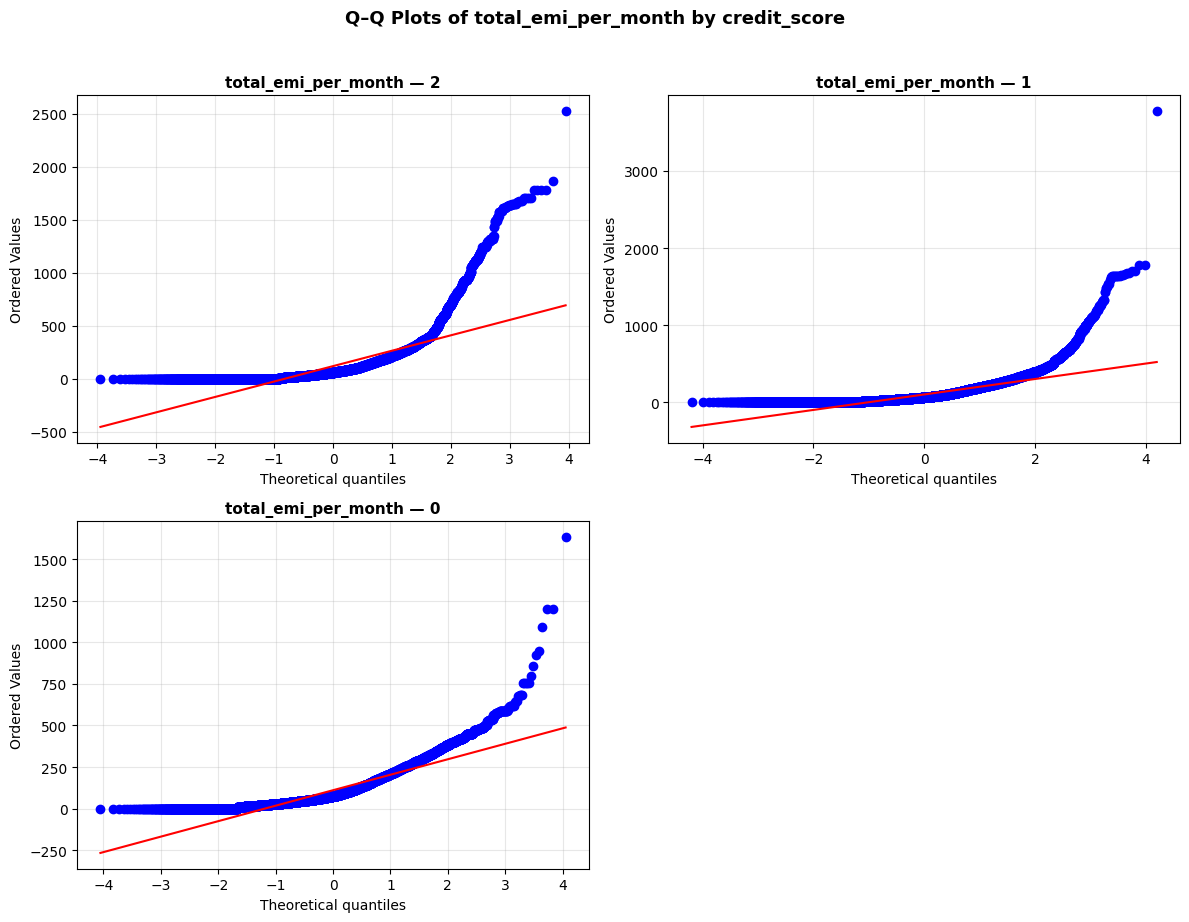

,Feature,Group,Skewness,Kurtosis,Remark
0,total_emi_per_month,0,1.7710,5.9366,"Highly skewed, Heavy/light tails"
1,total_emi_per_month,1,4.0695,43.1381,"Highly skewed, Heavy/light tails"
2,total_emi_per_month,2,3.9985,22.1505,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: total_emi_per_month ~ credit_score
Kruskal-Wallis H-statistic: 837.775
p-value: 1.2007877909730337e-182
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
               0              1              2
0   1.000000e+00  1.661442e-158  2.580830e-115
1  1.661442e-158   1.000000e+00   7.068653e-02
2  2.580830e-115   7.068653e-02   1.000000e+00


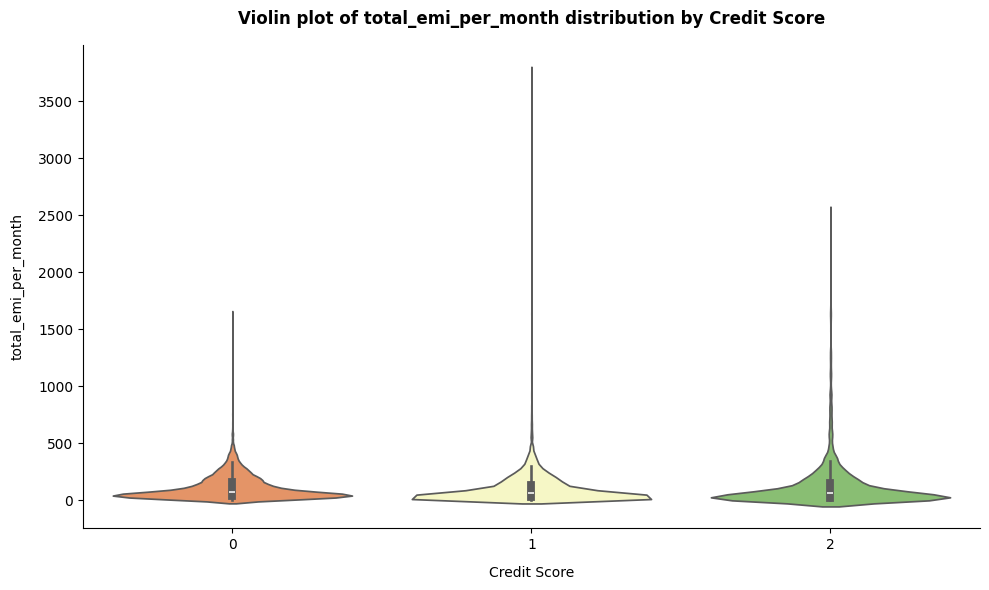

,credit_score,Count,Mean,Median,Std
0,0,27485,6.481463,7.000000,2.535541
1,1,51503,5.350989,5.000000,2.366953
2,2,17708,3.422408,3.000000,2.210072



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: num_bank_accounts


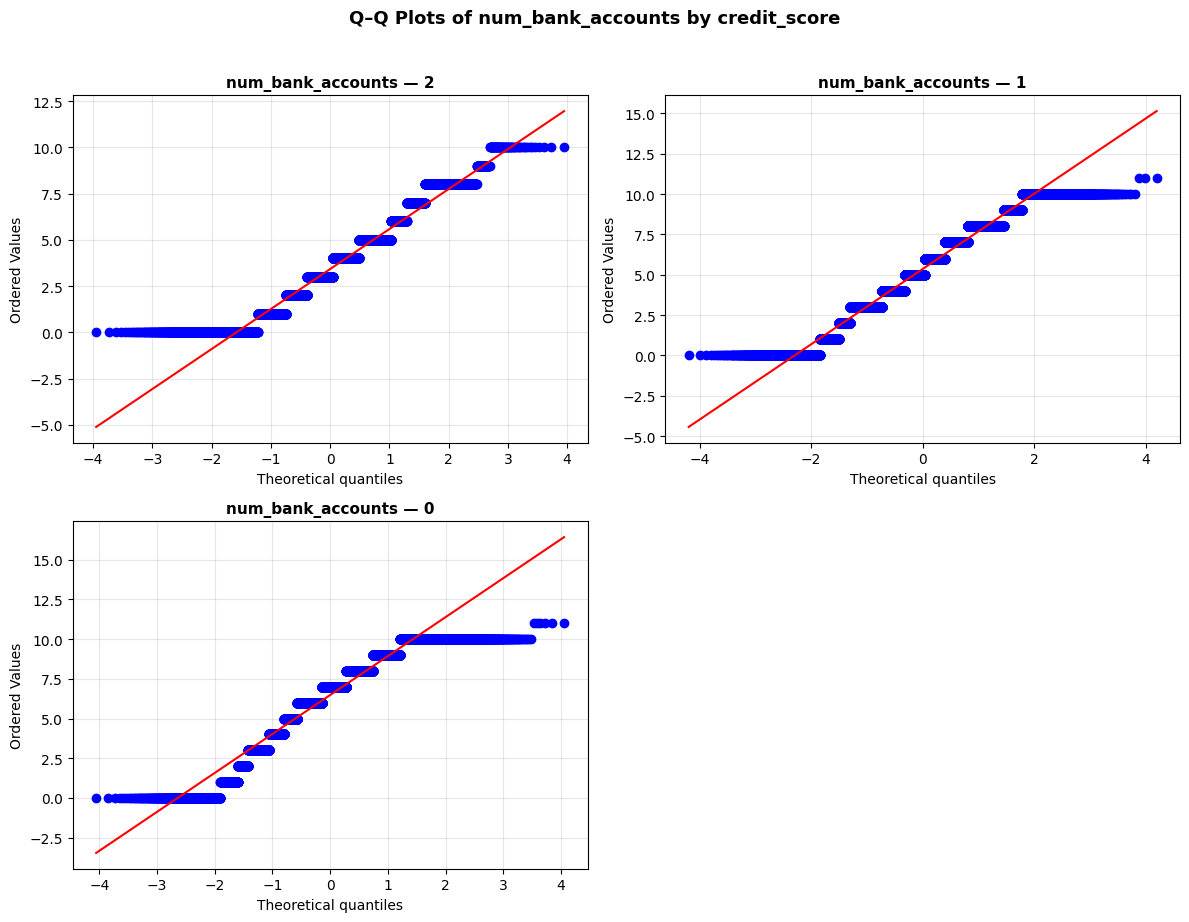

,Feature,Group,Skewness,Kurtosis,Remark
0,num_bank_accounts,0,-0.6730,-0.1184,"Moderately skewed, Normal tails"
1,num_bank_accounts,1,-0.1793,-0.4959,"Approximately symmetric, Normal tails"
2,num_bank_accounts,2,0.3028,-0.4466,"Approximately symmetric, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: num_bank_accounts ~ credit_score
Kruskal-Wallis H-statistic: 15026.861
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


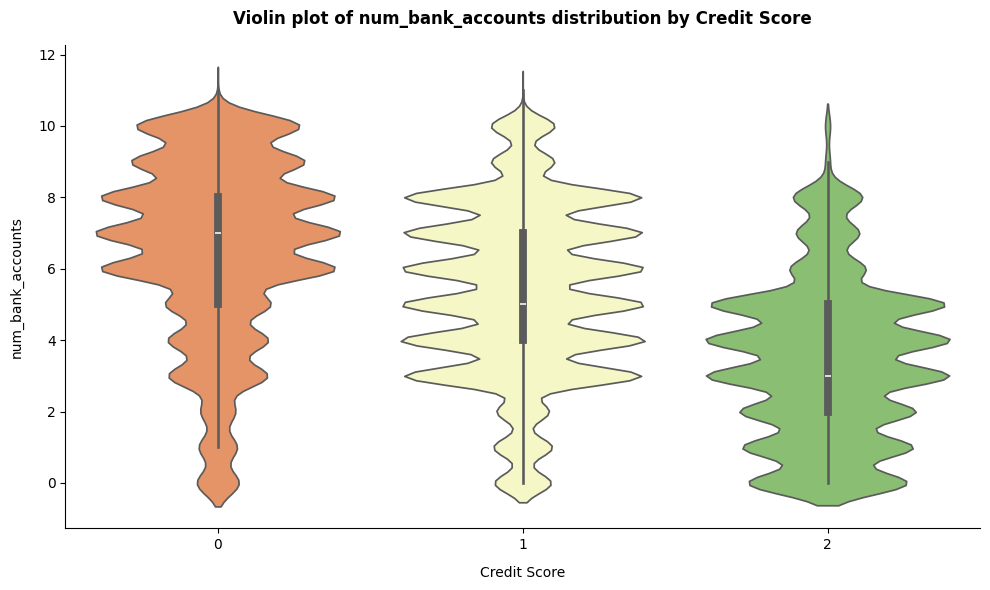

,credit_score,Count,Mean,Median,Std
0,0,27485,6.587375,6.000000,1.985442
1,1,51503,5.387783,5.000000,1.852368
2,2,17708,4.128868,4.000000,1.804813



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: num_credit_card


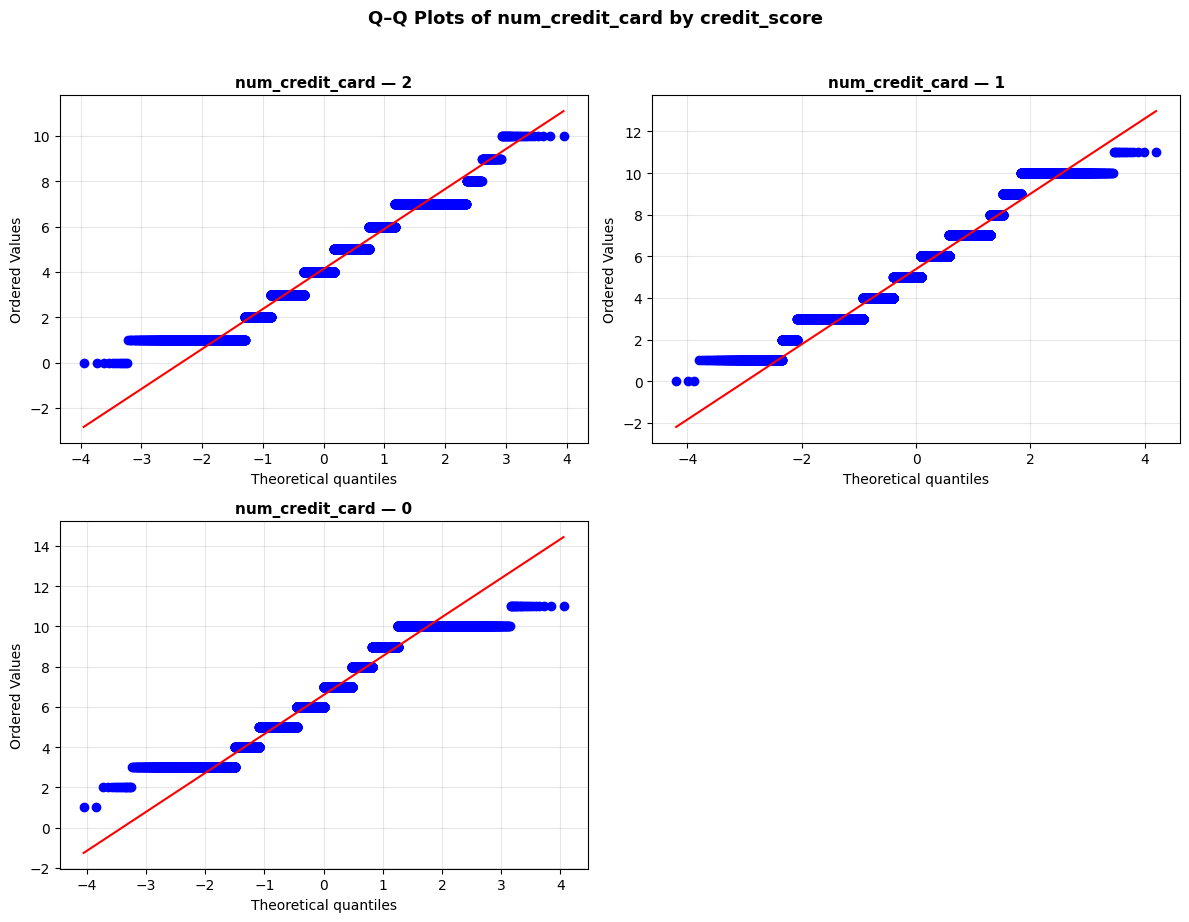

,Feature,Group,Skewness,Kurtosis,Remark
0,num_credit_card,0,0.0949,-0.8105,"Approximately symmetric, Normal tails"
1,num_credit_card,1,0.3659,-0.1353,"Approximately symmetric, Normal tails"
2,num_credit_card,2,0.0399,-0.6155,"Approximately symmetric, Normal tails"



✅ All groups approximately follow normal distribution.


,Metric,Value
0,Levene’s Statistic,207.2732
1,p-value,0.000000
2,Max/Min Variance Ratio,1.21



🔍 Interpretation:
   ⚠️ Statistically significant difference, but practically small — ANOVA or T-Test still acceptable.
   Recommendation → Use Welch’s ANOVA or Welch’s T-Test.

🔍 Welch’s ANOVA Test: num_credit_card ~ credit_score
Testing mean differences under heteroscedasticity assumption...

Welch’s ANOVA Result:
F-statistic = 9371.6415,  p-value = 0.000000

✅ Significant difference found (p < 0.05)
➡️ Performing Games–Howell post-hoc test:



,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,0,1,6.5874,5.3878,1.1996,0.0145,82.7707,52861.1650,0.0000,0.6314
1,0,2,6.5874,4.1289,2.4585,0.0181,135.8787,40299.6417,0.0000,1.2827
2,1,2,5.3878,4.1289,1.2589,0.0158,79.5300,31438.1941,0.0000,0.6841


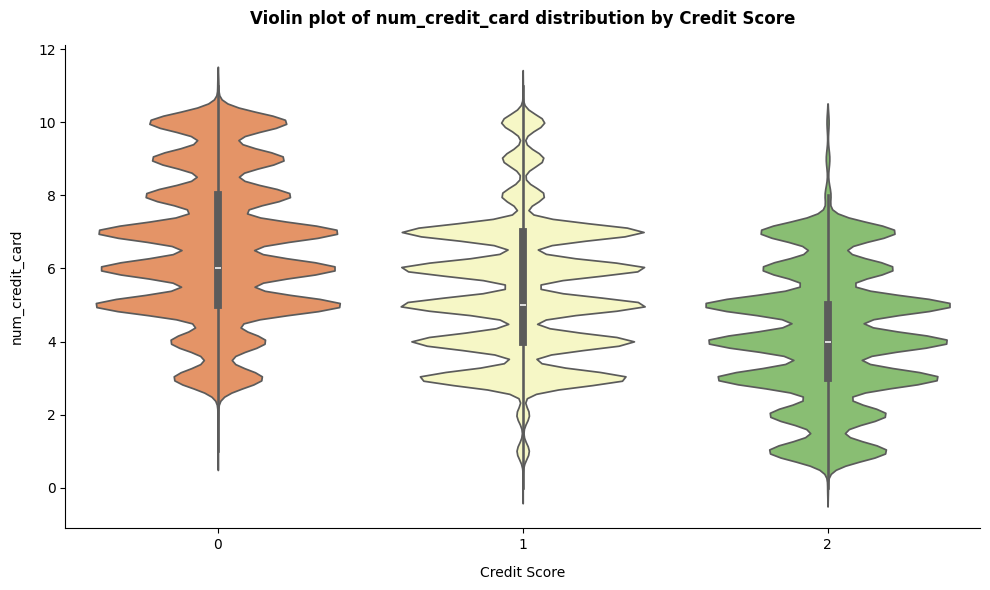

,credit_score,Count,Mean,Median,Std
0,0,27485,20.014299,21.000000,8.942302
1,1,51503,13.641982,12.000000,7.646880
2,2,17708,7.604698,7.000000,4.814999



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: interest_rate


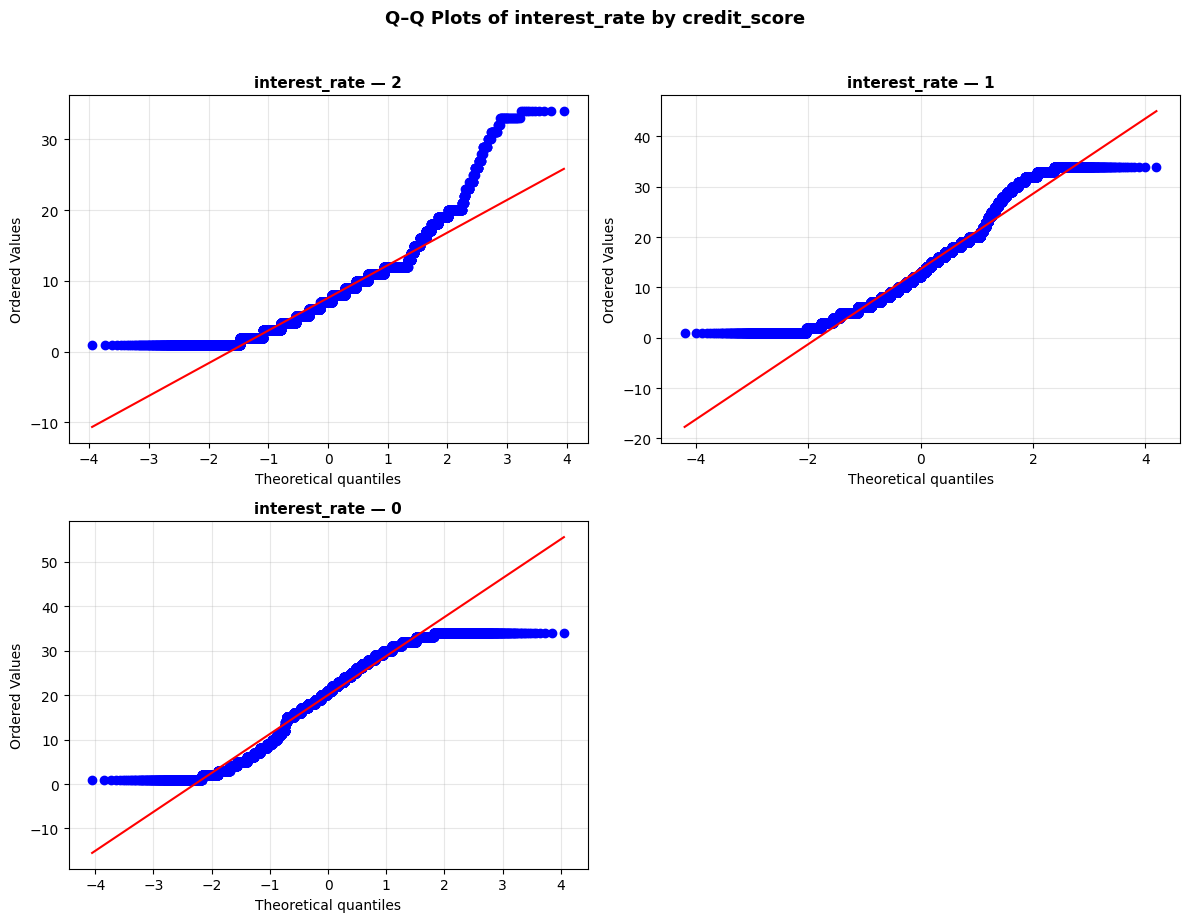

,Feature,Group,Skewness,Kurtosis,Remark
0,interest_rate,0,-0.3489,-0.8233,"Approximately symmetric, Normal tails"
1,interest_rate,1,0.6707,-0.0310,"Moderately skewed, Normal tails"
2,interest_rate,2,1.2055,2.9665,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: interest_rate ~ credit_score
Kruskal-Wallis H-statistic: 22278.197
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


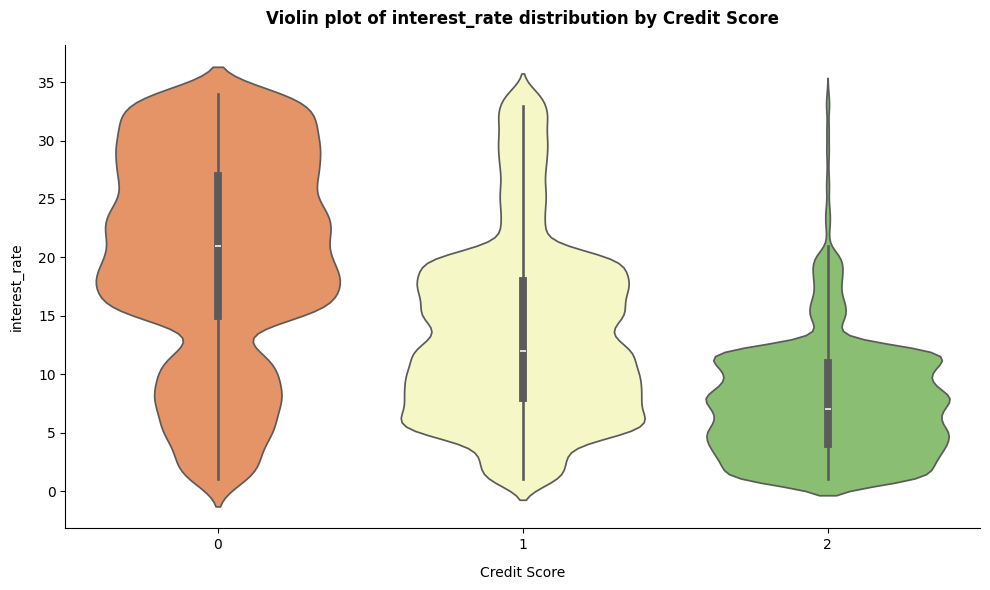

,credit_score,Count,Mean,Median,Std
0,0,27485,4.724795,5.000000,2.443395
1,1,51503,3.263946,3.000000,2.361910
2,2,17708,2.183646,2.000000,1.633134



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: num_of_loan


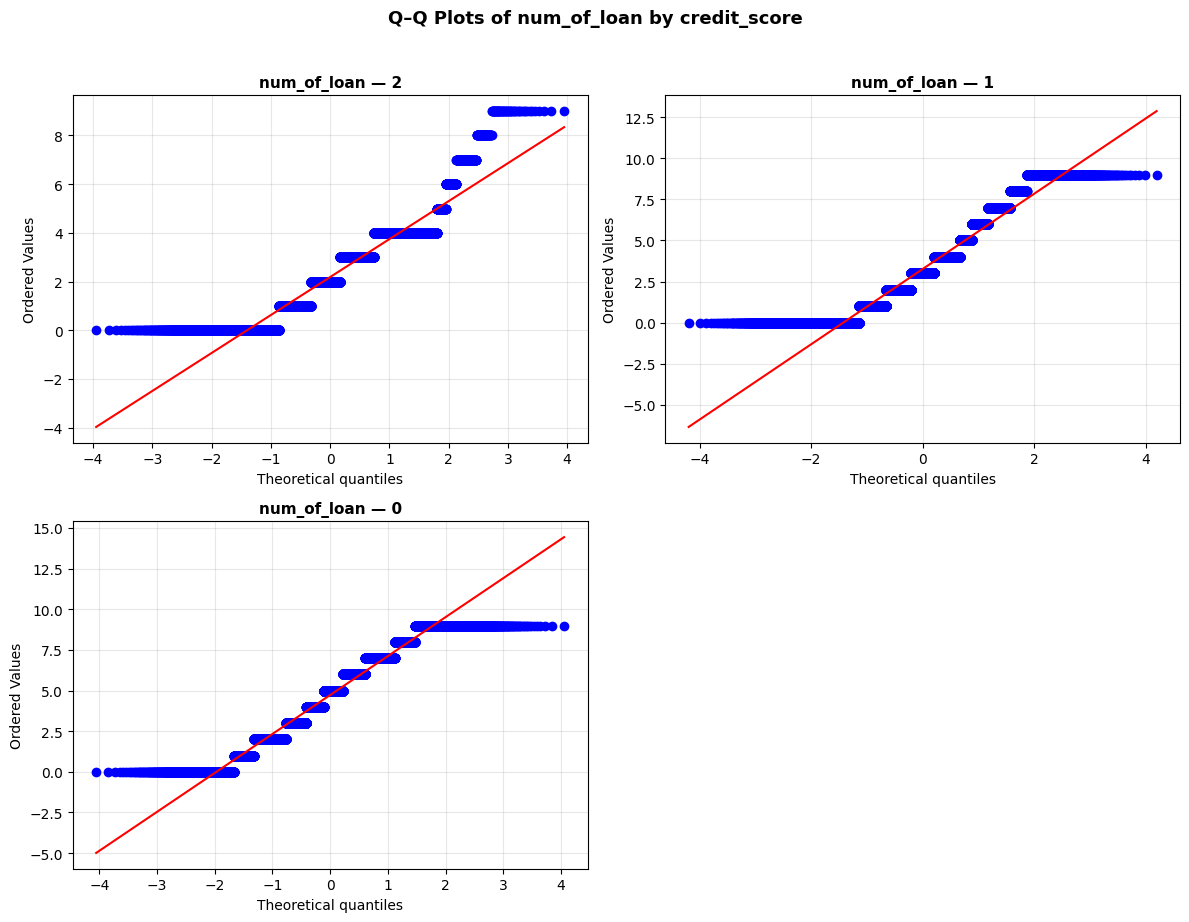

,Feature,Group,Skewness,Kurtosis,Remark
0,num_of_loan,0,-0.0737,-0.8851,"Approximately symmetric, Normal tails"
1,num_of_loan,1,0.5702,-0.3638,"Moderately skewed, Normal tails"
2,num_of_loan,2,0.5695,0.6126,"Moderately skewed, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: num_of_loan ~ credit_score
Kruskal-Wallis H-statistic: 12120.795
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


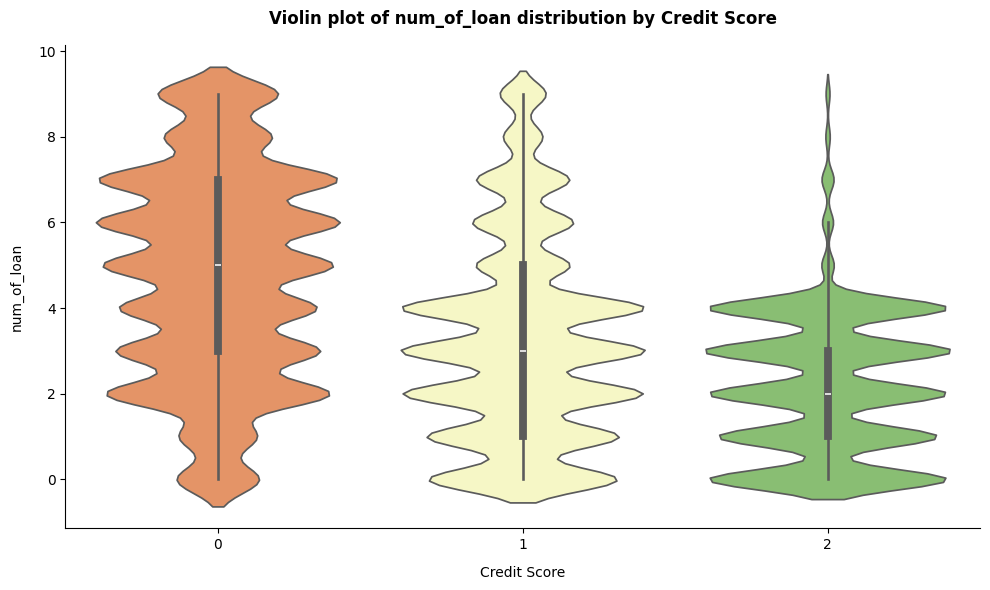

,credit_score,Count,Mean,Median,Std
0,0,27485,29.549645,26.000000,16.351822
1,1,51503,19.578471,17.000000,12.925378
2,2,17708,10.810086,10.000000,8.354868



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: delay_from_due_date


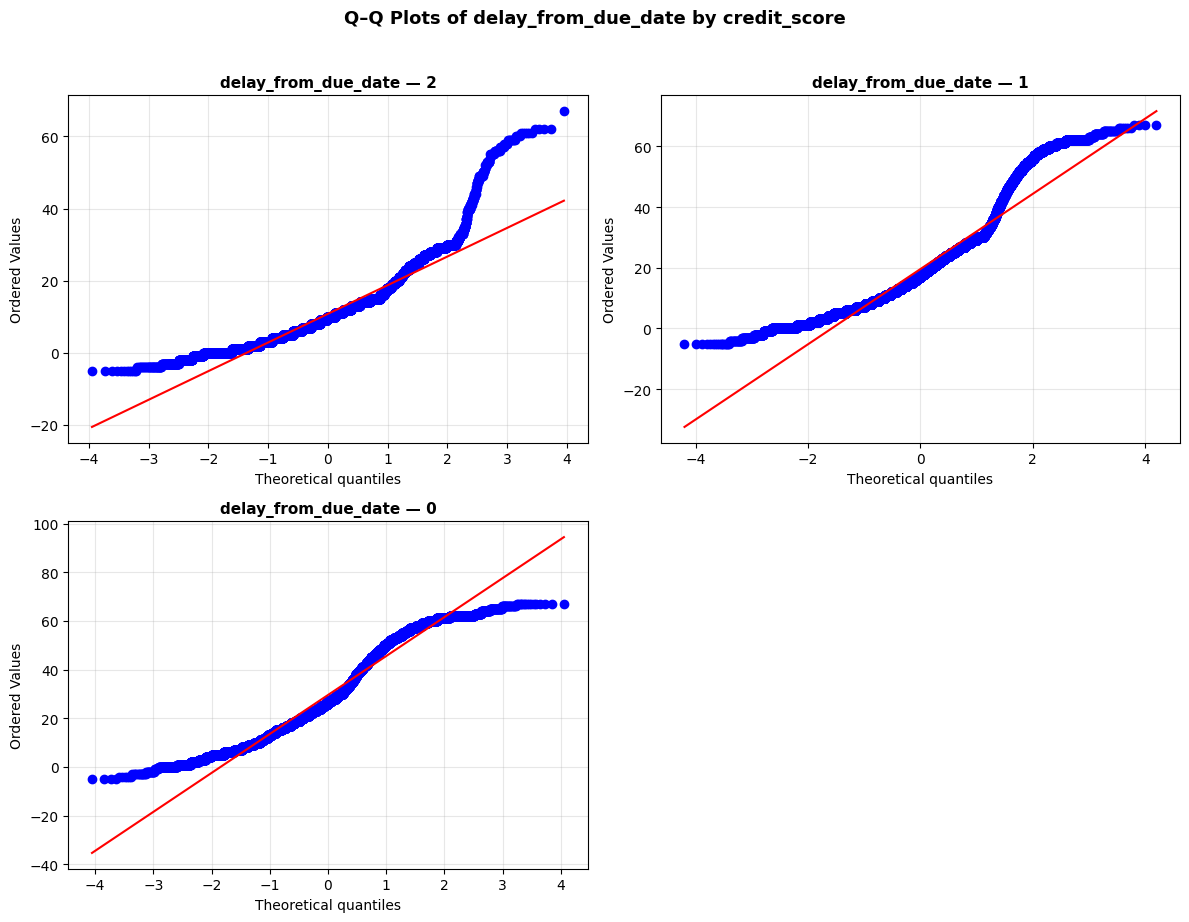

,Feature,Group,Skewness,Kurtosis,Remark
0,delay_from_due_date,0,0.3786,-0.8897,"Approximately symmetric, Normal tails"
1,delay_from_due_date,1,1.1184,1.2858,"Highly skewed, Normal tails"
2,delay_from_due_date,2,1.5204,4.5114,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: delay_from_due_date ~ credit_score
Kruskal-Wallis H-statistic: 18749.261
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


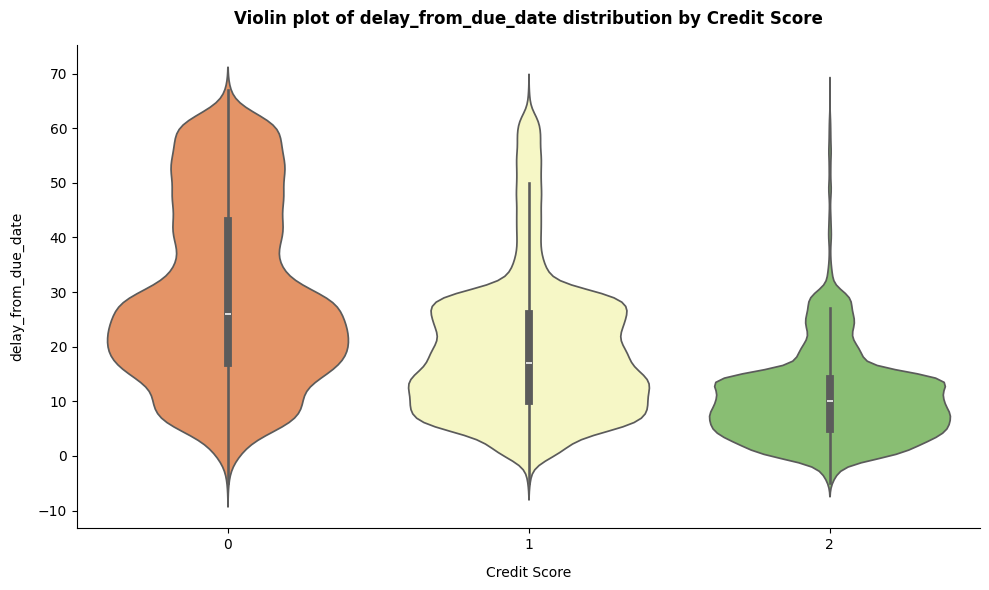

,credit_score,Count,Mean,Median,Std
0,0,27485,15.734910,17.000000,6.176209
1,1,51503,13.483331,14.000000,5.666295
2,2,17708,8.524339,8.000000,5.527091



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: num_of_delayed_payment


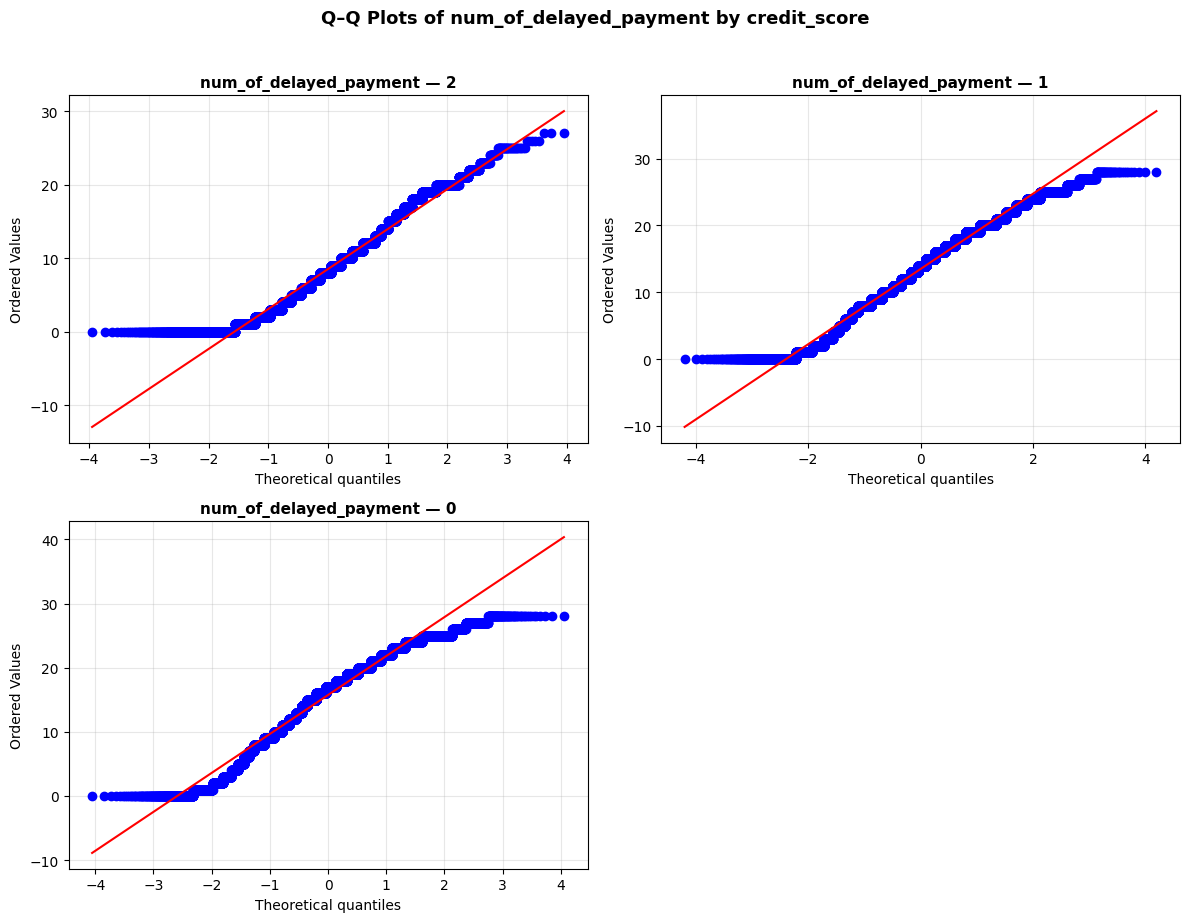

,Feature,Group,Skewness,Kurtosis,Remark
0,num_of_delayed_payment,0,-0.5263,-0.3359,"Moderately skewed, Normal tails"
1,num_of_delayed_payment,1,-0.2334,-0.4201,"Approximately symmetric, Normal tails"
2,num_of_delayed_payment,2,0.4046,-0.4847,"Approximately symmetric, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: num_of_delayed_payment ~ credit_score
Kruskal-Wallis H-statistic: 14101.023
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


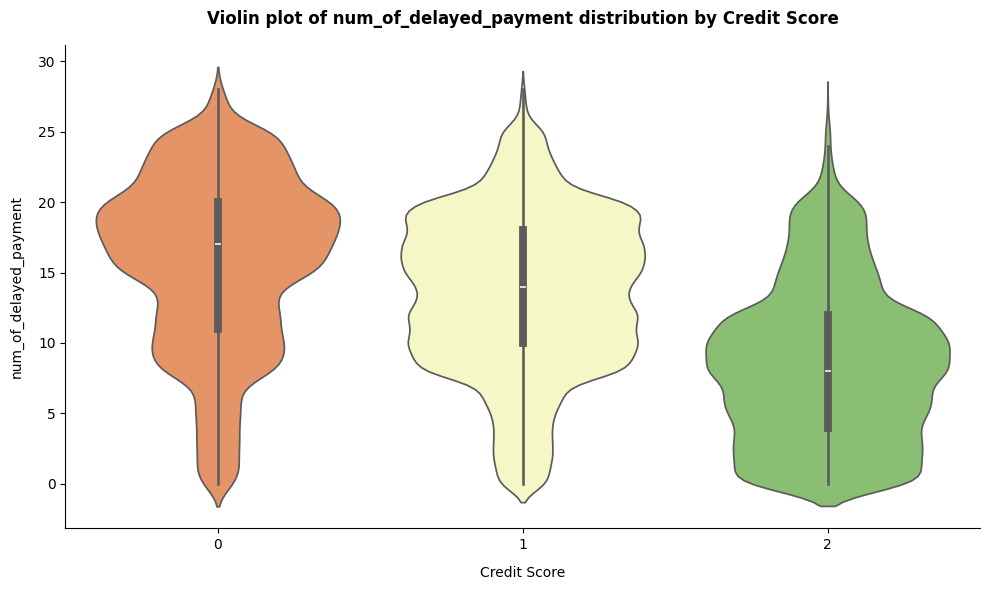

,credit_score,Count,Mean,Median,Std
0,1,51503,11.040396,10.170000,6.798864
1,0,27485,10.995800,9.690000,7.163352
2,2,17708,7.036712,6.650000,4.857804



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: changed_credit_limit


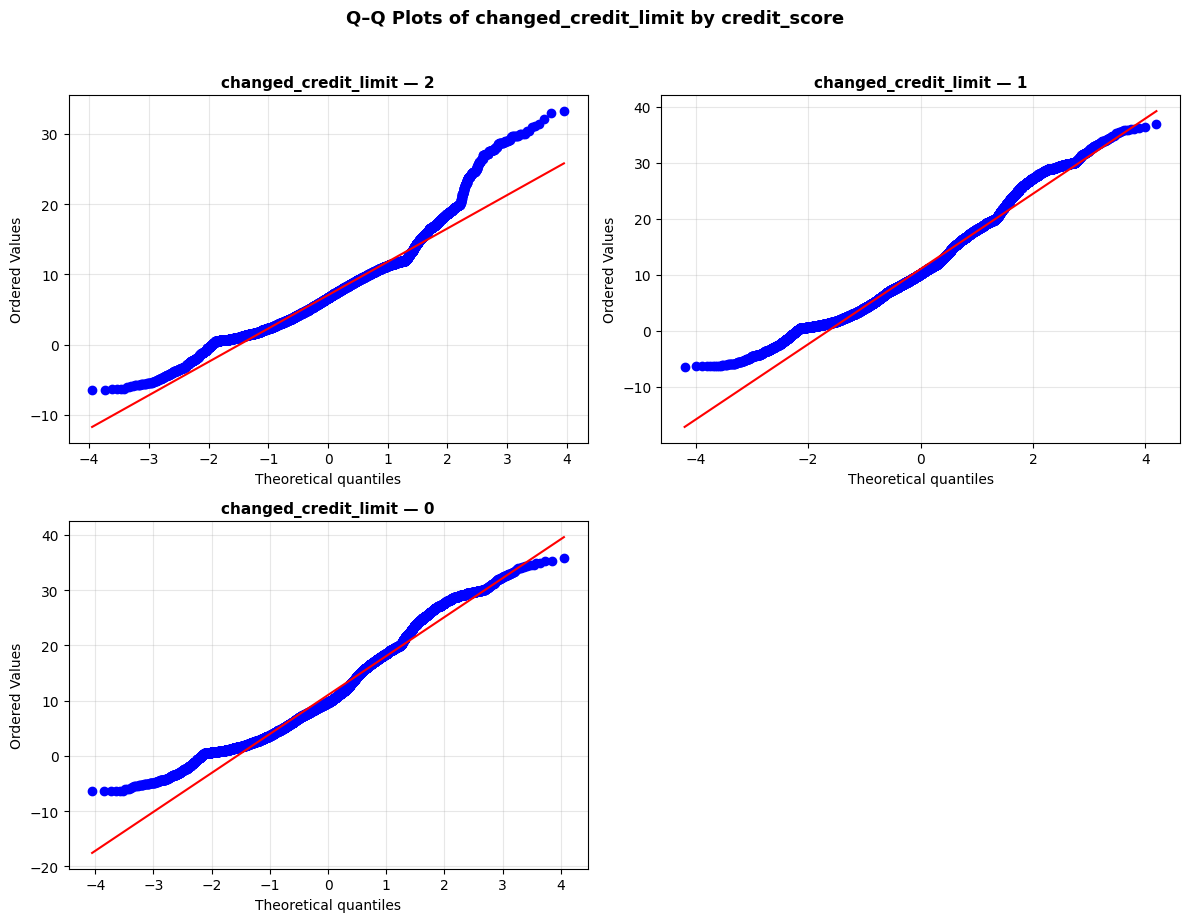

,Feature,Group,Skewness,Kurtosis,Remark
0,changed_credit_limit,0,0.5747,-0.1881,"Moderately skewed, Normal tails"
1,changed_credit_limit,1,0.5340,-0.0078,"Moderately skewed, Normal tails"
2,changed_credit_limit,2,0.9012,2.0618,"Moderately skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: changed_credit_limit ~ credit_score
Kruskal-Wallis H-statistic: 5211.161
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
          0         1    2
0  1.000000  0.000018  0.0
1  0.000018  1.000000  0.0
2  0.000000  0.000000  1.0


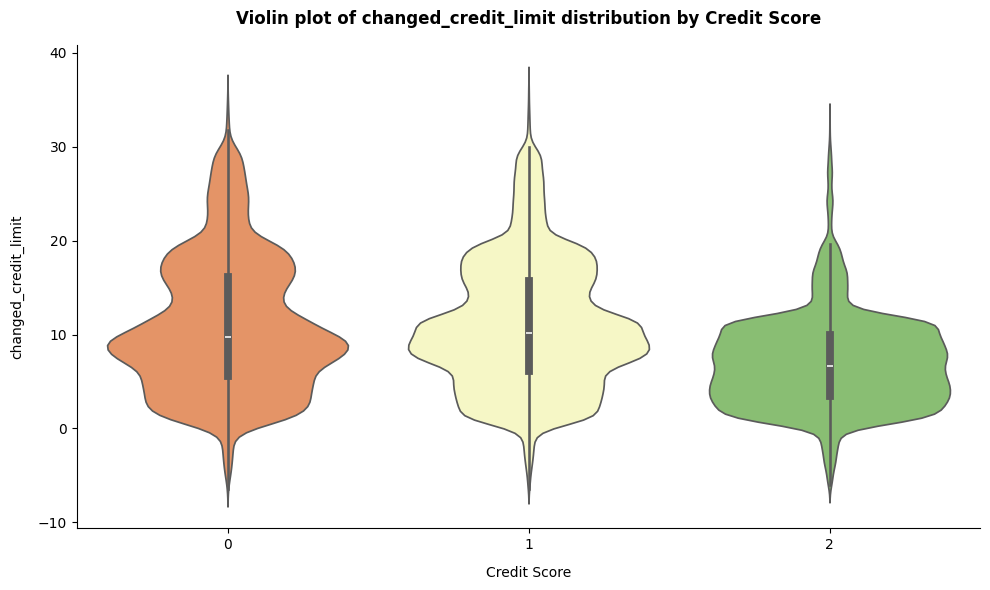

,credit_score,Count,Mean,Median,Std
0,0,27485,8.065454,8.000000,3.742198
1,1,51503,5.222531,5.000000,3.578748
2,2,17708,3.240795,3.000000,2.535112



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: num_credit_inquiries


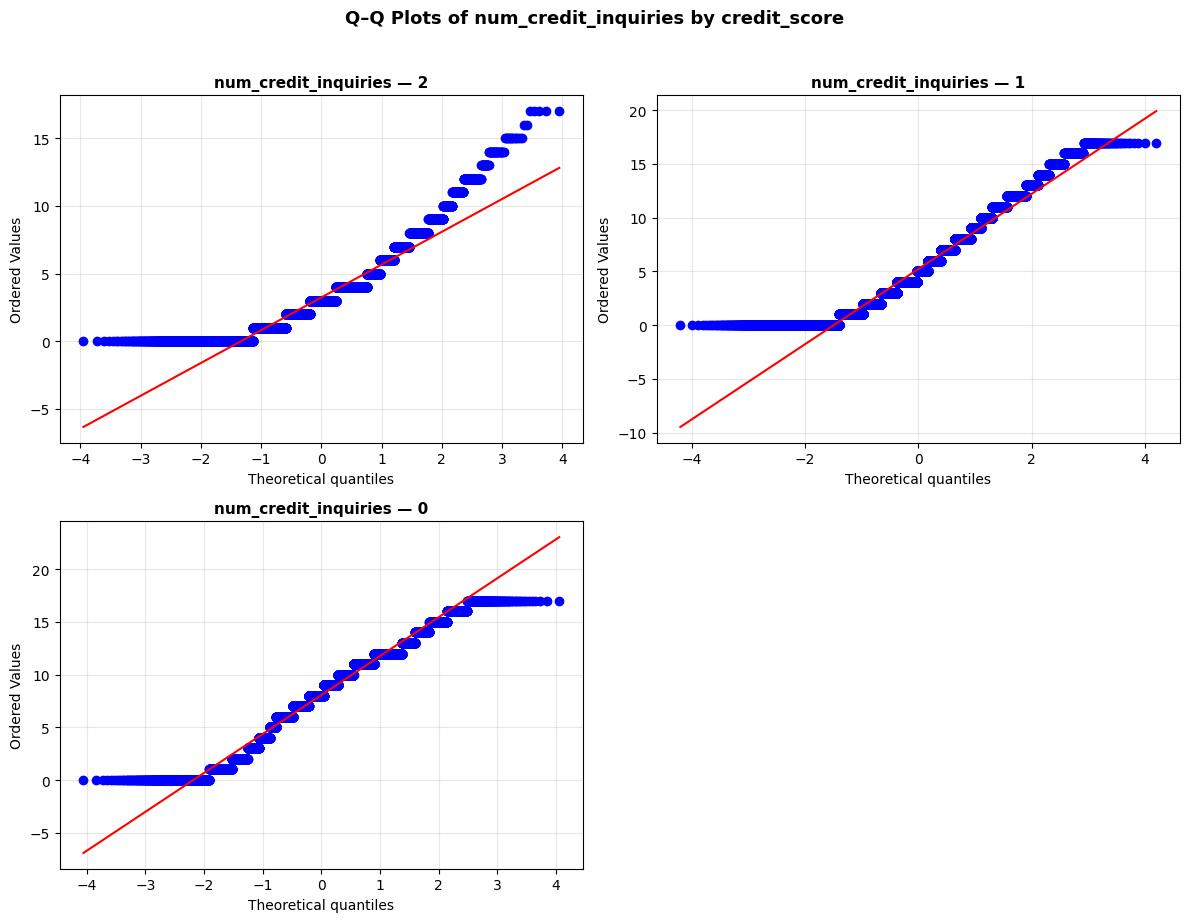

,Feature,Group,Skewness,Kurtosis,Remark
0,num_credit_inquiries,0,-0.2634,-0.4415,"Approximately symmetric, Normal tails"
1,num_credit_inquiries,1,0.5493,-0.2576,"Moderately skewed, Normal tails"
2,num_credit_inquiries,2,1.0830,1.6128,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: num_credit_inquiries ~ credit_score
Kruskal-Wallis H-statistic: 18254.856
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


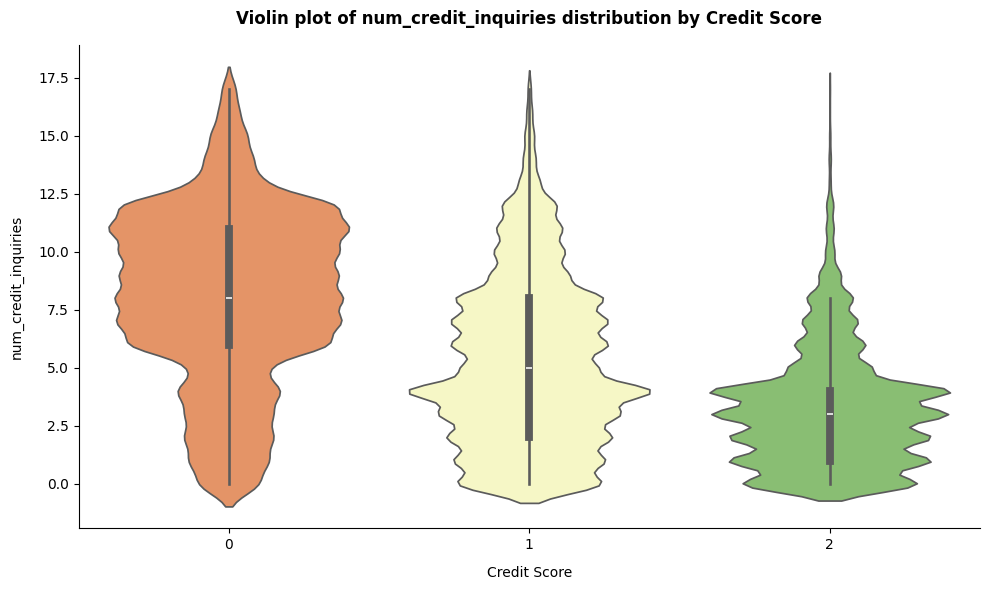

,credit_score,Count,Mean,Median,Std
0,0,27485,2062.464994,1928.030000,1150.371972
1,1,51503,1263.236535,988.950000,1126.446052
2,2,17708,793.921277,733.960000,597.313325



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: outstanding_debt


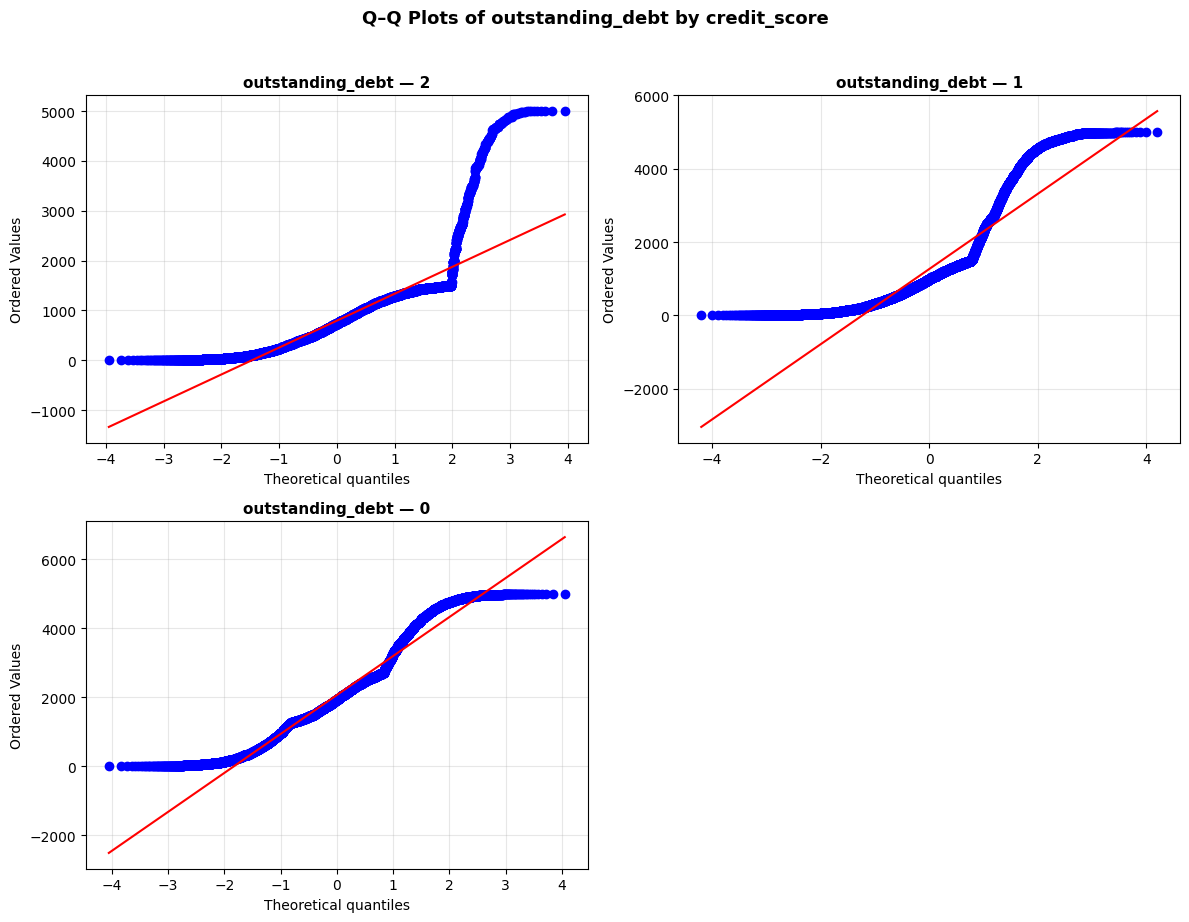

,Feature,Group,Skewness,Kurtosis,Remark
0,outstanding_debt,0,0.5826,-0.0522,"Moderately skewed, Normal tails"
1,outstanding_debt,1,1.5257,1.7788,"Highly skewed, Heavy/light tails"
2,outstanding_debt,2,2.4197,12.0712,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: outstanding_debt ~ credit_score
Kruskal-Wallis H-statistic: 18353.207
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


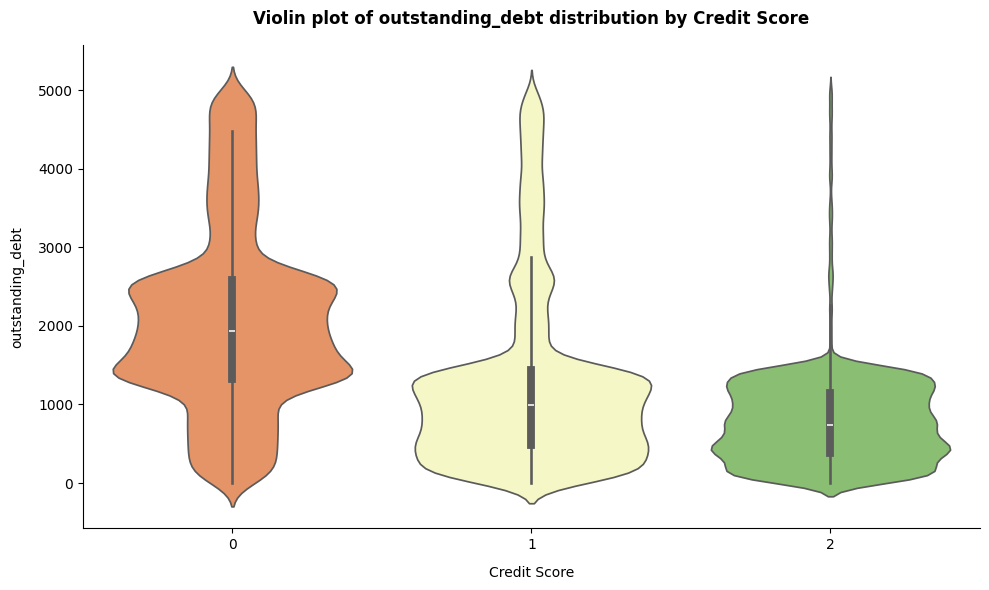

,credit_score,Count,Mean,Median,Std
0,2,17708,32.690570,32.744434,5.209792
1,1,51503,32.327852,32.341713,5.112435
2,0,27485,32.005873,32.042133,5.063034



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: credit_utilization_ratio


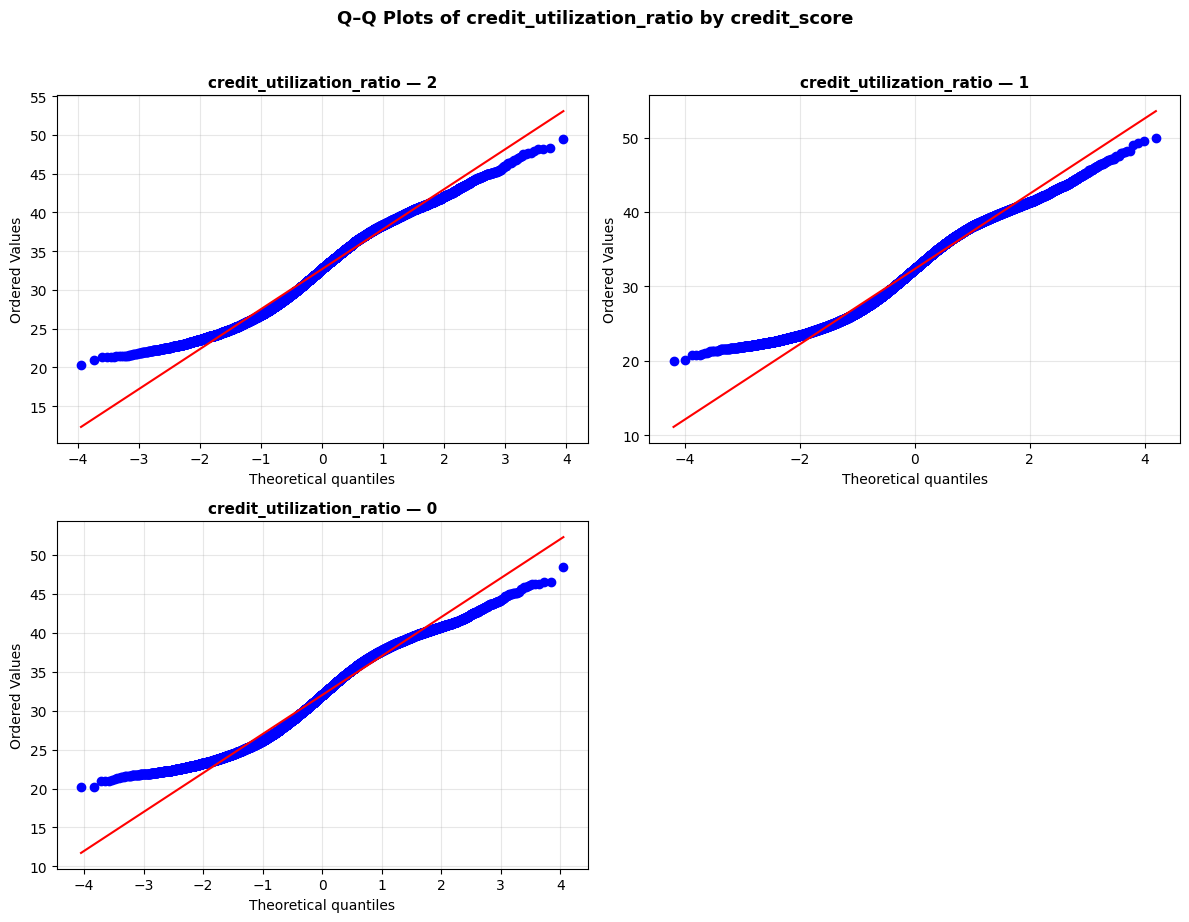

,Feature,Group,Skewness,Kurtosis,Remark
0,credit_utilization_ratio,0,0.0094,-1.0060,"Approximately symmetric, Normal tails"
1,credit_utilization_ratio,1,0.0291,-0.9422,"Approximately symmetric, Normal tails"
2,credit_utilization_ratio,2,0.0348,-0.8940,"Approximately symmetric, Normal tails"



✅ All groups approximately follow normal distribution.


,Metric,Value
0,Levene’s Statistic,7.1383
1,p-value,0.000794
2,Max/Min Variance Ratio,1.06



🔍 Interpretation:
   ⚠️ Statistically significant difference, but practically small — ANOVA or T-Test still acceptable.
   Recommendation → Use Welch’s ANOVA or Welch’s T-Test.

🔍 Welch’s ANOVA Test: credit_utilization_ratio ~ credit_score
Testing mean differences under heteroscedasticity assumption...

Welch’s ANOVA Result:
F-statistic = 97.7576,  p-value = 0.000000

✅ Significant difference found (p < 0.05)
➡️ Performing Games–Howell post-hoc test:



,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,0,1,32.0059,32.3279,-0.3220,0.0379,-8.4844,56589.5386,0.0000,-0.0632
1,0,2,32.0059,32.6906,-0.6847,0.0497,-13.7897,36988.7885,0.0000,-0.1337
2,1,2,32.3279,32.6906,-0.3627,0.0452,-8.0303,30233.9685,0.0000,-0.0706


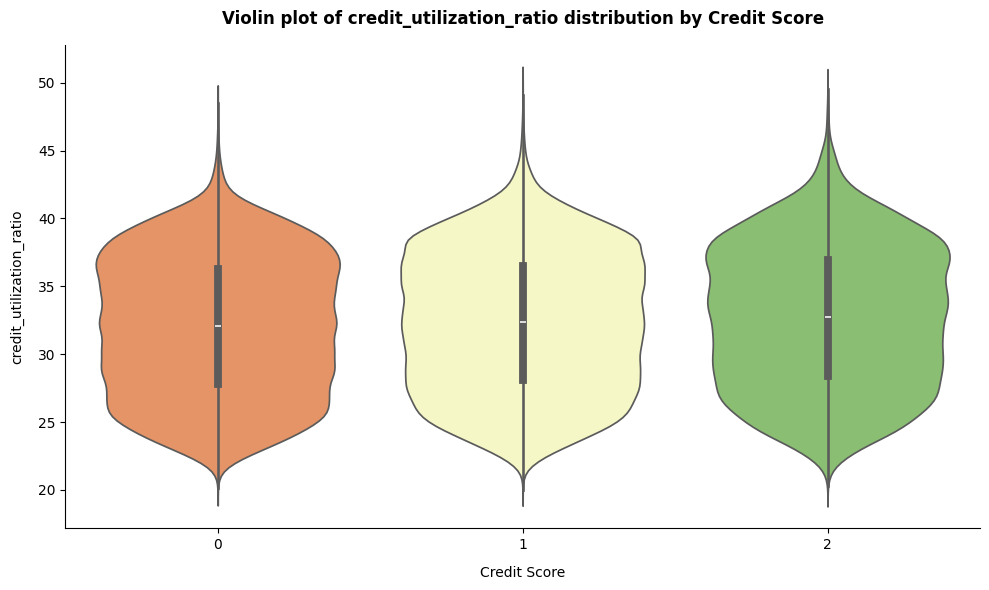

,credit_score,Count,Mean,Median,Std
0,2,17708,696.090275,167.625300,2041.436406
1,1,51503,633.150868,137.664570,2032.300935
2,0,27485,622.147207,119.634480,2084.750139



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: amount_invested_monthly


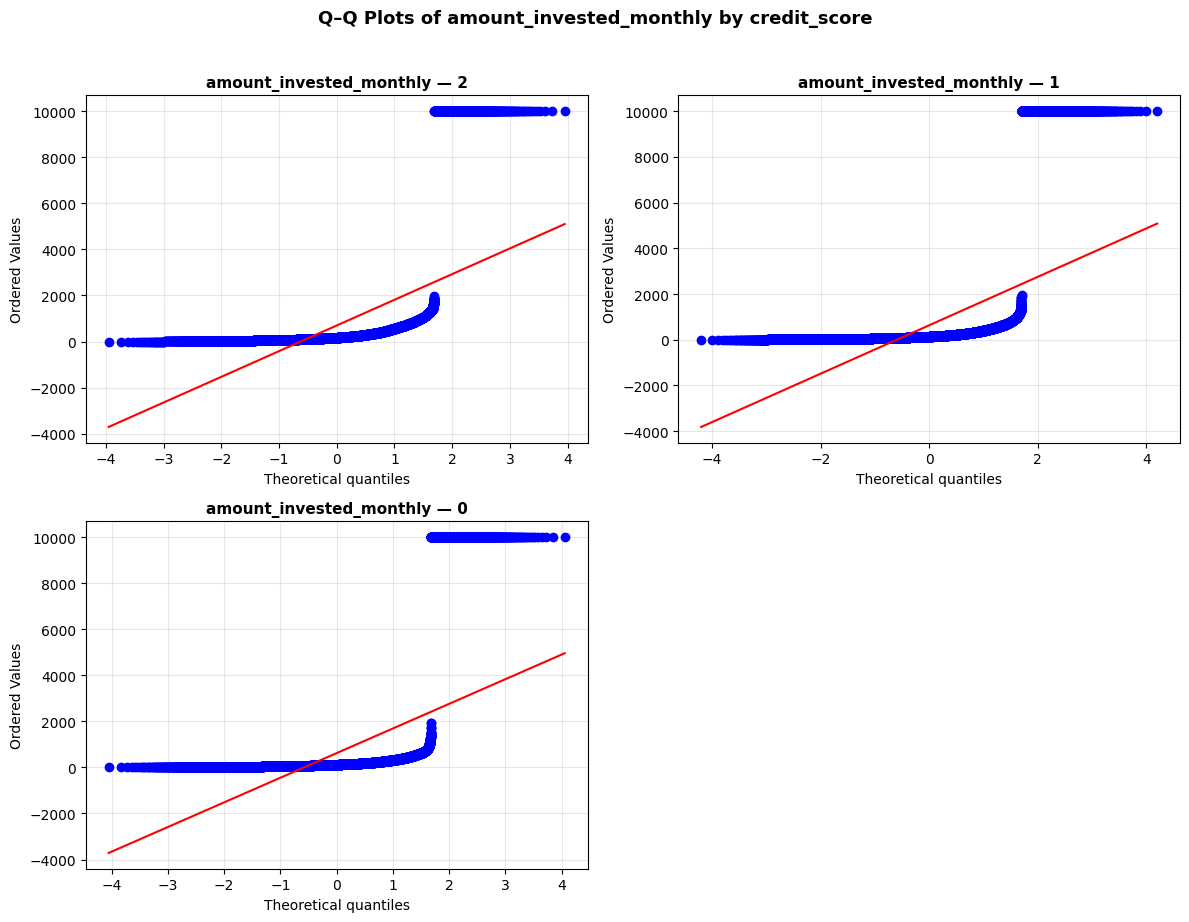

,Feature,Group,Skewness,Kurtosis,Remark
0,amount_invested_monthly,0,4.2530,16.1922,"Highly skewed, Heavy/light tails"
1,amount_invested_monthly,1,4.3517,17.1213,"Highly skewed, Heavy/light tails"
2,amount_invested_monthly,2,4.2668,16.5227,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: amount_invested_monthly ~ credit_score
Kruskal-Wallis H-statistic: 1302.872
p-value: 1.216050913413497e-283
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
               0              1              2
0   1.000000e+00   1.589076e-88  6.897652e-284
1   1.589076e-88   1.000000e+00  1.076502e-113
2  6.897652e-284  1.076502e-113   1.000000e+00


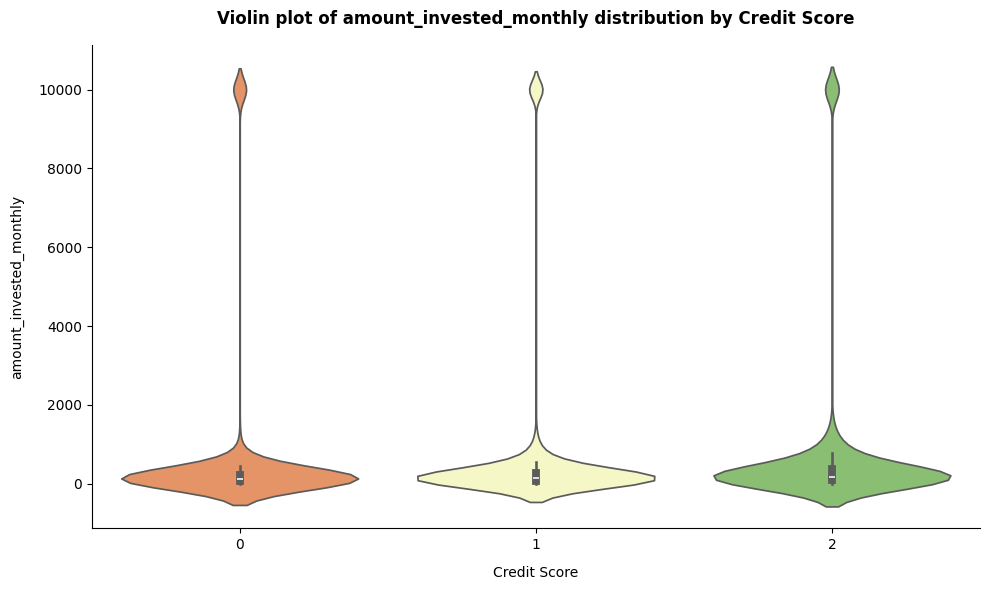

,credit_score,Count,Mean,Median,Std
0,2,17708,478.707898,404.336800,248.702514
1,1,51503,411.625470,346.065100,213.265889
2,0,27485,347.952384,300.046750,177.486947



 Checking normality of numeric feature(s) by target feature: 'credit_score'

🔹 Feature: monthly_balance


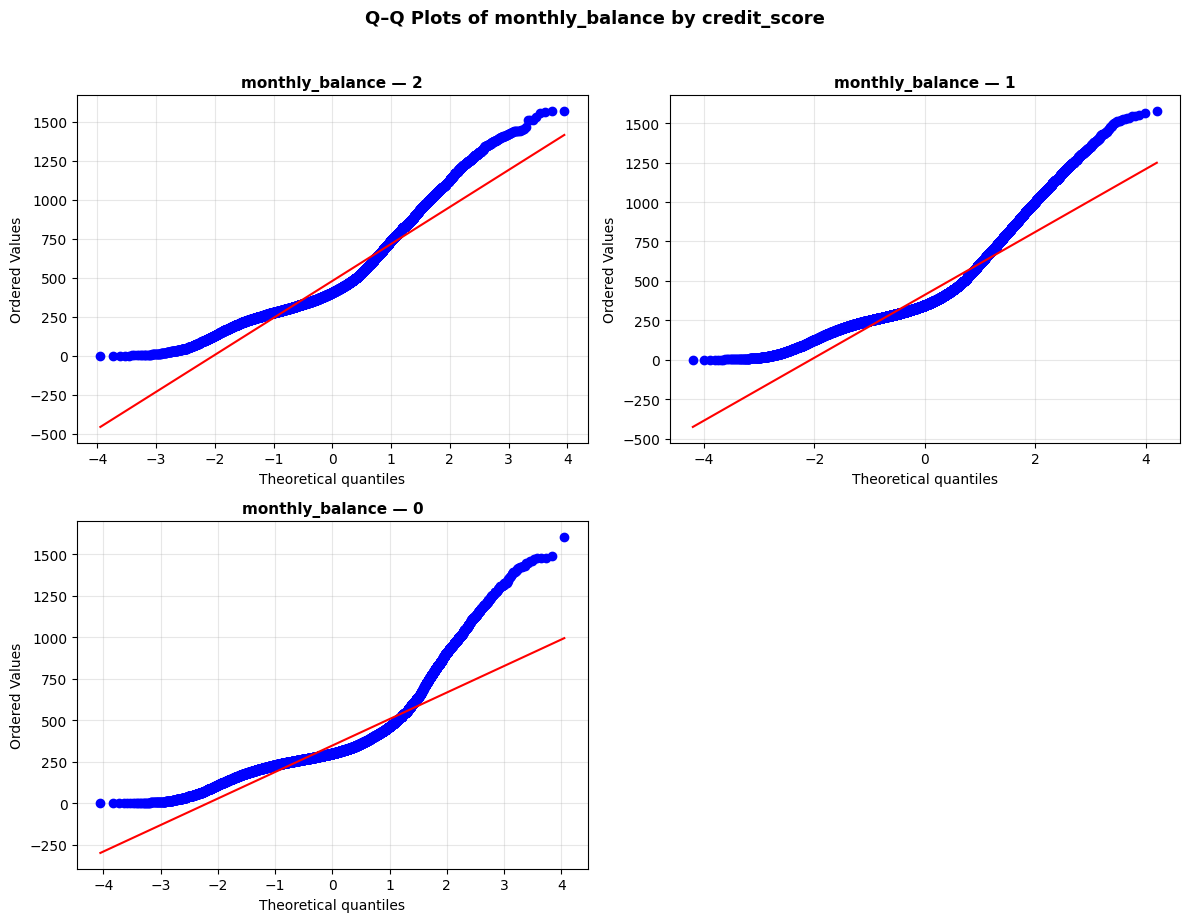

,Feature,Group,Skewness,Kurtosis,Remark
0,monthly_balance,0,2.1538,6.4863,"Highly skewed, Heavy/light tails"
1,monthly_balance,1,1.4783,2.4858,"Highly skewed, Heavy/light tails"
2,monthly_balance,2,1.1700,1.1949,"Highly skewed, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: monthly_balance ~ credit_score
Kruskal-Wallis H-statistic: 4967.453
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
     0              1              2
0  1.0   0.000000e+00   0.000000e+00
1  0.0   1.000000e+00  1.039831e-278
2  0.0  1.039831e-278   1.000000e+00


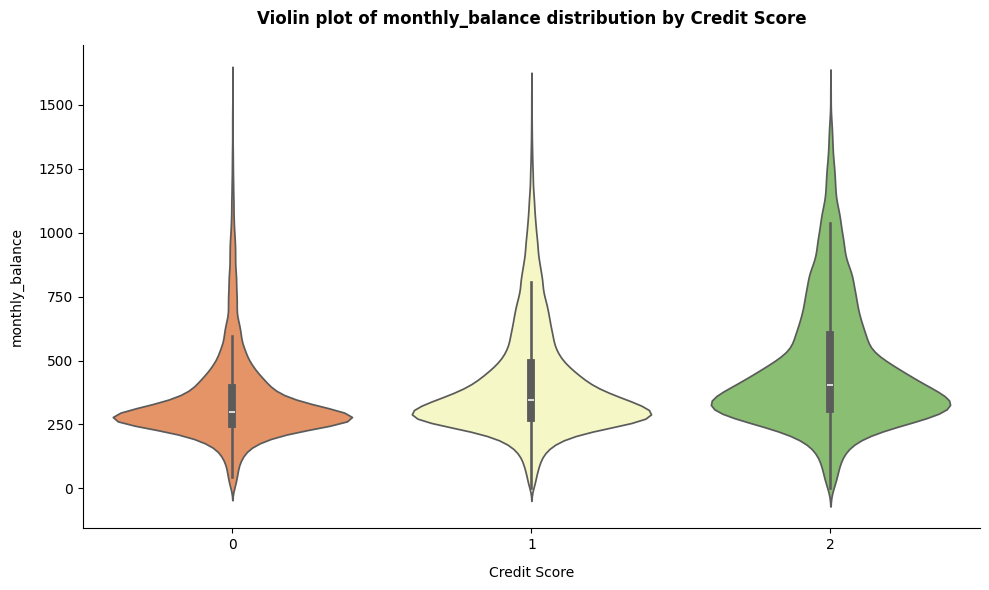

In [72]:
def perform_statical_testing(feature: str, df: pd.DataFrame = df,  target_feature: str = "credit_score") -> None:
    """
    Perform statistical tests (normality and Kruskal-Wallis) 
    to evaluate whether there are significant differences 
    in the distribution of a numerical feature across categories 
    of the target variable.

    Args:
        feature (str): Name of the numerical feature to be tested.
        df (pd.DataFrame): Dataset containing both numerical and target columns.
        target_feature (str): Name of the target categorical feature.

    Returns:
        None: Prints or displays statistical test results.
    """
    # Perform normality test (e.g., Shapiro-Wilk or D’Agostino test) for feature distribution
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    total_categories = df[target_feature].nunique()
    if total_categories > 2:
        if non_normal_detected == True:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    else:
        if non_normal_detected == True:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution(feature: str, df: pd.DataFrame = df,
                                target_feature: str = "credit_score", order: list = None) -> None:
    """
    Perform statistical testing and visualize the distribution of a numerical feature 
    across different classes of the target variable using violin plots and summary statistics.

    The function executes:
      1. Statistical tests.
      2. Summary table with mean, median, std per category.
      3. Violin plot for visualizing feature distributions across classes.

    Args:
        feature (str): The name of the numerical feature to analyze.
        df (pd.DataFrame): Input dataframe containing numerical & target features.
        target_feature (str): Target variable name (categorical feature).
        order (list, optional): Custom ordering for category display in the plot.

    Returns:
        None: Displays statistical summaries and plots directly.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False).reset_index(drop=True)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique()))
    
    plt.title(f"Violin plot of {feature} distribution by Credit Score", pad=15, weight="bold")
    plt.xlabel("Credit Score", labelpad=10)
    plt.ylabel(feature, labelpad=10)
    plt.legend().remove()
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature} by Credit Score</b></h2>"))
    plot_numerical_distribution(feature=feature, df = df)

### Insight Numerical Features by Credit Scores

`age`

Older customers tend to have **better credit scores**.
Although the differences are statistically significant, the practical effect size is **small**, so age alone is **not a strong predictor** of credit score.

`annual_income`

Customers with **higher annual income** tend to have **better credit scores**.
Income distribution shows **strong positive association** with creditworthiness — higher earnings likely improve repayment capacity and financial stability.

`monthly_inhand_salary`

Higher **monthly in-hand salary** is associated with a **better credit score**.
Income stability and higher take-home pay appear to **positively influence creditworthiness** and repayment reliability.

`credit_history_age`

Customers with **longer credit histories** tend to have **higher credit scores**.
This suggests that **credit experience and payment consistency over time** play a major role in improving creditworthiness.

`total_emi_per_month`

Customers with **better credit scores** generally handle **higher EMI obligations**, suggesting stronger repayment capacity.
However, the difference between *Standard* and *Good* groups is minimal — implying income and debt levels may already be well balanced in higher credit tiers.

`num_bank_accounts`

Individuals with **many bank accounts** tend to have **lower credit scores**, possibly due to **fragmented financial management or multiple obligations**.
Customers with **fewer, well-managed accounts** are more likely to maintain **higher credit scores**.

`num_credit_card`

Customers with **more credit cards** tend to have **lower credit scores**, possibly due to **higher debt exposure or fragmented credit management**.
In contrast, customers with **fewer cards** generally show **better credit discipline** and **stronger financial stability**.

`interest_rate`

Customers with **higher credit scores** enjoy **lower borrowing costs**, reflecting lender trust and lower risk.
Conversely, **low-score customers** face **higher interest rates**, indicating elevated credit risk and weaker repayment history.

`num_of_loan`

Customers with **more active loans** tend to have **lower credit scores**, possibly due to higher debt burden or credit overextension.
Meanwhile, those with **fewer loans** generally maintain **better credit health and repayment consistency**.

`delay_from_due_date`

Customers with **better credit scores** tend to **pay on time** or with **minimal delay**, while those with lower scores show **significant late payment behavior** — a clear indicator of higher credit risk.

`num_of_delayed_payment`

Customers with **frequent delayed payments** are more likely to have **poor credit scores**, confirming that **payment punctuality** is a strong determinant of creditworthiness.

`changed_credit_limit`

Frequent or large **credit limit changes** are more common among **lower credit score customers**, possibly reflecting **instability or overutilization**.
In contrast, **high-score customers** show **more stable credit limits**, suggesting consistent financial behavior and lender confidence.

`num_credit_inquiries`

Borrowers with **low credit scores** tend to **apply for credit more frequently**, which may signal **financial stress or over-reliance on borrowing**.
In contrast, **high-score individuals** show **stable credit behavior** with minimal new credit requests, reflecting stronger financial discipline.

`outstanding_debt`

Individuals with **poor credit scores** tend to carry **larger unpaid balances**, suggesting **inefficient debt management or repayment issues**.
Conversely, **high-credit-score** customers maintain **lower outstanding debts**, reflecting **responsible borrowing behavior** and better financial control.

`credit_utilization_ratio`

Although differences are statistically significant, the **practical effect is minimal** — all groups hover around ~32% utilization.
However, **high-score users** maintain **steady and balanced utilization**, while **low-score users** may show **volatile credit usage patterns**, impacting credit stability.

`amount_invested_monthly`

Individuals with **higher credit scores** tend to **invest more consistently each month**, suggesting stronger **financial capacity** and **wealth management behavior**.
In contrast, **low-score groups** invest less, reflecting **limited disposable income or higher financial obligations**.

`monthly_balance`

Individuals with **higher credit scores** maintain **larger and more consistent monthly balances**, reflecting **better financial management and stability**.
Conversely, those with **poor credit scores** often have **lower or fluctuating balances**, indicating **limited liquidity or inconsistent cash flow**.

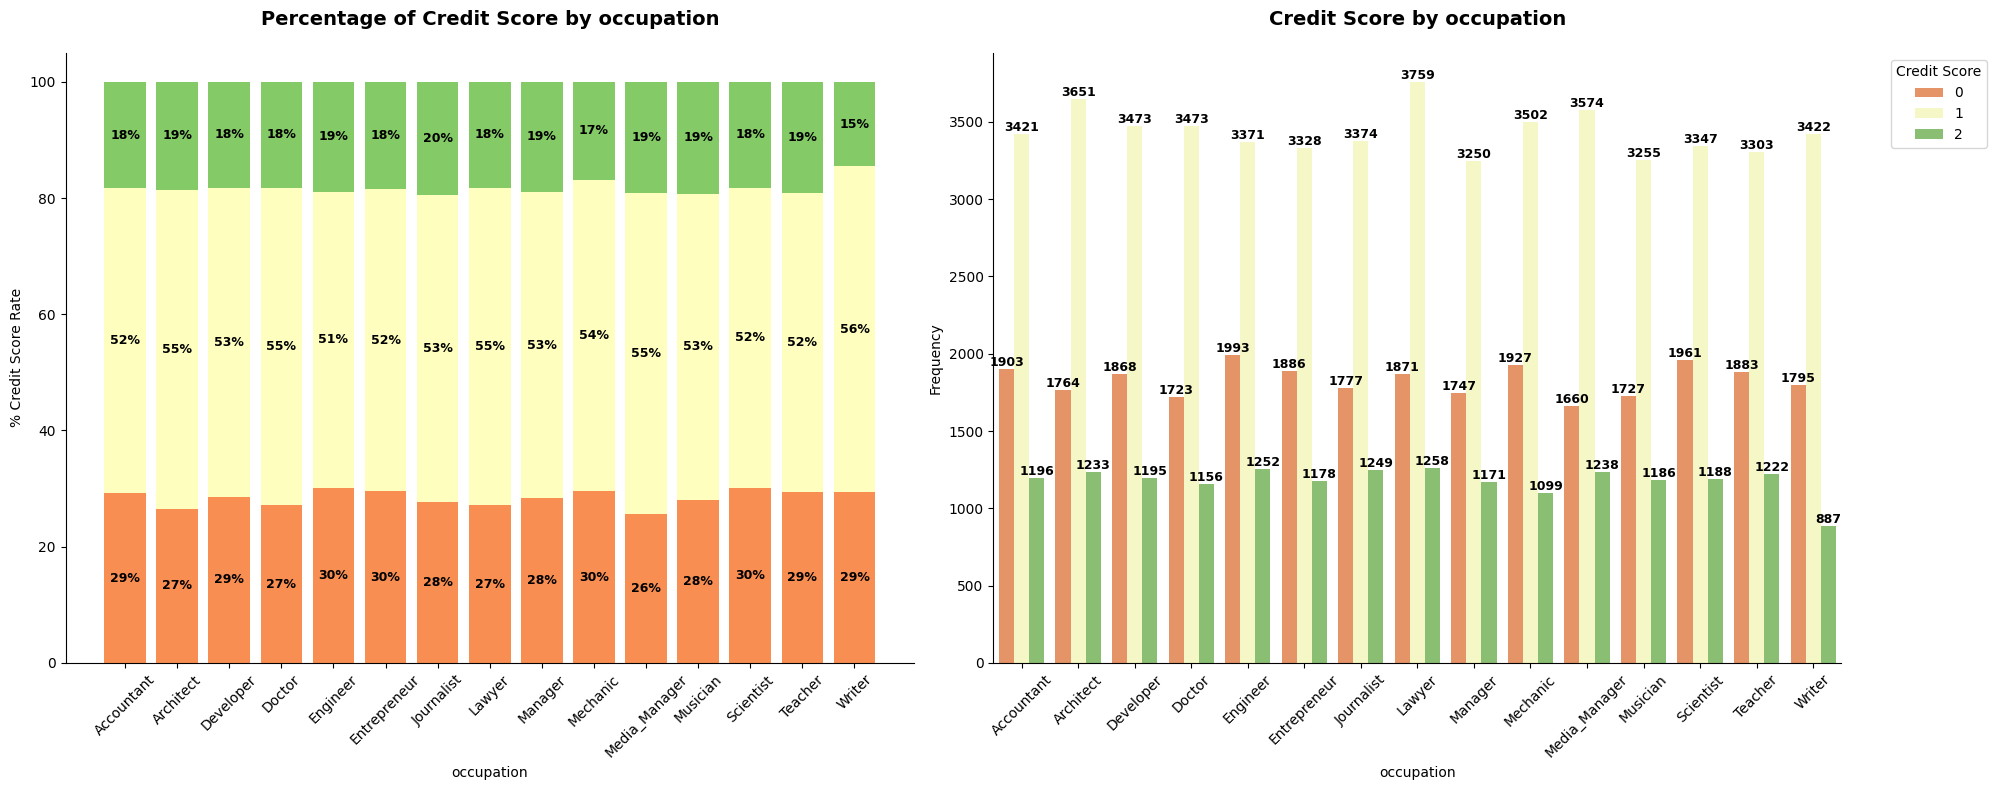


🔍 Chi-Square Test of Independence: 'occupation' vs. 'credit_score'
Chi-squared statistic: 169.767
Degrees of freedom: 28
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'occupation' and 'credit_score'.

📈 Standardized Residuals:
credit_score      0     1     2
occupation                     
Accountant     1.16 -0.88  0.06
Architect     -2.89  1.85  0.45
Developer      0.24 -0.14 -0.06
Doctor        -1.94  1.54 -0.21
Engineer       2.59 -2.58  1.16
Entrepreneur   1.62 -1.31  0.22
Journalist    -0.99 -0.60  2.25
Lawyer        -1.96  1.49 -0.10
Manager       -0.15 -0.61  1.23
Mechanic       1.66  0.42 -2.79
Media_Manager -4.19  2.16  1.53
Musician      -0.63 -0.53  1.68
Scientist      2.67 -1.92 -0.05
Teacher        1.44 -1.88  1.42
Writer         1.44  3.00 -6.90


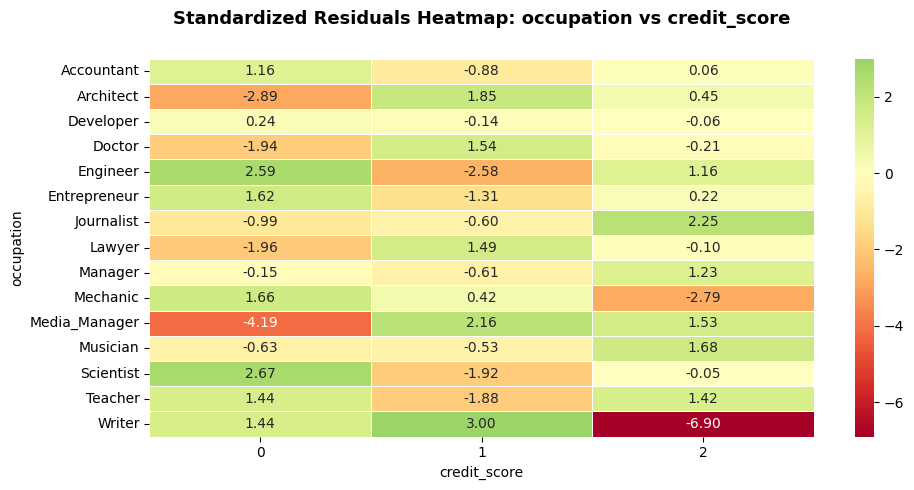

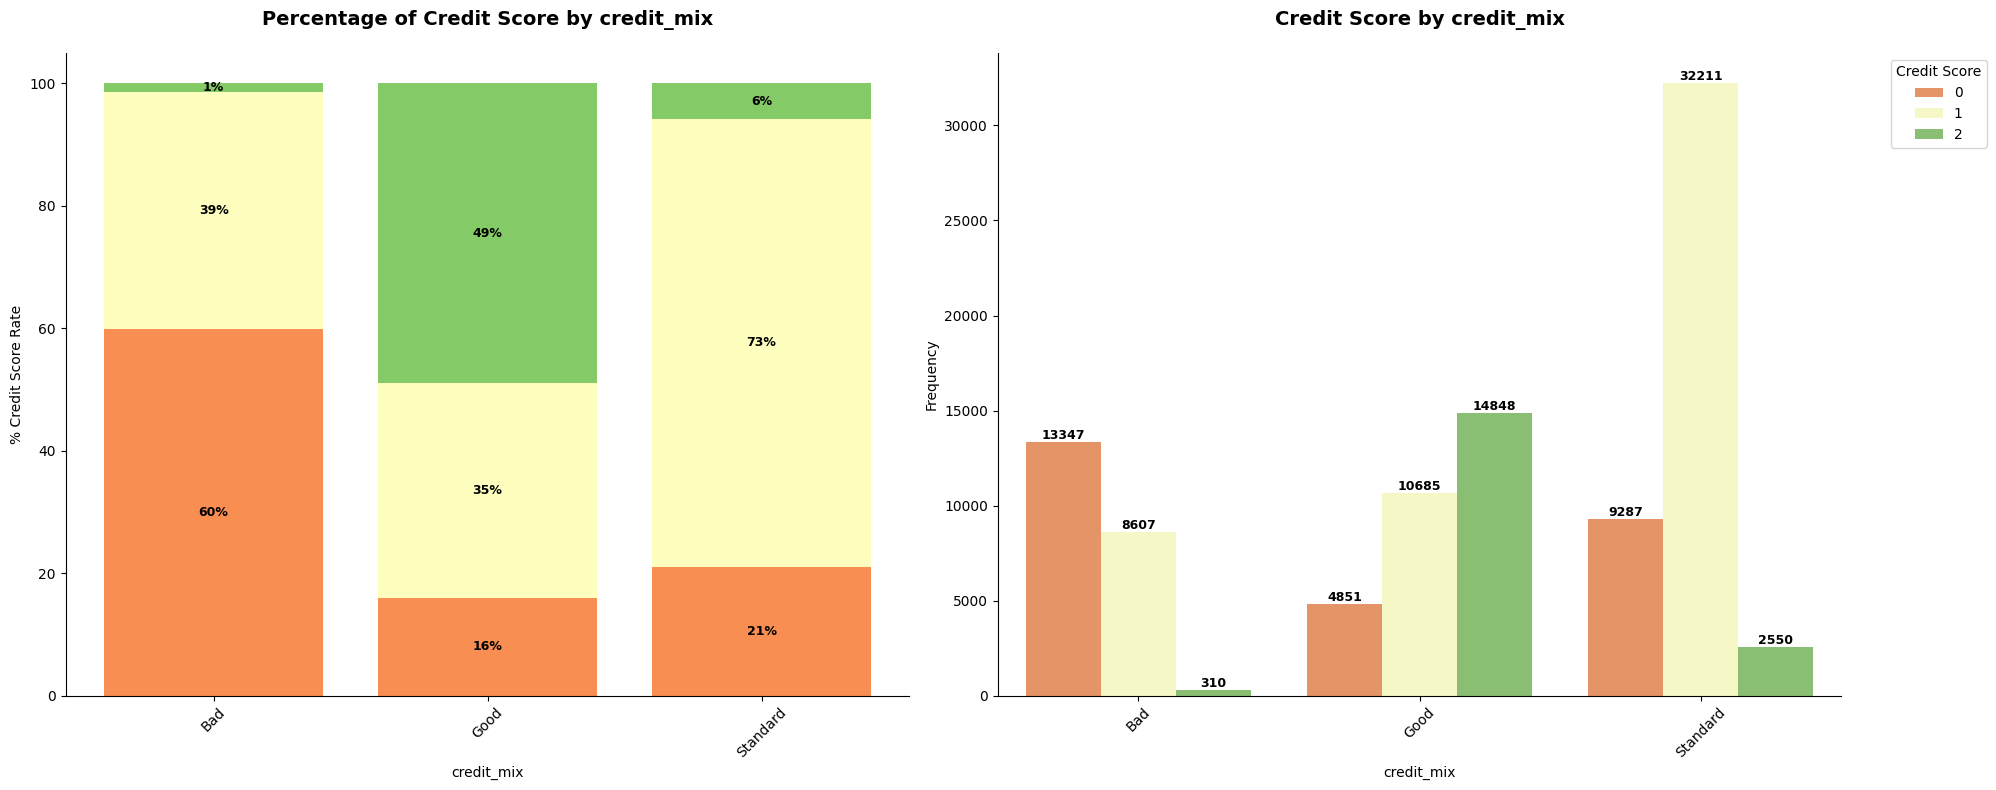


🔍 Chi-Square Test of Independence: 'credit_mix' vs. 'credit_score'
Chi-squared statistic: 39044.284
Degrees of freedom: 4
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'credit_mix' and 'credit_score'.

📈 Standardized Residuals:
credit_score      0      1       2
credit_mix                        
Bad           88.23 -29.86  -59.00
Good         -40.73 -43.22  124.46
Standard     -28.90  57.12  -61.42


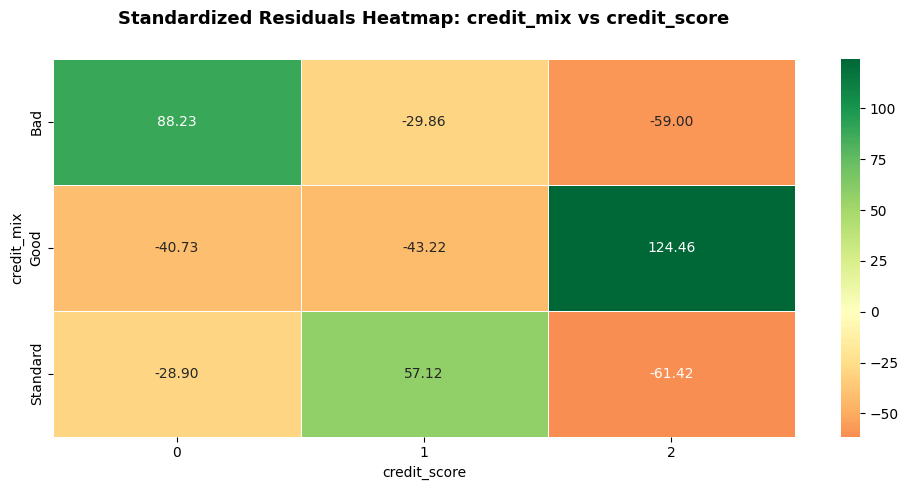

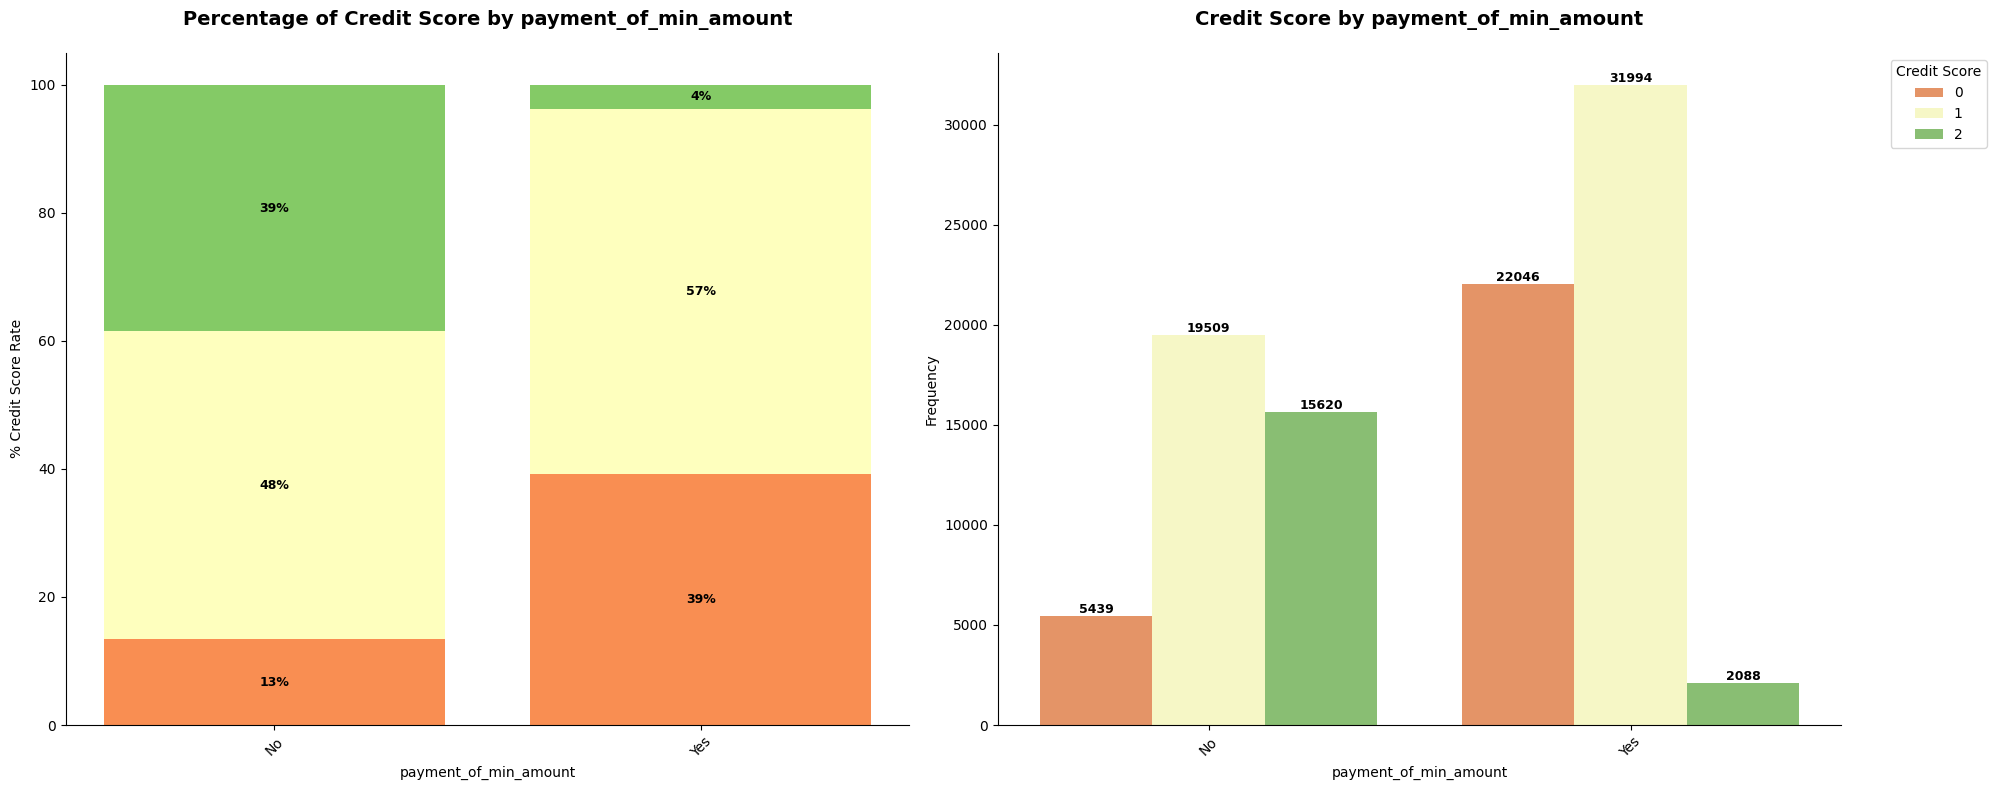


🔍 Chi-Square Test of Independence: 'payment_of_min_amount' vs. 'credit_score'
Chi-squared statistic: 21453.276
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'payment_of_min_amount' and 'credit_score'.

📈 Standardized Residuals:
credit_score               0      1      2
payment_of_min_amount                     
No                    -56.73 -14.28  95.03
Yes                    48.23  12.14 -80.79


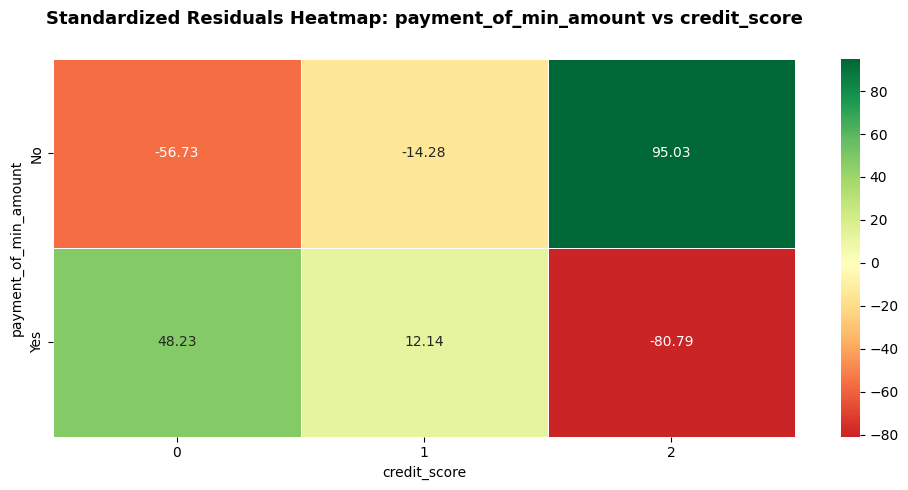

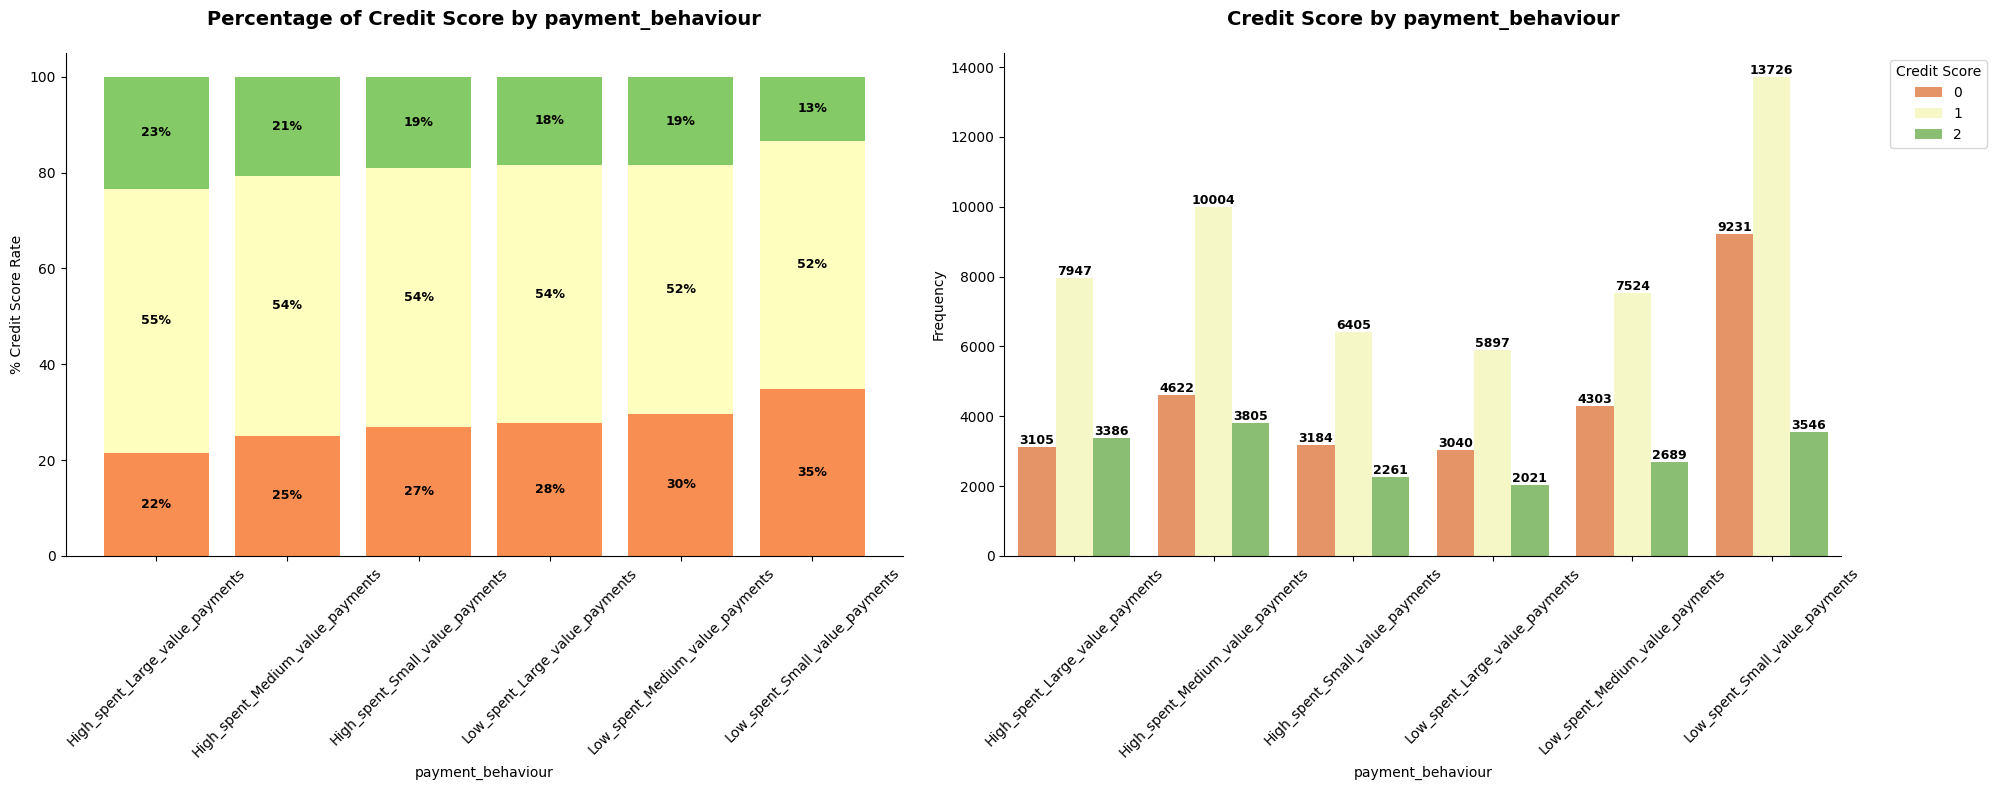


🔍 Chi-Square Test of Independence: 'payment_behaviour' vs. 'credit_score'
Chi-squared statistic: 1367.773
Degrees of freedom: 10
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'payment_behaviour' and 'credit_score'.

📈 Standardized Residuals:
credit_score                          0     1      2
payment_behaviour                                   
High_spent_Large_value_payments  -15.59  2.93  14.43
High_spent_Medium_value_payments  -8.52  1.89   7.40
High_spent_Small_value_payments   -3.17  1.18   1.95
Low_spent_Large_value_payments    -1.34  0.79   0.32
Low_spent_Medium_value_payments    2.75 -2.36   0.59
Low_spent_Small_value_payments    19.56 -3.28 -18.77


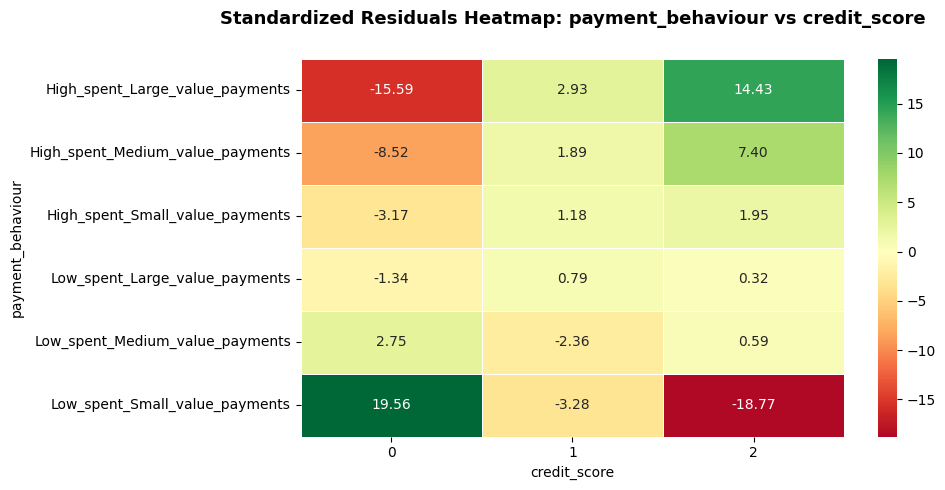

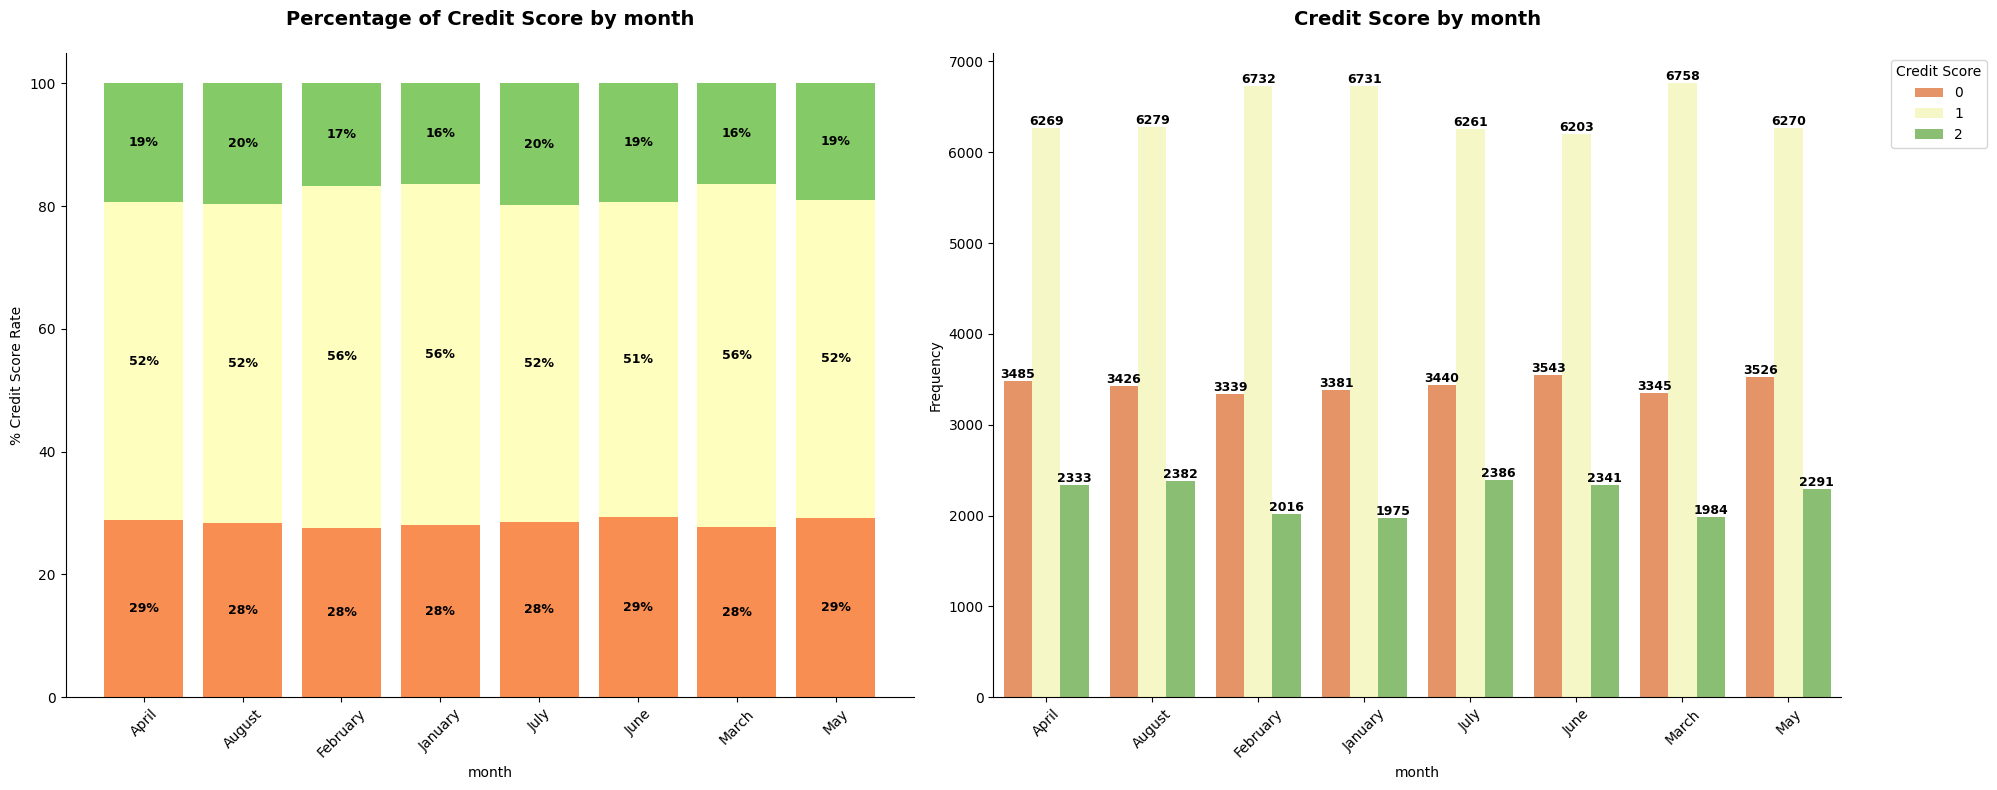


🔍 Chi-Square Test of Independence: 'month' vs. 'credit_score'
Chi-squared statistic: 191.205
Degrees of freedom: 14
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'month' and 'credit_score'.

📈 Standardized Residuals:
credit_score     0     1     2
month                         
April         0.84 -2.10  2.54
August       -0.16 -1.98  3.58
February     -1.65  3.67 -4.20
January      -0.93  3.65 -5.07
July          0.07 -2.20  3.67
June          1.83 -2.93  2.71
March        -1.55  3.99 -4.88
May           1.54 -2.09  1.65


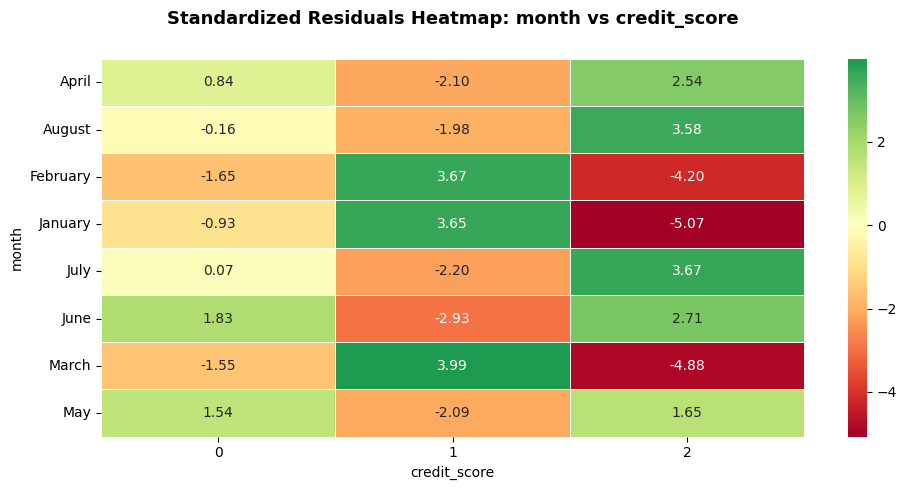

In [73]:
def bivariate_percent_plot(cat, df, figsize=(20, 8), order = None, rot = 0):
    
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {cat} by Credit Score</b></h2>"))
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=figsize)
    # Plot 1
    # Calculate the total number of each "cat" by credit_score
    grouped = df.groupby([cat, "credit_score"]).size().unstack(fill_value=0)
    # Calculate the percentages
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100
    if order is not None:
        percentages = percentages.loc[order]
    
    palette = color(n_colors=df["credit_score"].nunique())
    # Convert palette to dict for stacked bar color mapping
    color_map = dict(zip(percentages.columns, palette))
    # Draw stacked bar plot
    bottom = np.zeros(len(percentages))
    for fert in percentages.columns:
        ax[0].bar(percentages.index, percentages[fert], bottom=bottom, label=fert, color=color_map[fert])
        bottom += percentages[fert].values

    for container in ax[0].containers:
        ax[0].bar_label(container, fmt='%1.0f%%', label_type="center", weight="bold", fontsize=9)

    ax[0].set_title(f"Percentage of Credit Score by {cat}", fontsize=14, weight="bold", pad=20)
    ax[0].set_xlabel(f"{cat}")
    ax[0].set_ylabel("% Credit Score Rate")
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=rot)
    ax[0].legend().remove()
    sns.despine(left=False, bottom=False, ax=ax[0])

    # Plot 2
    sns.countplot(data=df, hue = "credit_score", x = cat,
                palette=palette, ax=ax[1], order=percentages.index)
    # Show value for each bar.
    for container in ax[1].containers:
        ax[1].bar_label(container, fmt="%d", label_type="edge", fontsize=9, weight="bold")

    ax[1].set_title(f"Credit Score by {cat}", fontsize=14, weight="bold", pad=20)
    ax[1].set_xlabel(f"{cat}")
    ax[1].set_ylabel("Frequency")
    ax[1].legend(title="Credit Score", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=rot)
    sns.despine(left=False, bottom=False, ax=ax[1])
    plt.tight_layout()
    plt.show()

    cal_ChiSquare(cat_feature=cat, target_feature="credit_score", df=df, show_residuals=True)

for feature in cat_features:
    bivariate_percent_plot(cat=feature, df= df, rot=45)

### Insight for Categorical Features by Churn

`occupation`

Occupation plays a **notable role** in credit score outcomes — professions with **stable or structured income** (e.g., Engineer, Scientist) tend to maintain **better credit health**, while **creative or irregular-income jobs** (e.g., Writer, Mechanic) show weaker credit performance.

`credit_mix`

A **well-balanced credit mix** contributes significantly to a **higher credit score**, while having only one or poor-quality credit source correlates with **lower creditworthiness**.

`payment_of_min_amount`

Regularly paying **only the minimum due** is strongly linked to **weaker credit performance**, while those who pay **more than the minimum** demonstrate **stronger financial discipline** and achieve **better credit scores**.

`month`

Credit performance shows **minor seasonal variation**, with slightly stronger scores observed mid-year — possibly linked to **annual income cycles** or **bonus payments** improving repayment ability.

## Overall Picture

| Feature                      | Type        | Statistical Test Used        | Relationship with Credit Score | Summary                                                                                                        |
| ---------------------------- | ----------- | ---------------------------- | ------------------------------ | -------------------------------------------------------------------------------------------------------------- |
| **Occupation**               | Categorical | Chi-Square Test              | ✅ Significant                  | Occupation is significantly associated with credit score; engineers and scientists show higher credit quality. |
| **Credit_Mix**               | Categorical | Chi-Square Test              | ✅ Significant                  | Customers with a *Good* credit mix are more likely to have a high credit score.                                |
| **Payment_of_Min_Amount**    | Categorical | Chi-Square Test              | ✅ Significant                  | Paying only the minimum amount is strongly linked with lower credit scores.                                    |
| **Month**                    | Categorical | Chi-Square Test              | ✅ Significant (weak)           | Slight seasonal variations; higher scores mid-year (e.g., June–August).                                        |
| **Age**                      | Numerical   | Welch’s ANOVA + Games–Howell | ✅ Significant                  | Older individuals tend to have higher credit scores.                                                           |
| **Annual_Income**            | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Higher income levels correspond to better credit scores.                                                       |
| **Monthly_Inhand_Salary**    | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Customers with higher monthly salary exhibit better credit scores.                                             |
| **Credit_History_Age**       | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Longer credit history correlates positively with higher credit score.                                          |
| **Total_EMI_per_Month**      | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Lower EMI burden is associated with stronger credit performance.                                               |
| **Num_Bank_Accounts**        | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Fewer bank accounts are generally linked to higher credit scores.                                              |
| **Num_Credit_Card**          | Numerical   | Welch’s ANOVA + Games–Howell | ✅ Significant                  | Customers with more credit cards tend to have poorer credit scores.                                            |
| **Interest_Rate**            | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Higher interest rates are linked with lower credit scores.                                                     |
| **Num_of_Loan**              | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Fewer active loans are associated with better credit health.                                                   |
| **Delay_from_Due_Date**      | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Customers with fewer payment delays show higher credit scores.                                                 |
| **Num_of_Delayed_Payment**   | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Lower frequency of delayed payments is tied to stronger credit scores.                                         |
| **Changed_Credit_Limit**     | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Credit limit stability correlates positively with good credit standing.                                        |
| **Num_Credit_Inquiries**     | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | More frequent credit inquiries are linked with lower credit scores.                                            |
| **Outstanding_Debt**         | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | High outstanding debt levels correlate with weaker credit performance.                                         |
| **Credit_Utilization_Ratio** | Numerical   | Welch’s ANOVA + Games–Howell | ✅ Significant (small effect)   | Minor differences; slightly higher utilization seen in good scorers.                                           |
| **Amount_Invested_Monthly**  | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Higher monthly investments reflect better financial stability.                                                 |
| **Monthly_Balance**          | Numerical   | Kruskal–Wallis + Dunn Test   | ✅ Significant                  | Positive monthly balance is strongly linked with higher credit scores.                                         |


## Business Questions

In [74]:
df_bq = df.copy()

### Multivariate Business Questions – Risk & Financial Behavior

#### How does the combination of income level and credit utilization ratio influence customers’ credit scores?

credit_score                            0          1          2
income_group utilization_group                                 
Low          Low                37.458444  51.421210  11.120346
             Medium             37.907280  51.228821  10.863899
             High               36.899979  51.596532  11.503489
Medium       Low                28.697862  52.698913  18.603225
             Medium             28.353772  53.065775  18.580453
             High               27.585521  53.241846  19.172633
High         Low                20.903505  55.473373  23.623122
             Medium             19.009883  56.032072  24.958046
             High               19.177544  54.788489  26.033968

Chi2: 3587.647204696735 p-value: 0.0
Chi2: 3587.6472 | dof: 16 | p-value: 0.000000


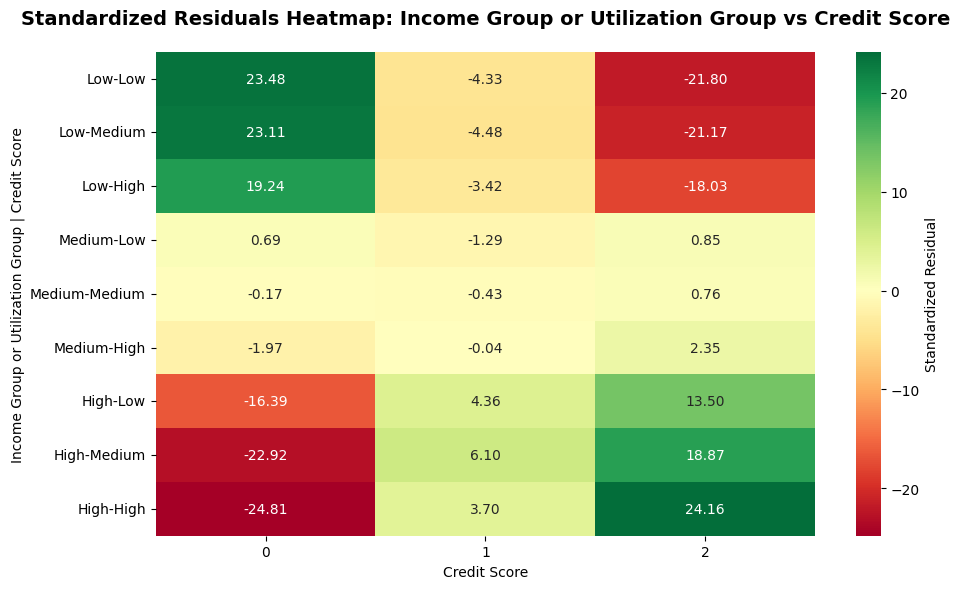

In [75]:
# Create bins for annual income and credit utilization
df_bq["income_group"] = pd.qcut(df_bq["annual_income"], q=3, labels=["Low", "Medium", "High"])
df_bq["utilization_group"] = pd.qcut(df_bq["credit_utilization_ratio"], q=3, labels=["Low", "Medium", "High"])

df_bq_income_group_utilization_group = pd.crosstab(
    [df_bq["income_group"], df_bq["utilization_group"]],
    df_bq["credit_score"],
    normalize="index"
) * 100

display(df_bq_income_group_utilization_group)

contingency = pd.crosstab(
    [df_bq["income_group"], df_bq["utilization_group"]],
    df_bq["credit_score"]
)
chi2, p, dof, ex = chi2_contingency(contingency)
print("Chi2:", chi2, "p-value:", p)

# 1) Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

print(f"Chi2: {chi2:.4f} | dof: {dof} | p-value: {p:.6f}")

# 2) Standardized residuals (adjusted)
#    r_ij = (O_ij - E_ij) / sqrt(E_ij * (1 - row_prob_i) * (1 - col_prob_j))
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# 3) Heatmap — display nicely the multiindex
plt.figure(figsize=(10,6))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Income Group or Utilization Group vs Credit Score", weight="bold", fontsize=14, pad=20)
plt.ylabel("Income Group or Utilization Group | Credit Score")
plt.xlabel("Credit Score")
plt.tight_layout()
plt.show()

**Answer**

> * Low-income customers, regardless of utilization level, are **significantly overrepresented in the Poor credit score group**.
> * High-income customers, especially those with **low-to-moderate utilization**, are **much more likely to achieve Good credit scores**.
> * Middle-income customers show a **balanced distribution**, indicating stable financial behavior.

#### Does the interaction between **age** and **number of delayed payments** explain variations in credit score? 

credit_score                                0          1          2
age_group           delay_group                                    
Teen (16-20)        None (0)        13.274336  37.168142  49.557522
                    Low (1-3)       12.734864  43.215031  44.050104
                    Moderate (4-8)  19.907407  47.839506  32.253086
                    High (9-15)     26.343490  59.085873  14.570637
                    Severe (16-28)  45.471951  51.120046   3.408003
Young Adult (21-30) None (0)        13.680154  31.791908  54.527938
                    Low (1-3)       16.007088  37.330183  46.662729
                    Moderate (4-8)  18.168093  48.590840  33.241067
                    High (9-15)     22.887526  62.052117  15.060356
                    Severe (16-28)  45.453798  49.416310   5.129891
Adult (31-40)       None (0)        15.643564  29.900990  54.455446
                    Low (1-3)       18.809981  35.060781  46.129239
                    Moderate (4-8)  16.787772  47.181158  36.031070
                    High (9-15)     24.359097  58.486610  17.154293
                    Severe (16-28)  41.842487  52.963440   5.194073
Middle-Aged (41-50) None (0)        13.541667  38.020833  48.437500
                    Low (1-3)       15.394165  39.044072  45.561763
                    Moderate (4-8)  16.096579  45.214142  38.689279
                    High (9-15)     20.357548  59.964749  19.677704
                    Severe (16-28)  36.495264  56.346414   7.158322
Senior (51-56)      None (0)        13.043478  35.785953  51.170569
                    Low (1-3)       20.044793  36.394177  43.561030
                    Moderate (4-8)  13.053479  42.725704  44.220817
                    High (9-15)     10.146444  61.436541  28.417015
                    Severe (16-28)   7.892882  72.868217  19.238901

Chi2: 16092.844483874018 p-value: 0.0
Chi2: 16092.8445 | dof: 48 | p-value: 0.000000


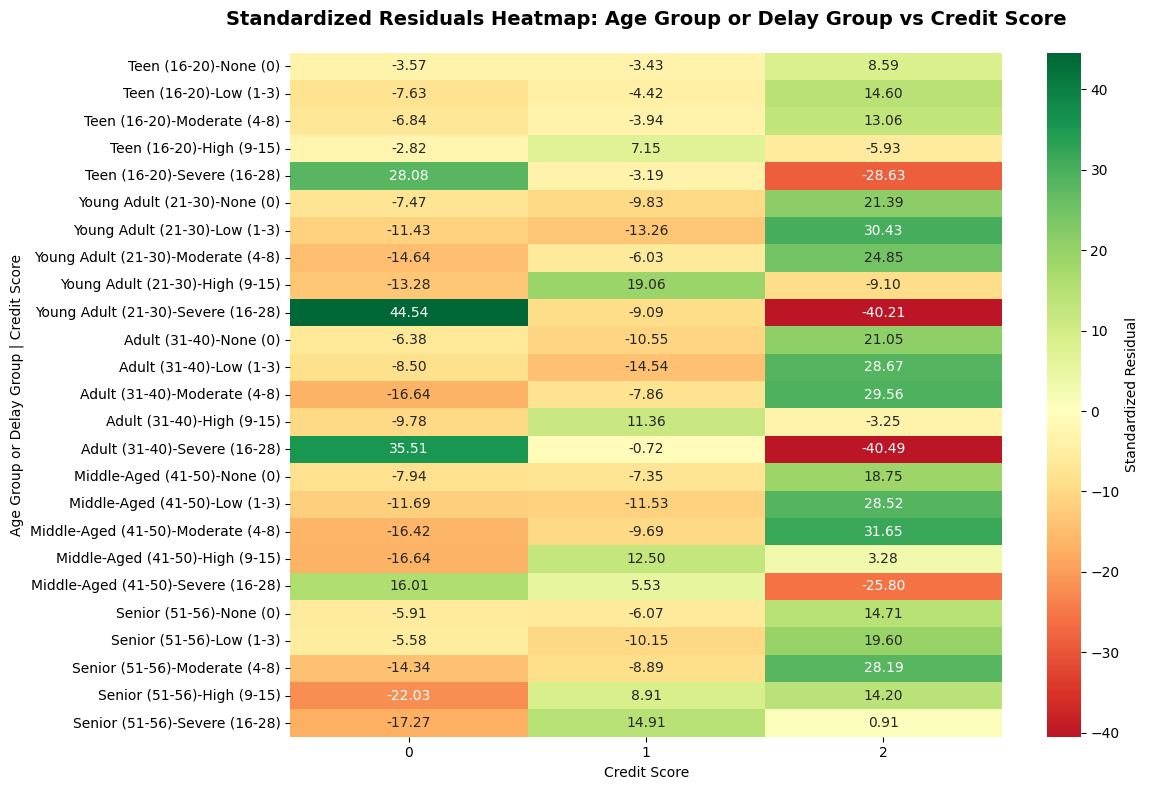

In [76]:
bins = [15, 20, 30, 40, 50, 56]
labels = ["Teen (16-20)", "Young Adult (21-30)", "Adult (31-40)", "Middle-Aged (41-50)", "Senior (51-56)"]
df_bq["age_group"] = pd.cut(df_bq["age"], bins=bins, labels=labels, right=True, include_lowest=True)

bins = [-1, 0, 3, 8, 15, 28]
labels = ["None (0)", "Low (1-3)", "Moderate (4-8)", "High (9-15)", "Severe (16-28)"]
df_bq["delay_group"] = pd.cut(df_bq["num_of_delayed_payment"], bins=bins, labels=labels)

df_bq_age_group_delay_group = pd.crosstab(
    [df_bq["age_group"], df_bq["delay_group"]],
    df_bq["credit_score"],
    normalize="index"
) * 100

display(df_bq_age_group_delay_group)

contingency = pd.crosstab(
    [df_bq["age_group"], df_bq["delay_group"]],
    df_bq["credit_score"]
)
chi2, p, dof, ex = chi2_contingency(contingency)
print("Chi2:", chi2, "p-value:", p)

# 1) Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

print(f"Chi2: {chi2:.4f} | dof: {dof} | p-value: {p:.6f}")

# 2) Standardized residuals (adjusted)
#    r_ij = (O_ij - E_ij) / sqrt(E_ij * (1 - row_prob_i) * (1 - col_prob_j))
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# 3) Heatmap — display nicely the multiindex
plt.figure(figsize=(12,8))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Age Group or Delay Group vs Credit Score", weight="bold", fontsize=14, pad=20)
plt.ylabel("Age Group or Delay Group | Credit Score")
plt.xlabel("Credit Score")
plt.tight_layout()
plt.show()


**Answer**

**Teen (16–20)**

* The `Severe (16–28)` delay group shows a **strong positive residual (+28.08)** with **low credit scores**, indicating these young customers are major contributors to poor credit outcomes.
* Conversely, those with `None` or `Low` delays show **negative residuals** at low scores → they are **less likely than expected** to have poor credit, showing good repayment discipline.

**Young Adult (21–30)**

* The `Severe (16–28)` group has **+44.54** for low credit scores and **–40.21** for high credit scores — the strongest deviation in the dataset.
  → Young adults with frequent payment delays **almost always have low credit scores**.
* In contrast, `None` and `Low` delay groups show positive residuals for high credit scores — consistent with **reliable repayment behavior** among responsible young borrowers.

**Adult (31–40)**

* `Severe` delays show **+35.51 (low)** and **–40.49 (high)**, following a similar pattern but slightly milder than young adults.
* Interestingly, `Moderate` and `High` delays show mild positive residuals for high credit scores, suggesting that **income stability may offset minor delinquencies**.

**Middle-Aged (41–50)**

* `Severe` delays still show a negative effect (**+16.01 low**, **–25.80 high**) but weaker than younger cohorts.
* `None` or `Low` delay groups have strong **positive residuals (+28–31)** for high credit scores, making this the **most stable and trustworthy segment**.

**Senior (51–56)**

* `None` and `Low` delay groups show **positive residuals (+14–19)** for high credit scores — confirming **excellent repayment history**.
* Even with `Moderate` or `High` delays, deviations are mild, suggesting that **credit maturity reduces the negative impact** of delayed payments.

✅ **Yes, strongly.**
There is a statistically significant interaction:

* Younger individuals with high delayed payments are far more likely to have low credit scores.
* Older individuals with few or no delays tend to have high credit scores.
* The standardized residuals reveal non-random deviations across categories, confirming that age moderates the impact of delayed payments on credit score.

#### How do **occupation** and **annual income** jointly affect the likelihood of having a poor credit score?

credit_score                        0          1          2
income_group occupation                                    
Low          Accountant     37.121212  51.609848  11.268939
             Architect      35.531496  53.149606  11.318898
             Developer      35.583942  52.737226  11.678832
             Doctor         36.174912  51.545936  12.279152
             Engineer       37.968165  50.936330  11.095506
             Entrepreneur   36.486486  52.171815  11.341699
             Journalist     35.231317  52.001779  12.766904
             Lawyer         35.672757  52.408638  11.918605
             Manager        38.739669  52.014463   9.245868
             Mechanic       38.576159  51.365894  10.057947
             Media_Manager  37.077068  49.765038  13.157895
             Musician       37.602881  53.343621   9.053498
             Scientist      39.144737  50.610902  10.244361
             Teacher        40.263158  48.684211  11.052632
             Writer         40.960744  48.863636  10.175620
Medium       Accountant     29.470803  50.547445  19.981752
             Architect      29.401993  52.990033  17.607973
             Developer      29.029304  53.846154  17.124542
             Doctor         24.949393  57.236842  17.813765
             Engineer       33.577586  47.758621  18.663793
             Entrepreneur   29.903846  51.346154  18.750000
             Journalist     24.446494  54.658672  20.894834
             Lawyer         26.088850  54.224739  19.686411
             Manager        27.528090  50.842697  21.629213
             Mechanic       30.020080  53.514056  16.465863
             Media_Manager  25.492832  55.689964  18.817204
             Musician       27.528090  51.825843  20.646067
             Scientist      29.492188  50.976562  19.531250
             Teacher        26.892430  51.593625  21.513944
             Writer         29.328794  58.414397  12.256809
High         Accountant     21.344765  55.189531  23.465704
             Architect      15.126812  58.650362  26.222826
             Developer      21.018519  52.824074  26.157407
             Doctor         19.460227  55.634470  24.905303
             Engineer       18.657407  54.398148  26.944444
             Entrepreneur   22.678571  52.633929  24.687500
             Journalist     22.933468  51.411290  25.655242
             Lawyer         18.910256  57.326007  23.763736
             Manager        19.513359  55.200382  25.286260
             Mechanic       18.726415  56.367925  24.905660
             Media_Manager  14.299242  60.227273  25.473485
             Musician       19.540230  53.208812  27.250958
             Scientist      22.586207  52.844828  24.568966
             Teacher        20.047170  54.575472  25.377358
             Writer         18.892045  60.369318  20.738636

Chi2: 3966.4487337775545 p-value: 0.0
Chi2: 3966.4487 | dof: 88 | p-value: 0.000000


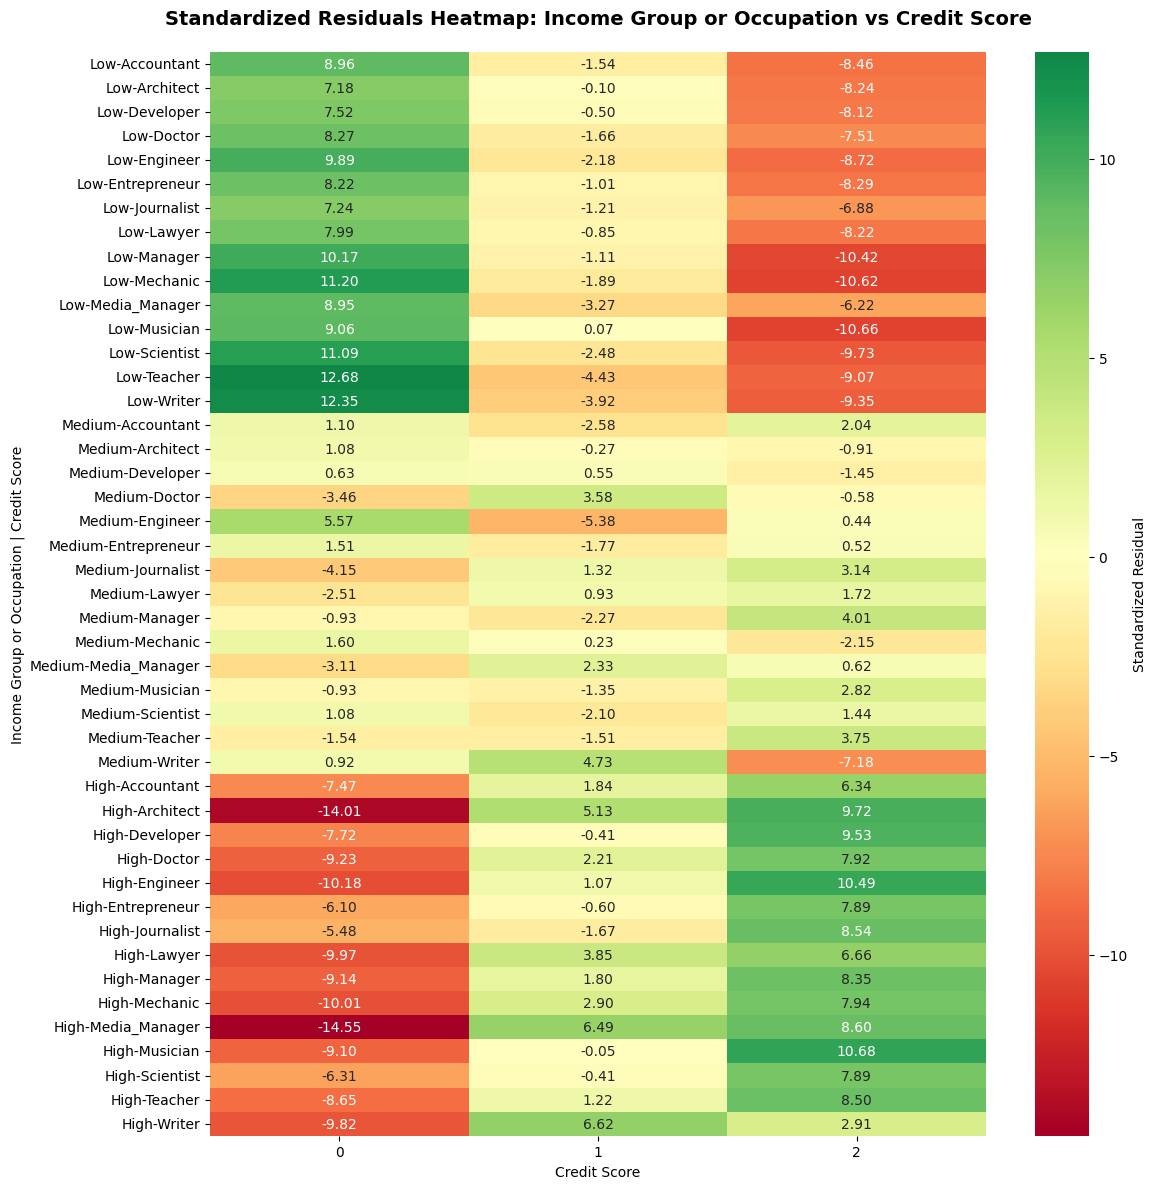

In [77]:
df_bq["income_group"] = pd.qcut(df_bq["annual_income"], q=3, labels=["Low", "Medium", "High"])

df_bq_income_group_occupation = pd.crosstab(
    [df_bq["income_group"], df_bq["occupation"]],
    df_bq["credit_score"],
    normalize="index"
) * 100

display(df_bq_income_group_occupation)

contingency = pd.crosstab(
    [df_bq["income_group"], df_bq["occupation"]],
    df_bq["credit_score"]
)
chi2, p, dof, ex = chi2_contingency(contingency)
print("Chi2:", chi2, "p-value:", p)

# 1) Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

print(f"Chi2: {chi2:.4f} | dof: {dof} | p-value: {p:.6f}")

# 2) Standardized residuals (adjusted)
#    r_ij = (O_ij - E_ij) / sqrt(E_ij * (1 - row_prob_i) * (1 - col_prob_j))
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# 3) Heatmap — display nicely the multiindex
plt.figure(figsize=(12,12))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Income Group or Occupation vs Credit Score", weight="bold", fontsize=14, pad=20)
plt.ylabel("Income Group or Occupation | Credit Score")
plt.xlabel("Credit Score")
plt.tight_layout()
plt.show()

**Answer**

There is a **strong joint effect** between **occupation** and **annual income** on credit score.

* **Low-income individuals** across all occupations show **higher likelihood of poor credit** (strong positive residuals in low-score column). Income level dominates occupation — even stable jobs like *Doctor* or *Engineer* struggle with low credit at this tier.
* **Medium-income groups** show **balanced outcomes** — occupation starts to matter, with *Doctors* and *Managers* performing slightly better.
* **High-income professionals** (especially *Architects, Engineers, Lawyers, Scientists*) have **very low probability of poor credit** and **strong positive residuals for high credit scores**, showing excellent financial reliability.

👉 **Summary:**
Income is the **primary driver** of credit risk, while occupation **amplifies or mitigates** that effect.
High-skill, high-income professions are the **most creditworthy**, whereas low-income groups remain **high-risk regardless of job type**.

#### How does **credit mix quality** interact with **outstanding debt** to impact credit score performance?

credit_score                   0          1          2
credit_mix debt_group                                 
Bad        Low         78.023256  21.976744   0.000000
           Moderate    69.928966  29.331097   0.739937
           High        47.145522  50.690299   2.164179
           Very High   47.345483  50.297147   2.357369
Good       Very Low    15.234075  34.267076  50.498849
           Low         16.347695  35.636273  48.016032
Standard   Very Low     5.945230  86.210247   7.844523
           Low         11.051031  82.392700   6.556269
           Moderate    66.232332  32.553004   1.214664

Chi2: 52681.726356864965 p-value: 0.0
Chi2: 52681.7264 | dof: 16 | p-value: 0.000000


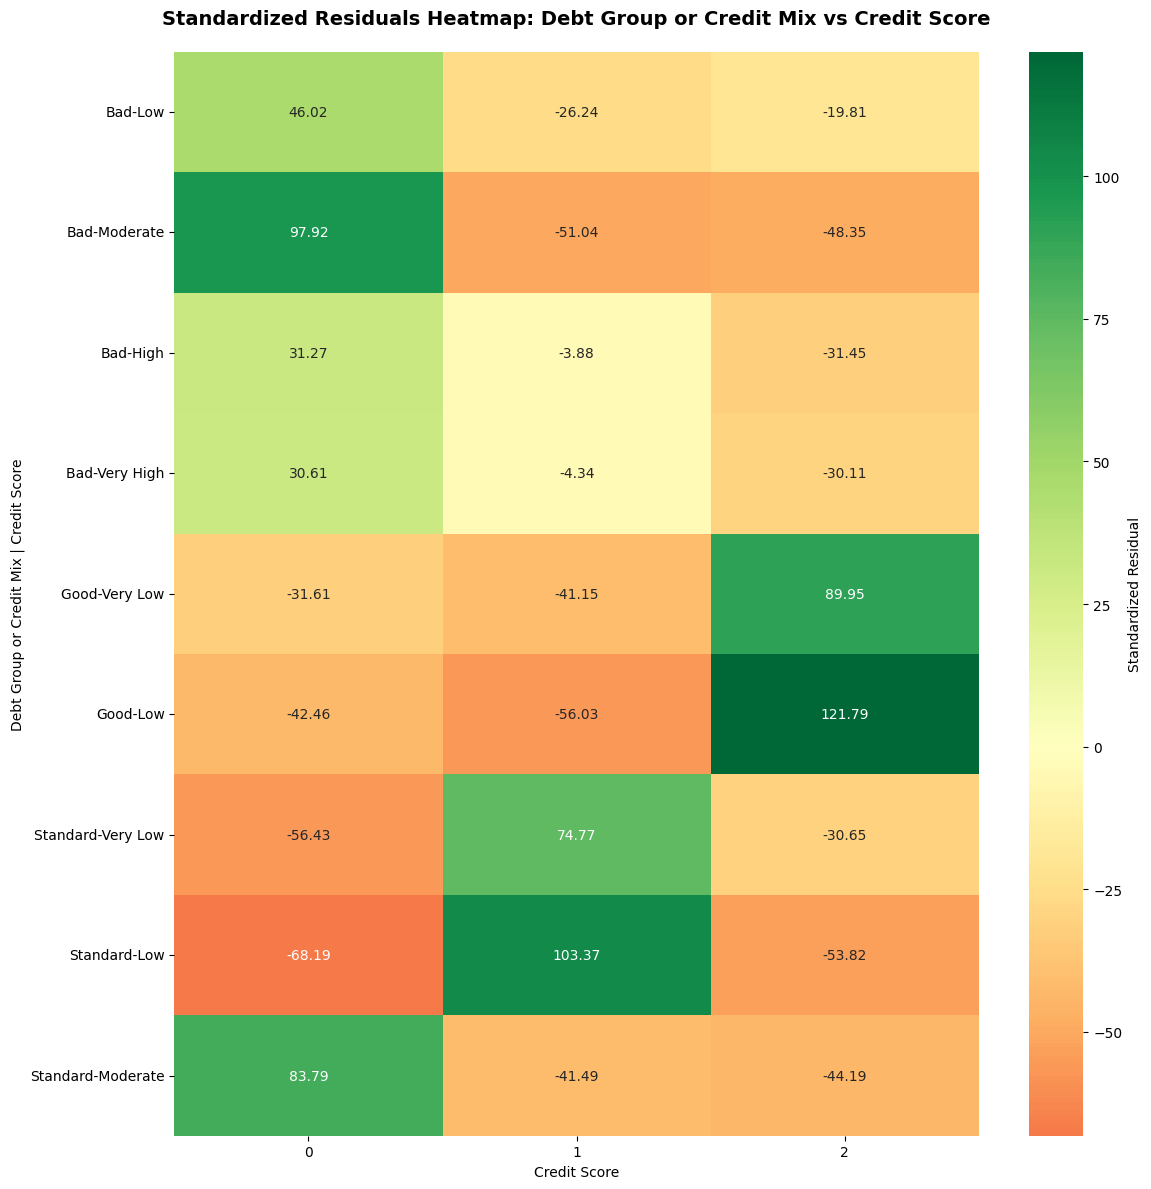

In [78]:
bins = [0, 500, 1500, 3000, 4000, 5000]
labels = ["Very Low", "Low", "Moderate", "High", "Very High"]
df_bq["debt_group"] = pd.cut(df_bq["outstanding_debt"], bins=bins, labels=labels, right=True, include_lowest=True)

df_bq_credit_mix_debt_group = pd.crosstab(
    [df_bq["credit_mix"], df_bq["debt_group"]],
    df_bq["credit_score"],
    normalize="index"
) * 100

display(df_bq_credit_mix_debt_group)

contingency = pd.crosstab(
    [df_bq["credit_mix"], df_bq["debt_group"]],
    df_bq["credit_score"]
)
chi2, p, dof, ex = chi2_contingency(contingency)
print("Chi2:", chi2, "p-value:", p)

# 1) Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

print(f"Chi2: {chi2:.4f} | dof: {dof} | p-value: {p:.6f}")

# 2) Standardized residuals (adjusted)
#    r_ij = (O_ij - E_ij) / sqrt(E_ij * (1 - row_prob_i) * (1 - col_prob_j))
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# 3) Heatmap — display nicely the multiindex
plt.figure(figsize=(12,12))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Debt Group or Credit Mix vs Credit Score", weight="bold", fontsize=14, pad=20)
plt.ylabel("Debt Group or Credit Mix | Credit Score")
plt.xlabel("Credit Score")
plt.tight_layout()
plt.show()

**Answer**

The heatmap shows a **strong interaction** between **credit mix quality** and **outstanding debt** in determining credit score performance.

* **Bad credit mix + Moderate/High debt** groups have **very high positive residuals** for low credit scores (up to +97.9), meaning they are **most likely to experience poor credit performance**.
* **Good credit mix + Low or Very Low debt** groups show **strong positive residuals** for high credit scores (+90 to +120), indicating **excellent credit stability**.
* **Standard credit mix** groups fall in between — higher debt levels shift them toward lower credit scores.

👉 **Summary:**
A **good and diversified credit mix** greatly improves credit performance, especially when combined with **low outstanding debt**.
Conversely, **bad credit mix and moderate-to-high debt** dramatically increase the likelihood of **poor credit scores**.

####  Does **payment behavior** (on-time vs. delayed) vary by **income group** and **credit mix type**?

payment_behaviour        High_spent_Large_value_payments  \
income_group credit_mix                                    
Low          Bad                                4.865947   
             Good                               6.482143   
             Standard                           5.738246   
Medium       Bad                               13.714520   
             Good                              11.958204   
             Standard                          12.280340   
High         Bad                               23.201856   
             Good                              28.370709   
             Standard                          25.934710   

payment_behaviour        High_spent_Medium_value_payments  \
income_group credit_mix                                     
Low          Bad                                 8.217270   
             Good                               11.767857   
             Standard                           10.050185   
Medium       Bad                                26.774017   
             Good                               24.806502   
             Standard                           24.581274   
High         Bad                                25.087007   
             Good                               20.902547   
             Standard                           23.116629   

payment_behaviour        High_spent_Small_value_payments  \
income_group credit_mix                                    
Low          Bad                               10.080084   
             Good                              11.071429   
             Standard                          10.565240   
Medium       Bad                               15.515830   
             Good                              14.734907   
             Standard                          15.142779   
High         Bad                               12.412993   
             Good                              11.004983   
             Standard                          11.077009   

payment_behaviour        Low_spent_Large_value_payments  \
income_group credit_mix                                   
Low          Bad                              11.290042   
             Good                             11.875000   
             Standard                         11.813259   
Medium       Bad                              11.626638   
             Good                             12.674149   
             Standard                         12.898133   
High         Bad                               9.773782   
             Good                              9.551495   
             Standard                         10.107422   

payment_behaviour        Low_spent_Medium_value_payments  \
income_group credit_mix                                    
Low          Bad                               18.036212   
             Good                              16.571429   
             Standard                          17.095880   
Medium       Bad                                9.729803   
             Good                              10.303793   
             Standard                           9.568918   
High         Bad                               15.516241   
             Good                              19.096069   
             Standard                          17.166574   

payment_behaviour        Low_spent_Small_value_payments  
income_group credit_mix                                  
Low          Bad                              47.510446  
             Good                             42.232143  
             Standard                         44.737190  
Medium       Bad                              22.639192  
             Good                             25.522446  
             Standard                         25.528556  
High         Bad                              14.008121  
             Good                             11.074197  
             Standard                         12.597656

Chi2: 15509.72134319228 p-value: 0.0
Chi2: 15509.7213 | dof: 40 | p-value: 0.000000


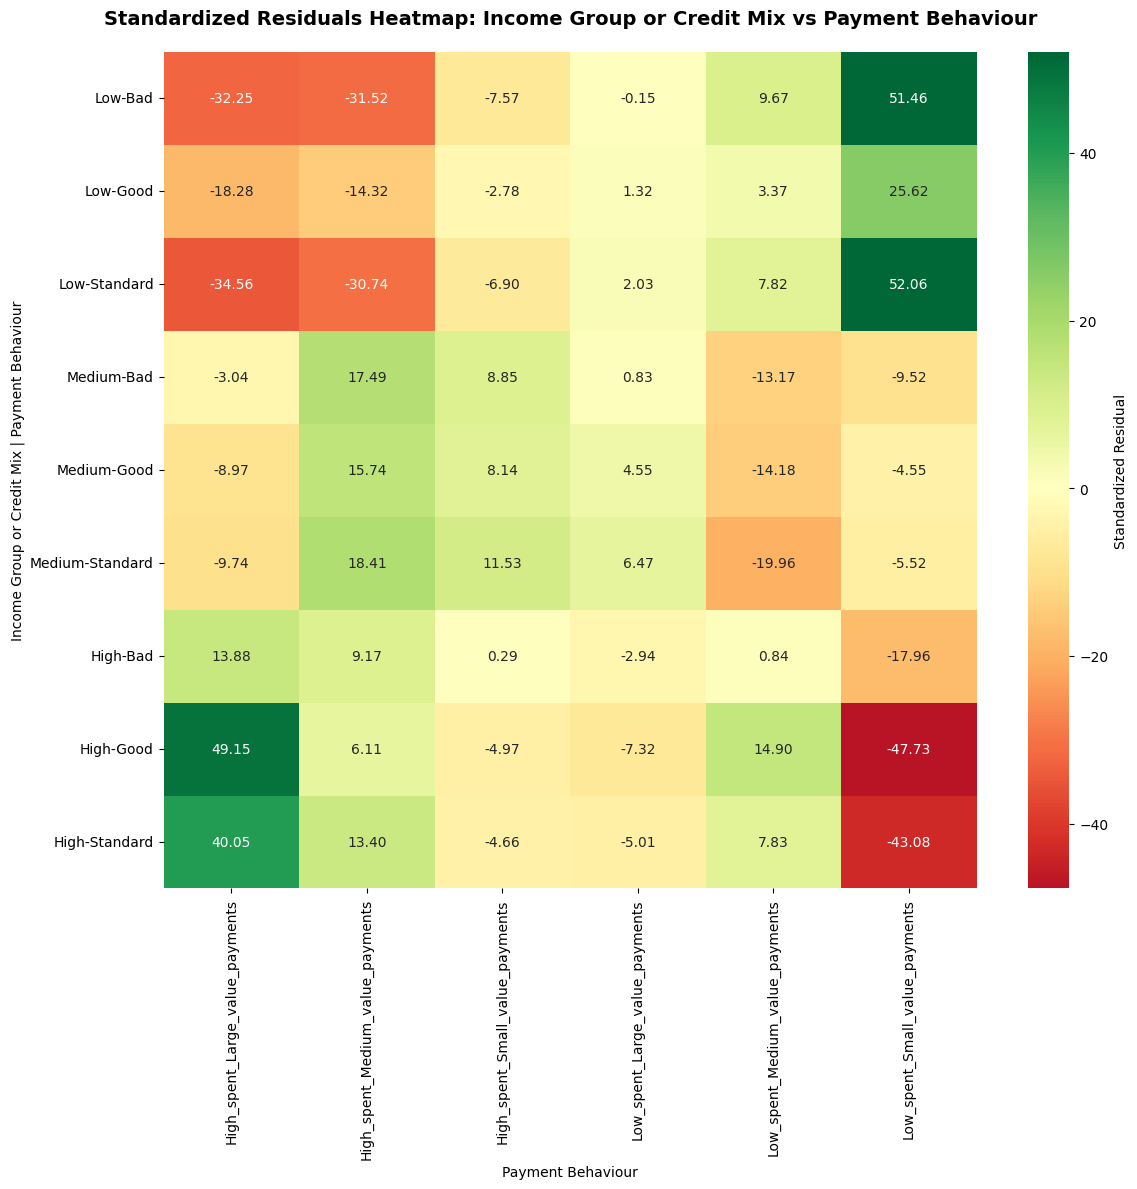

In [79]:
df_bq_income_group_credit_mix = pd.crosstab(
    [df_bq["income_group"], df_bq["credit_mix"]],
    df_bq["payment_behaviour"],
    normalize="index"
) * 100

display(df_bq_income_group_credit_mix)

contingency = pd.crosstab(
    [df_bq["income_group"], df_bq["credit_mix"]],
    df_bq["payment_behaviour"]
)
chi2, p, dof, ex = chi2_contingency(contingency)
print("Chi2:", chi2, "p-value:", p)

# 1) Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

print(f"Chi2: {chi2:.4f} | dof: {dof} | p-value: {p:.6f}")

# 2) Standardized residuals (adjusted)
#    r_ij = (O_ij - E_ij) / sqrt(E_ij * (1 - row_prob_i) * (1 - col_prob_j))
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# 3) Heatmap — display nicely the multiindex
plt.figure(figsize=(12,12))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Income Group or Credit Mix vs Payment Behaviour", weight="bold", fontsize=14, pad=20)
plt.ylabel("Income Group or Credit Mix | Payment Behaviour")
plt.xlabel("Payment Behaviour")
plt.tight_layout()
plt.show()

**Answer**

The heatmap shows that **payment behavior strongly varies by income level and credit mix quality**:

* **Low-income groups** (Low-Bad, Low-Good, Low-Standard) have **very high positive residuals** for *low-spent / small-value payments* (+25 to +52), meaning they are **more likely to make minimal or delayed payments**, showing weaker repayment capacity.
* **Medium-income groups** show a **balanced mix**, with moderate residuals across spending categories — indicating **average, more consistent payment behavior**.
* **High-income groups** (especially *High-Good* and *High-Standard*) have **strong positive residuals** for *high-spent / large-value payments* (+40 to +49) and strong negatives for *low-spent small-value payments* (–40 to –47).
  → They are **more likely to make larger, timely payments** and maintain good credit utilization.

👉 **Summary:**
**Payment behavior improves with higher income and stronger credit mix quality.**
Low-income borrowers tend to pay small or delayed amounts, while high-income individuals with good credit mix show **timely, higher-value payments**, reflecting stronger financial discipline.

### Portfolio & Risk Management-Oriented Questions

#### Which combination of **occupation**, **loan count**, and **EMI** is most associated with poor credit scores?

Chi2 = 13198.76, p-value = 0.0000
→ Significant relationship


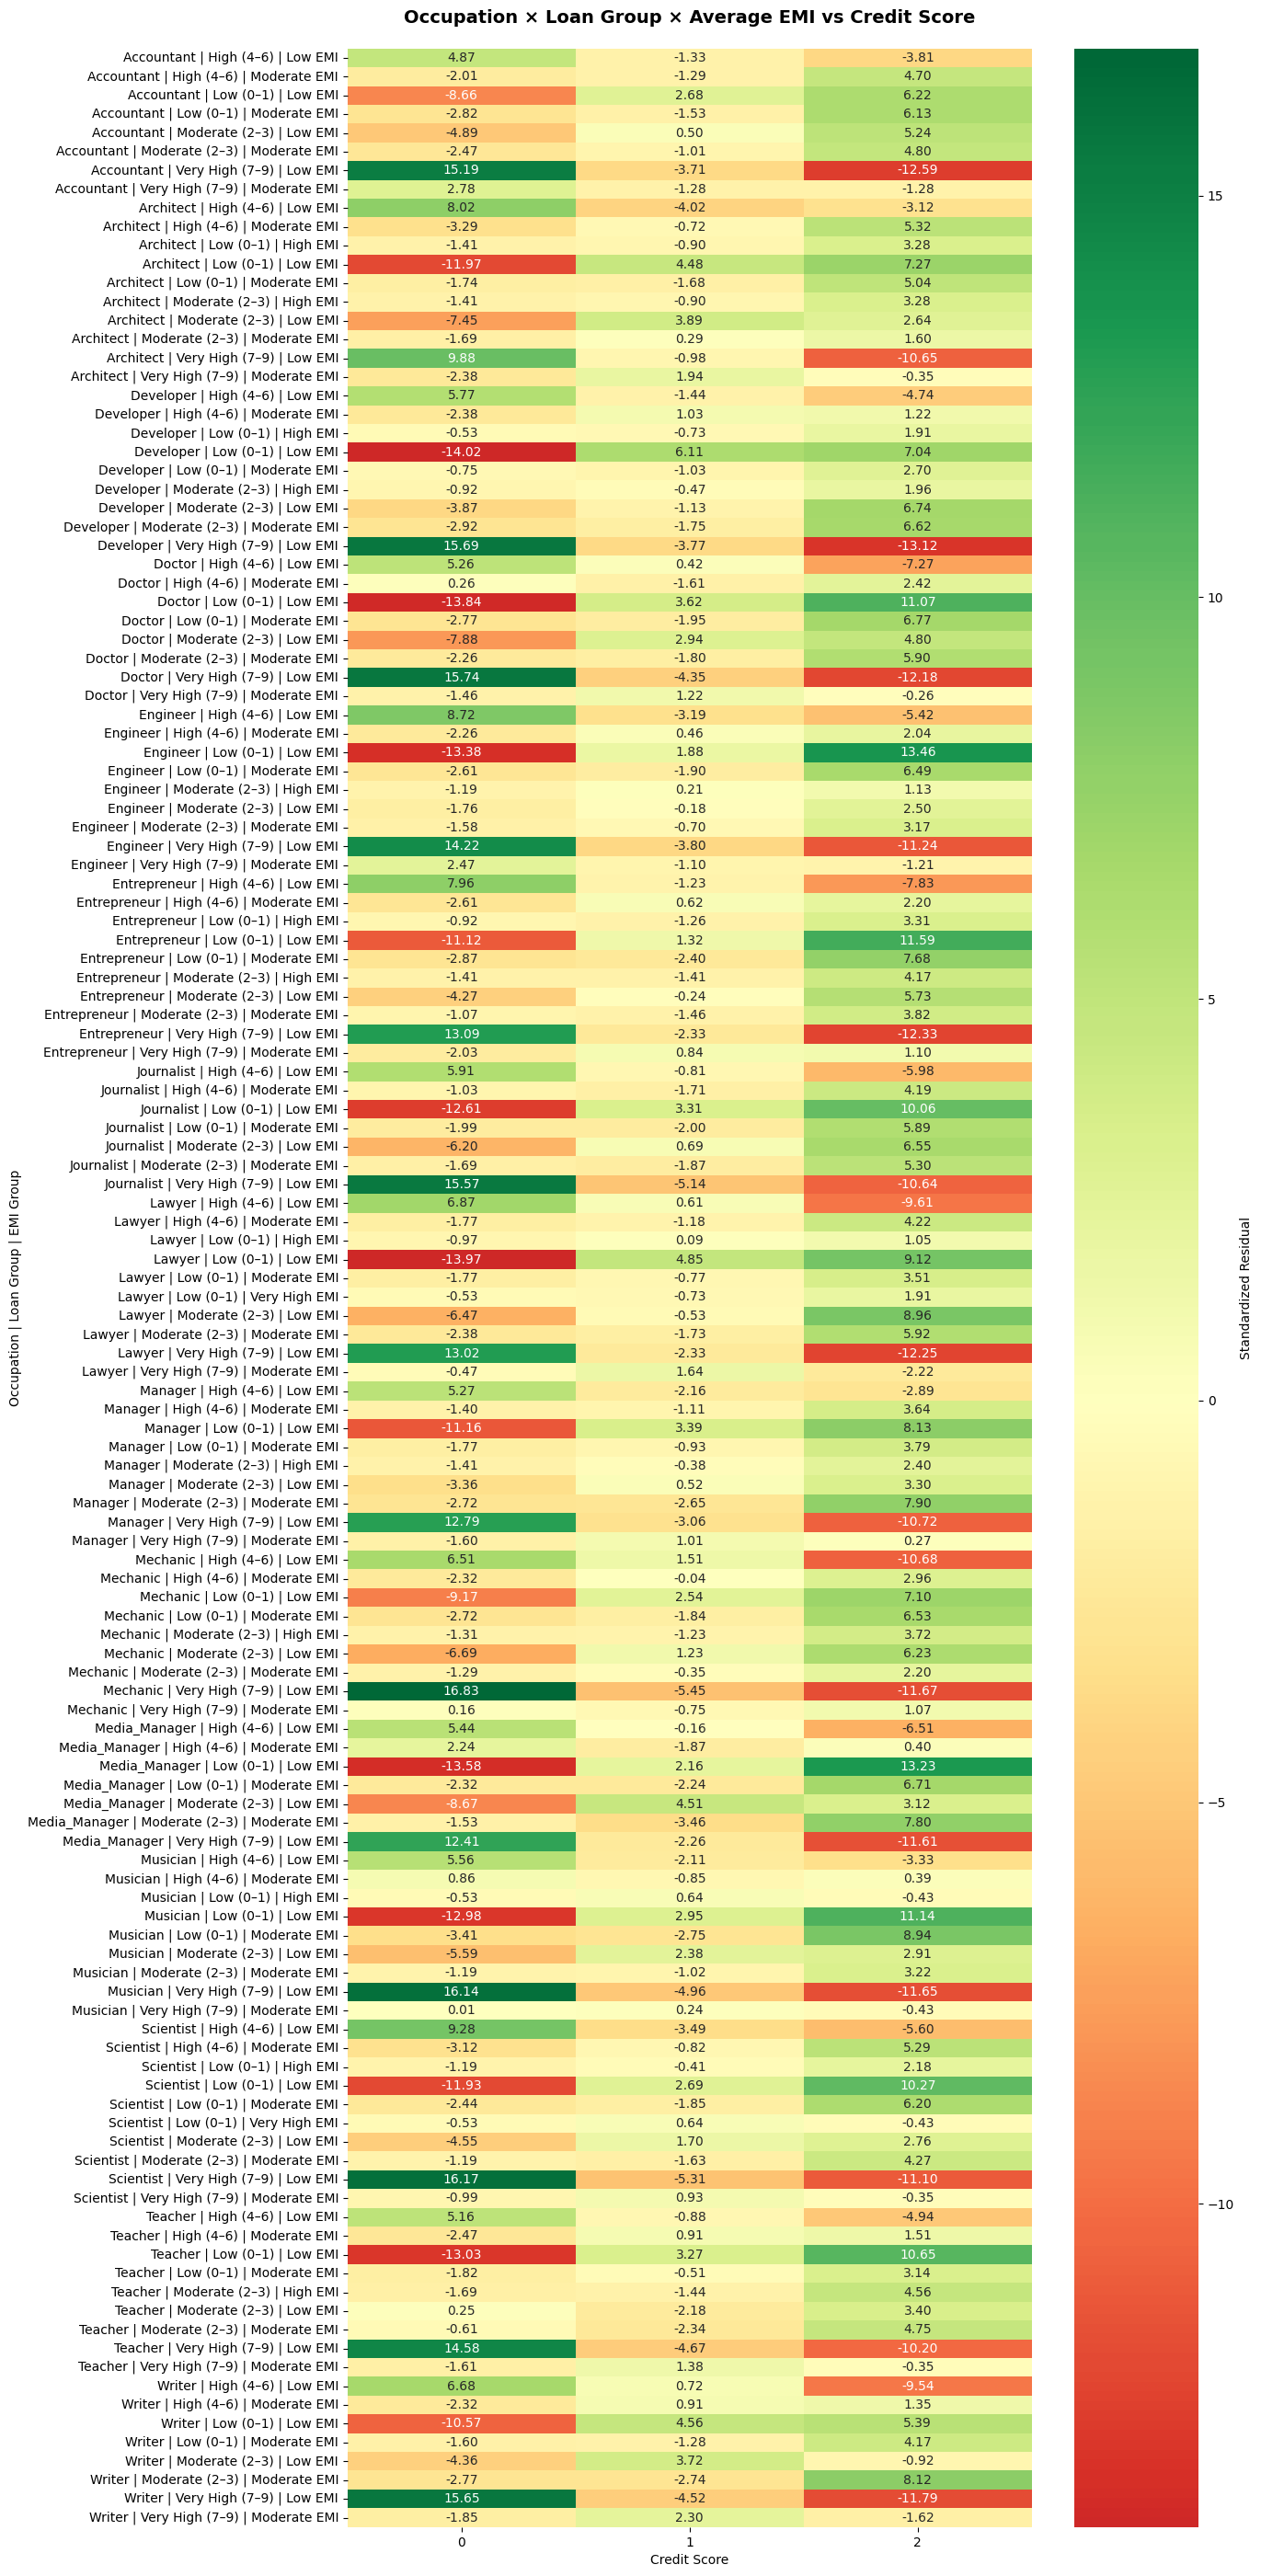

In [80]:
bins_loans = [-1, 1, 3, 6, 9]
labels_loans = ["Low (0–1)", "Moderate (2–3)", "High (4–6)", "Very High (7–9)"]
df_bq["loan_group"] = pd.cut(df_bq["num_of_loan"], bins=bins_loans, labels=labels_loans)

bins_emi = [0, 500, 1500, 2500, 3800]
labels_emi = ["Low EMI", "Moderate EMI", "High EMI", "Very High EMI"]
df_bq["emi_group"] = pd.cut(df_bq["total_emi_per_month"], bins=bins_emi, labels=labels_emi, include_lowest=True)

df_bq["occ_loan_emi_group"] = (
    df_bq["occupation"].astype(str) + " | " +
    df_bq["loan_group"].astype(str) + " | " +
    df_bq["emi_group"].astype(str)
)

contingency = pd.crosstab(df_bq["occ_loan_emi_group"], df_bq["credit_score"])

chi2, p, dof, expected = chi2_contingency(contingency)
residuals = (contingency - expected) / np.sqrt(expected)

print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")
print("→ Significant relationship" if p < 0.05 else "→ No significant relationship")

plt.figure(figsize=(12, 35))
sns.heatmap(residuals, cmap="RdYlGn", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "Standardized Residual"})
plt.title("Occupation × Loan Group × Average EMI vs Credit Score", weight="bold", fontsize=14, pad=20)
plt.xlabel("Credit Score")
plt.ylabel("Occupation | Loan Group | EMI Group")
plt.show()

**Answer**

The heatmap reveals that **occupation, number of loans, and average EMI jointly influence credit score performance**:

* **Writers, Teachers, and Musicians** with **many loans (≥7)** and **moderate-to-high EMI** show **strong positive residuals** for *low credit scores* → these groups face **the highest credit risk**, likely due to unstable income and high repayment pressure.
* **Engineers, Doctors, and Scientists** with **few loans (≤3)** and **low or moderate EMI** have **positive residuals** in *high credit score* columns → indicating **excellent repayment discipline**.
* **Middle-income professionals** (e.g., Managers, Lawyers, Developers) show balanced behavior — their credit score depends largely on EMI burden.

👉 **Summary:**
**High EMI + Many loans + Creative/unstable occupations = High credit risk**,
while **Low EMI + Few loans + Stable professions = Strong credit performance.**

#### How do **credit inquiries** and **changes in credit limit** together predict credit score variation?

payment_behaviour        High_spent_Large_value_payments  \
income_group credit_mix                                    
Low          Bad                                4.865947   
             Good                               6.482143   
             Standard                           5.738246   
Medium       Bad                               13.714520   
             Good                              11.958204   
             Standard                          12.280340   
High         Bad                               23.201856   
             Good                              28.370709   
             Standard                          25.934710   

payment_behaviour        High_spent_Medium_value_payments  \
income_group credit_mix                                     
Low          Bad                                 8.217270   
             Good                               11.767857   
             Standard                           10.050185   
Medium       Bad                                26.774017   
             Good                               24.806502   
             Standard                           24.581274   
High         Bad                                25.087007   
             Good                               20.902547   
             Standard                           23.116629   

payment_behaviour        High_spent_Small_value_payments  \
income_group credit_mix                                    
Low          Bad                               10.080084   
             Good                              11.071429   
             Standard                          10.565240   
Medium       Bad                               15.515830   
             Good                              14.734907   
             Standard                          15.142779   
High         Bad                               12.412993   
             Good                              11.004983   
             Standard                          11.077009   

payment_behaviour        Low_spent_Large_value_payments  \
income_group credit_mix                                   
Low          Bad                              11.290042   
             Good                             11.875000   
             Standard                         11.813259   
Medium       Bad                              11.626638   
             Good                             12.674149   
             Standard                         12.898133   
High         Bad                               9.773782   
             Good                              9.551495   
             Standard                         10.107422   

payment_behaviour        Low_spent_Medium_value_payments  \
income_group credit_mix                                    
Low          Bad                               18.036212   
             Good                              16.571429   
             Standard                          17.095880   
Medium       Bad                                9.729803   
             Good                              10.303793   
             Standard                           9.568918   
High         Bad                               15.516241   
             Good                              19.096069   
             Standard                          17.166574   

payment_behaviour        Low_spent_Small_value_payments  
income_group credit_mix                                  
Low          Bad                              47.510446  
             Good                             42.232143  
             Standard                         44.737190  
Medium       Bad                              22.639192  
             Good                             25.522446  
             Standard                         25.528556  
High         Bad                              14.008121  
             Good                             11.074197  
             Standard                         12.597656

Chi2: 23971.499951442376 p-value: 0.0
Chi2: 23971.5000 | dof: 44 | p-value: 0.000000


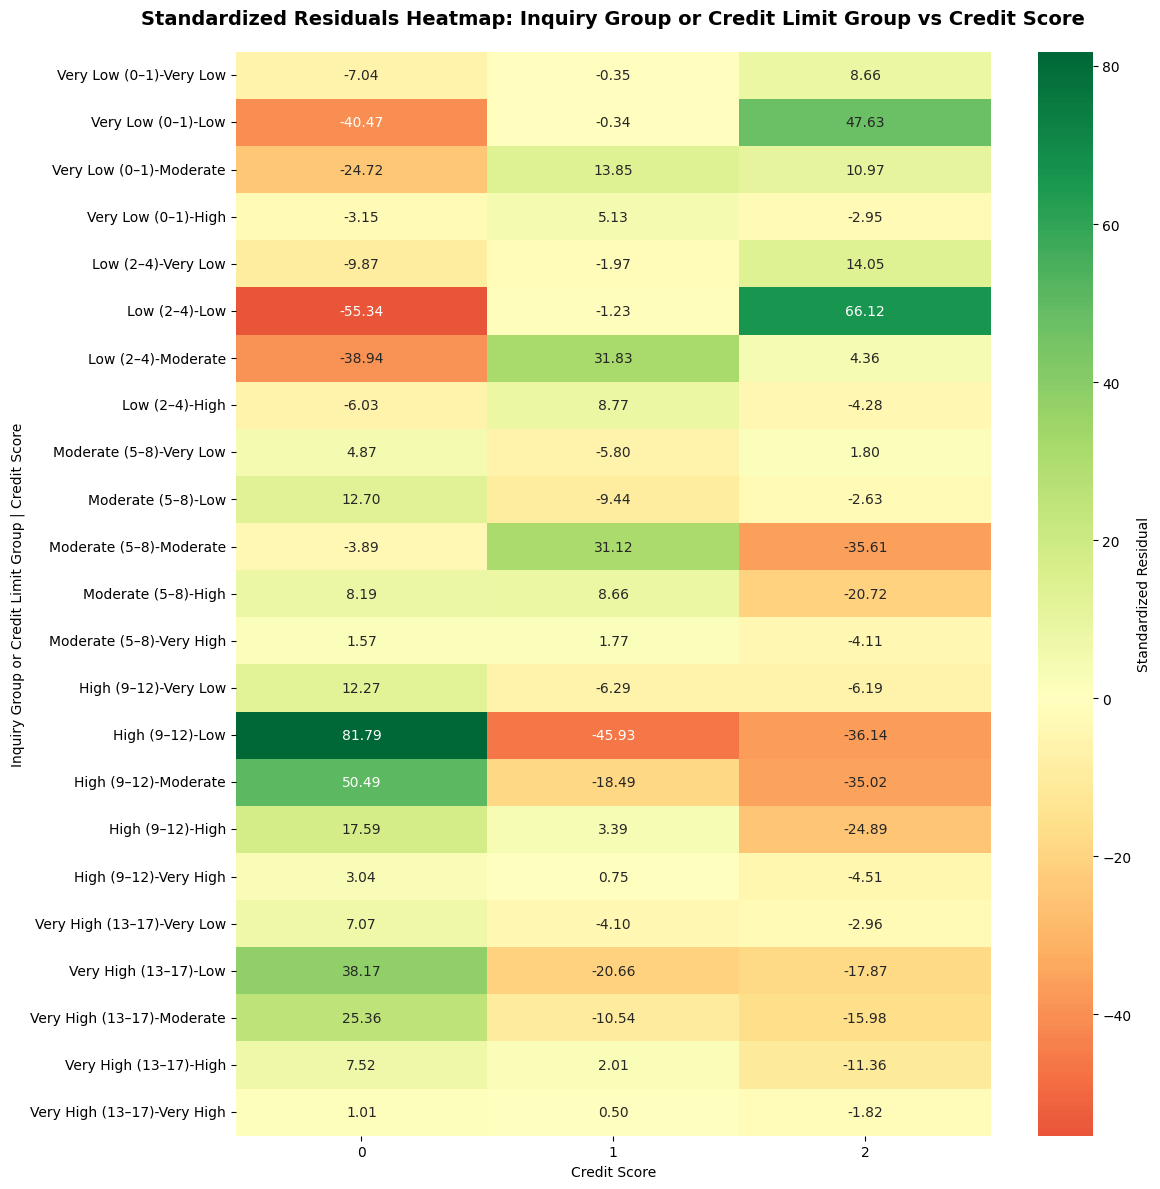

In [81]:
bins_inq = [-1, 1, 4, 8, 12, 17]
labels_inq = ["Very Low (0–1)", "Low (2–4)", "Moderate (5–8)", "High (9–12)", "Very High (13–17)"]
df_bq["inquiry_group"] = pd.cut(df_bq["num_credit_inquiries"], bins=bins_inq, labels=labels_inq)

bins_var2 = [-7, 0, 10, 20, 30, 37]
labels_var2 = ["Very Low", "Low", "Moderate", "High", "Very High"]
df_bq["credit_limit_group"] = pd.cut(df_bq["changed_credit_limit"], bins=bins_var2, labels=labels_var2, include_lowest=True)


df_bq_inquiry_group_credit_limit_group = pd.crosstab(
    [df_bq["inquiry_group"], df_bq["credit_limit_group"]],
    df_bq["credit_score"],
    normalize="index"
) * 100

display(df_bq_income_group_credit_mix)

contingency = pd.crosstab(
    [df_bq["inquiry_group"], df_bq["credit_limit_group"]],
    df_bq["credit_score"]
)
chi2, p, dof, ex = chi2_contingency(contingency)
print("Chi2:", chi2, "p-value:", p)

# 1) Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

print(f"Chi2: {chi2:.4f} | dof: {dof} | p-value: {p:.6f}")

# 2) Standardized residuals (adjusted)
#    r_ij = (O_ij - E_ij) / sqrt(E_ij * (1 - row_prob_i) * (1 - col_prob_j))
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# 3) Heatmap — display nicely the multiindex
plt.figure(figsize=(12,12))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Inquiry Group or Credit Limit Group vs Credit Score", weight="bold", fontsize=14, pad=20)
plt.ylabel("Inquiry Group or Credit Limit Group | Credit Score")
plt.xlabel("Credit Score")
plt.tight_layout()
plt.show()

**Answer**

The heatmap shows that **credit inquiries** and **credit limit changes** jointly predict credit score variation quite strongly:

* Customers with **high inquiry frequency (9–12)** and **low credit limits** have **very high positive residuals** for *low credit scores* (+80), indicating **the strongest link to poor credit performance**.
* **Low or moderate inquiry groups (≤8)** combined with **moderate-to-high credit limits** show **positive residuals for high credit scores**, suggesting **financial stability and lower risk**.
* Extremely high inquiries (13–17) still associate with lower scores, but the effect weakens slightly — likely because these cases are fewer.

👉 **Summary:**
**Frequent credit inquiries and low credit limits** are the **most predictive indicators of poor credit scores**, while **fewer inquiries and higher credit limits** are associated with **stronger credit health**.

#### How does the trio of **age**, **income**, and **payment_of_min_amount** explain credit score patterns?

credit_score                                                    0          1  \
age_group           income_group payment_of_min_amount                         
Teen (16-20)        Low          No                     14.587332  48.752399   
                                 Yes                    46.670613  50.725067   
                    Medium       No                     10.439560  47.032967   
                                 Yes                    41.557440  55.744025   
                    High         No                     13.369345  48.548278   
                                 Yes                    34.640523  60.511983   
Young Adult (21-30) Low          No                     12.169811  53.679245   
                                 Yes                    47.779051  49.840906   
                    Medium       No                     13.238834  47.713292   
                                 Yes                    41.197943  55.550025   
                    High         No                     15.107459  46.944796   
                                 Yes                    29.658060  65.177948   
Adult (31-40)       Low          No                     15.660463  49.659555   
                                 Yes                    46.631407  50.157411   
                    Medium       No                     11.974558  48.036504   
                                 Yes                    41.693051  55.090818   
                    High         No                     14.757440  46.127191   
                                 Yes                    25.284685  67.696956   
Middle-Aged (41-50) Low          No                     10.706450  52.391400   
                                 Yes                    44.729542  52.981969   
                    Medium       No                     13.651685  47.668539   
                                 Yes                    36.879433  59.605304   
                    High         No                     13.161236  47.058824   
                                 Yes                    25.026178  70.087260   
Senior (51-56)      Low          No                     12.706701  51.610096   
                                 Yes                     6.783370  85.776805   
                    Medium       No                     14.872042  47.947851   
                                 Yes                     5.307856  86.624204   
                    High         No                     11.491539  45.769382   
                                 Yes                     8.695652  79.773157   

credit_score                                                    2  
age_group           income_group payment_of_min_amount             
Teen (16-20)        Low          No                     36.660269  
                                 Yes                     2.604321  
                    Medium       No                     42.527473  
                                 Yes                     2.698535  
                    High         No                     38.082377  
                                 Yes                     4.847495  
Young Adult (21-30) Low          No                     34.150943  
                                 Yes                     2.380043  
                    Medium       No                     39.047874  
                                 Yes                     3.252033  
                    High         No                     37.947745  
                                 Yes                     5.163992  
Adult (31-40)       Low          No                     34.679982  
                                 Yes                     3.211182  
                    Medium       No                     39.988938  
                                 Yes                     3.216131  
                    High         No                     39.115369  
                                 Yes                     7.018359  
Middle-Aged (41-50) Low          No                     36.902150  
           

Chi2: 24009.92615435218 p-value: 0.0
Chi2: 24009.9262 | dof: 58 | p-value: 0.000000


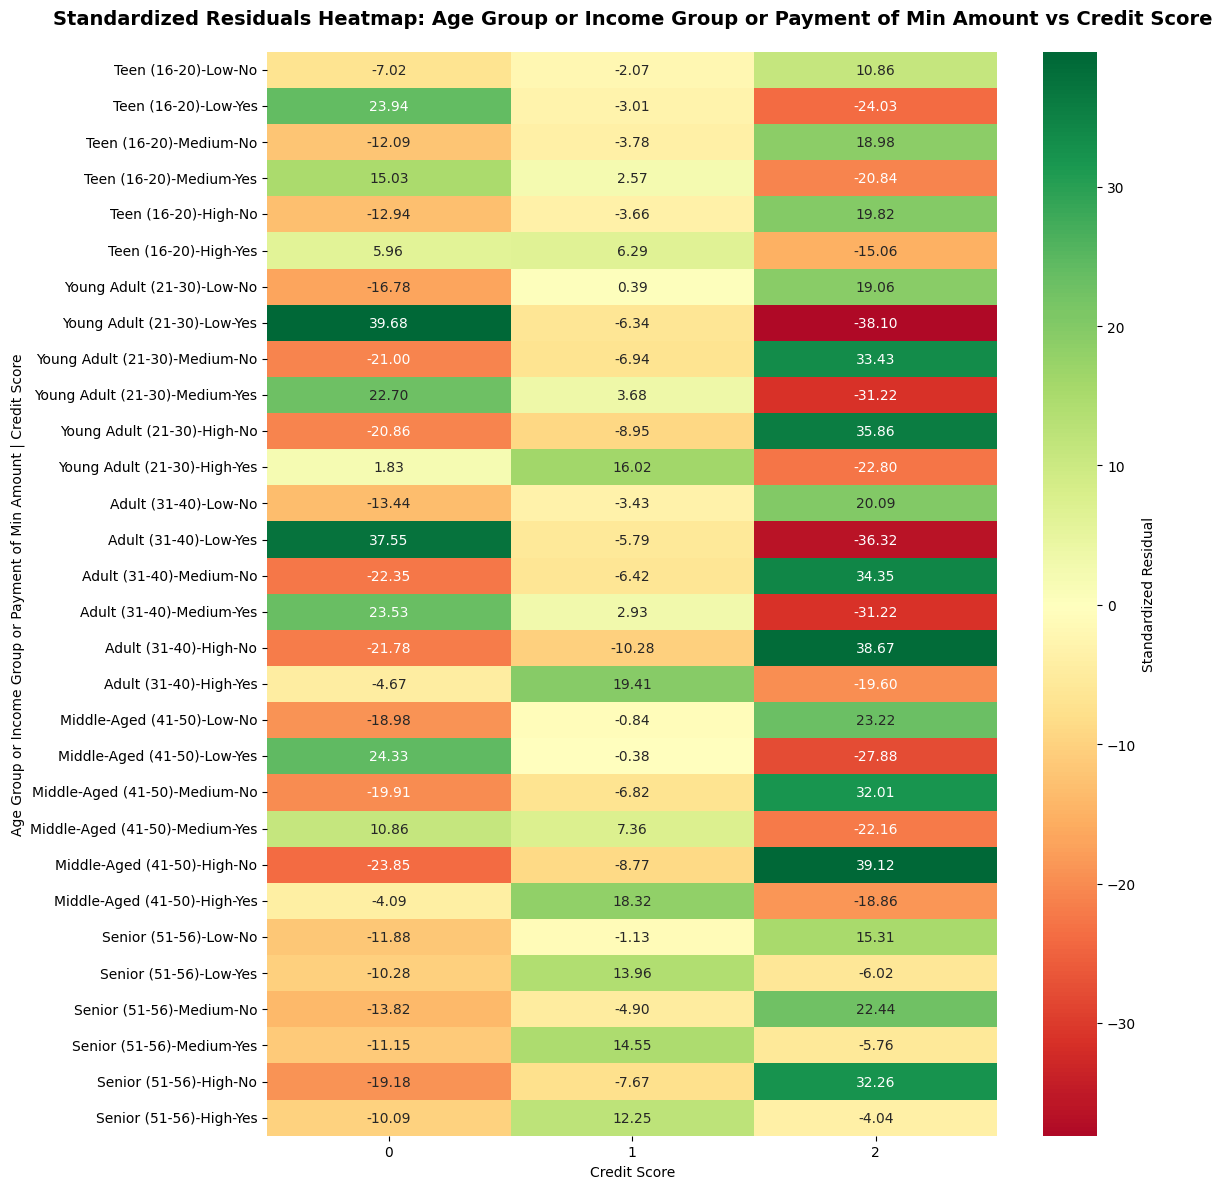

In [82]:
df_bq_age_income_payment_of_min_amount = pd.crosstab(
    [df_bq["age_group"], df_bq["income_group"], df_bq["payment_of_min_amount"]],
    df_bq["credit_score"],
    normalize="index"
) * 100

display(df_bq_age_income_payment_of_min_amount)

contingency= pd.crosstab(
    [df_bq["age_group"], df_bq["income_group"], df_bq["payment_of_min_amount"]],
    df_bq["credit_score"]
)
chi2, p, dof, ex = chi2_contingency(contingency)
print("Chi2:", chi2, "p-value:", p)

# 1) Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

print(f"Chi2: {chi2:.4f} | dof: {dof} | p-value: {p:.6f}")

# 2) Standardized residuals (adjusted)
#    r_ij = (O_ij - E_ij) / sqrt(E_ij * (1 - row_prob_i) * (1 - col_prob_j))
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# 3) Heatmap — display nicely the multiindex
plt.figure(figsize=(12,12))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Age Group or Income Group or Payment of Min Amount vs Credit Score", weight="bold", fontsize=14, pad=20)
plt.ylabel("Age Group or Income Group or Payment of Min Amount | Credit Score")
plt.xlabel("Credit Score")
plt.tight_layout()
plt.show()

**Answer**

The heatmap shows that **age**, **income**, and **payment of minimum amount** together explain clear patterns in credit score variation:

* **Young adults (21–30)** with **low income** who **don’t pay the minimum amount** have **strong positive residuals** for *low credit scores* (+39.7), meaning they’re **most likely to have poor credit performance**.
* Across all age groups, **consistent payment of the minimum amount (“Yes”)** is linked with **higher credit scores**, especially among **Adults (31–40)** and **Middle-Aged (41–50)** — reflecting good repayment discipline.
* **Older individuals (51–56)** generally maintain stable credit regardless of payment pattern, showing **lower sensitivity to missed payments**.

👉 **Summary:**
**Younger, low-income customers who skip minimum payments are at highest credit risk**,
while **middle-aged and older customers who pay regularly maintain stronger credit scores.**

#### Are customers with **multiple loans** and **high utilization ratio** more likely to have higher **delayed payments**?

credit_score                               0          1          2
loan_group      utilization_group                                 
Low (0–1)       Low                10.867901  59.804072  29.328027
                Medium             11.250683  59.639541  29.109776
                High               11.903366  58.086080  30.010555
Moderate (2–3)  Low                22.489960  55.582329  21.927711
                Medium             22.454944  54.905017  22.640039
                High               21.783696  54.191014  24.025290
High (4–6)      Low                37.175710  50.318350  12.505939
                Medium             35.503255  51.597396  12.899349
                High               35.015224  52.066116  12.918660
Very High (7–9) Low                52.856595  44.823620   2.319785
                Medium             53.434951  44.418205   2.146844
                High               53.906634  44.324324   1.769042

Chi2: 11137.657482313069 p-value: 0.0
Chi2: 11137.6575 | dof: 22 | p-value: 0.000000


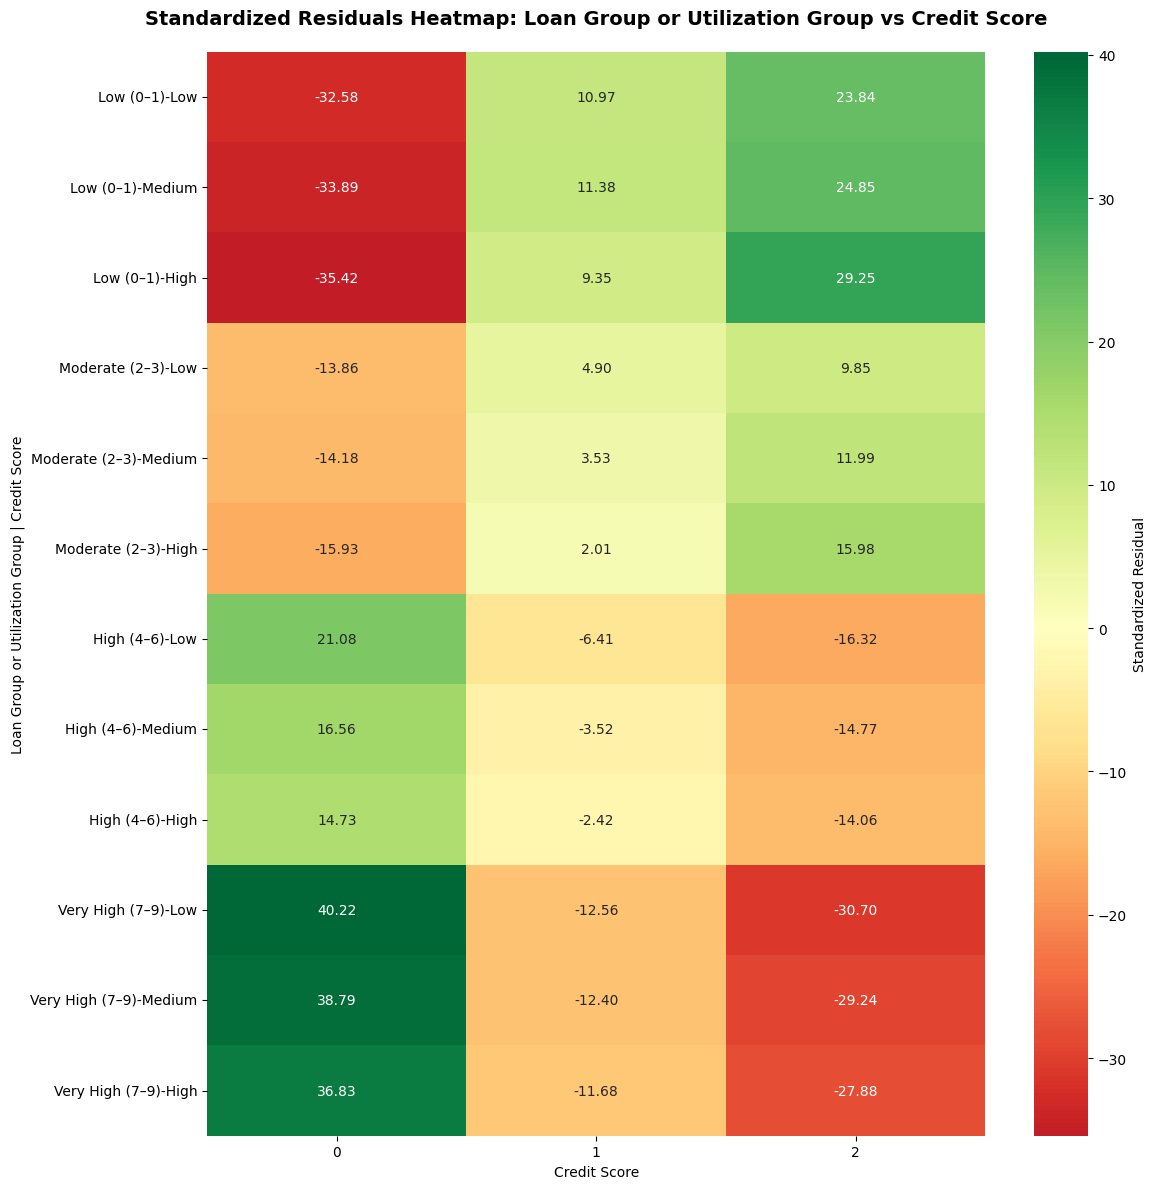

In [83]:
df_loan_utilization_high = pd.crosstab(
    [df_bq["loan_group"], df_bq["utilization_group"]],
    df_bq["credit_score"],
    normalize="index"
) * 100

display(df_loan_utilization_high)

contingency= pd.crosstab(
    [df_bq["loan_group"], df_bq["utilization_group"]],
    df_bq["credit_score"]
)
chi2, p, dof, ex = chi2_contingency(contingency)
print("Chi2:", chi2, "p-value:", p)

# 1) Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

print(f"Chi2: {chi2:.4f} | dof: {dof} | p-value: {p:.6f}")

# 2) Standardized residuals (adjusted)
#    r_ij = (O_ij - E_ij) / sqrt(E_ij * (1 - row_prob_i) * (1 - col_prob_j))
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# 3) Heatmap — display nicely the multiindex
plt.figure(figsize=(12,12))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Loan Group or Utilization Group vs Credit Score", weight="bold", fontsize=14, pad=20)
plt.ylabel("Loan Group or Utilization Group | Credit Score")
plt.xlabel("Credit Score")
plt.tight_layout()
plt.show()

**Answer**

The heatmap shows that **loan volume** and **credit utilization** interact strongly to influence credit score outcomes:

* Customers with **few loans (0–1)** have **very high residuals** for *high credit scores* (+24 to +29) — they are **least risky and maintain strong credit performance**, regardless of utilization level.
* **Moderate borrowers (2–3 loans)** still perform relatively well, but credit scores decline slightly as utilization increases.
* In contrast, **customers with many loans (7–9)** show **very strong positive residuals for low credit scores** (+36 to +40) and **negative for high scores**, confirming **over-leverage and repayment strain**.

👉 **Summary:**
**High loan count combined with any utilization level significantly increases credit risk**,
while **fewer loans consistently associate with higher credit scores and financial stability.**

#### How do **monthly balance**, **investment habits**, and **credit score** interact to reflect overall financial health?

credit_score                             0          1          2
credit_mix monthly_salary_group                                 
Bad        Low (≤3k)             59.528329  39.004089   1.467582
           Lower-Middle (3–6k)   60.158730  38.672439   1.168831
           Upper-Middle (6–9k)   62.576313  35.714286   1.709402
Good       Low (≤3k)             15.457261  34.499374  50.043365
           Lower-Middle (3–6k)   16.472458  34.189619  49.337924
           Upper-Middle (6–9k)   15.429431  34.241684  50.328886
           High (9–12k)          16.805289  37.257411  45.937300
           Very High (>12k)      16.167419  38.941321  44.891260
Standard   Low (≤3k)             24.158204  70.701942   5.139854
           Lower-Middle (3–6k)   25.006569  70.578961   4.414470
           Upper-Middle (6–9k)   10.685600  82.243259   7.071142
           High (9–12k)           7.884097  79.548518  12.567385
           Very High (>12k)      12.133891  76.987448  10.878661

Chi2: 39989.397030111155 p-value: 0.0
Chi2: 39989.3970 | dof: 24 | p-value: 0.000000


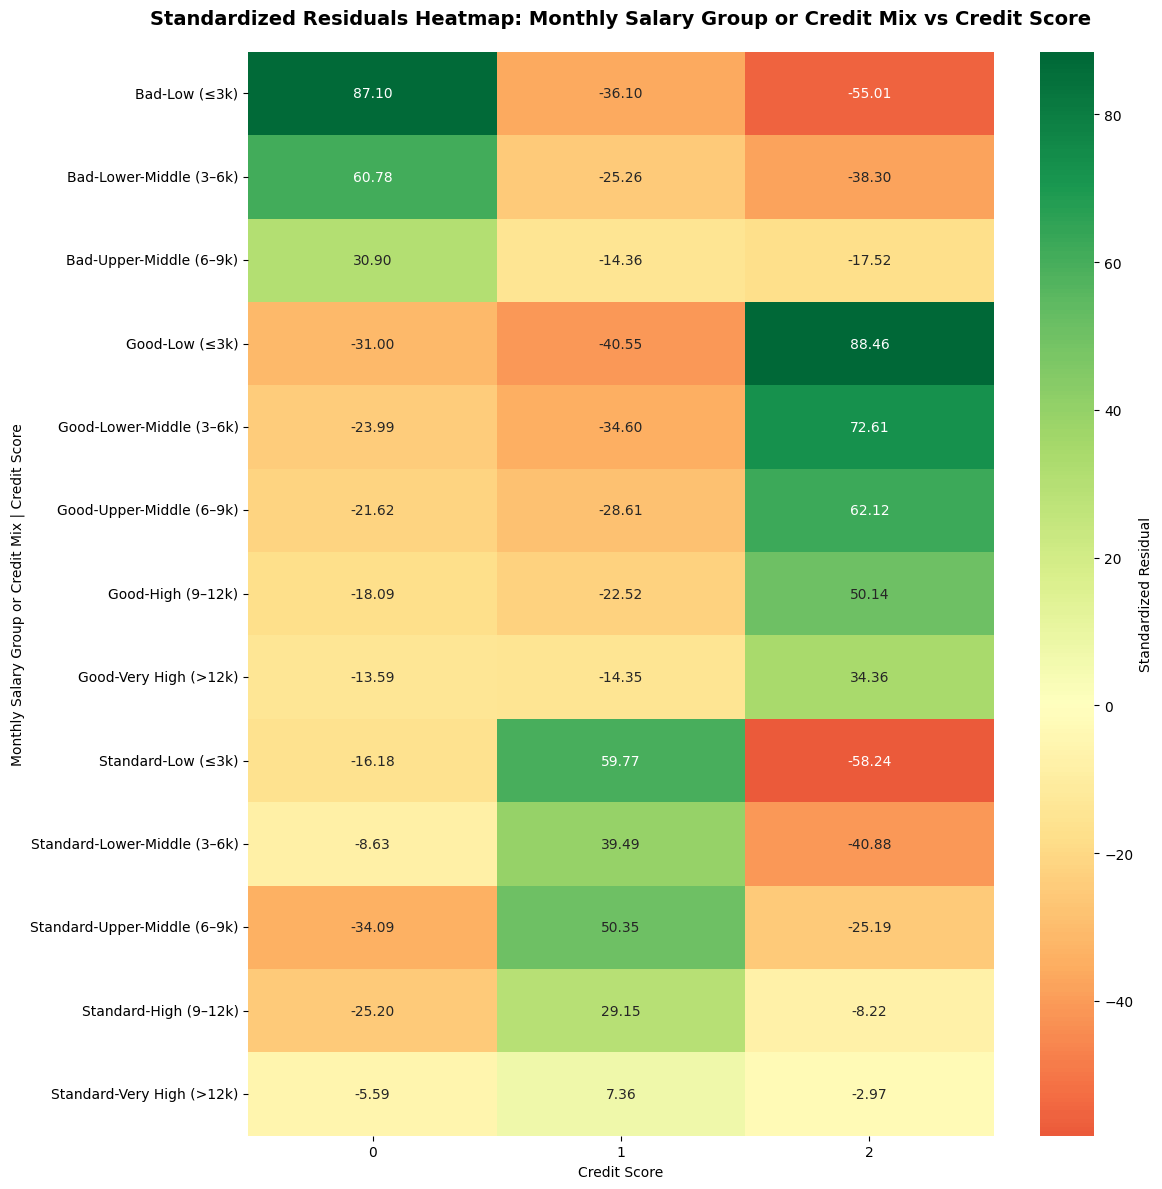

In [84]:
bins_salary = [300, 3000, 6000, 9000, 12000, 15200]
labels_salary = ["Low (≤3k)", "Lower-Middle (3–6k)", "Upper-Middle (6–9k)", "High (9–12k)", "Very High (>12k)"]
df_bq["monthly_salary_group"] = pd.cut(df_bq["monthly_inhand_salary"], bins=bins_salary, labels=labels_salary, include_lowest=True)

df_monthly_salary_group_credit_mix = pd.crosstab(
    [df_bq["credit_mix"], df_bq["monthly_salary_group"]],
    df_bq["credit_score"],
    normalize="index"
) * 100

display(df_monthly_salary_group_credit_mix)

contingency= pd.crosstab(
    [df_bq["credit_mix"], df_bq["monthly_salary_group"]],
    df_bq["credit_score"]
)
chi2, p, dof, ex = chi2_contingency(contingency)
print("Chi2:", chi2, "p-value:", p)

# 1) Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

print(f"Chi2: {chi2:.4f} | dof: {dof} | p-value: {p:.6f}")

# 2) Standardized residuals (adjusted)
#    r_ij = (O_ij - E_ij) / sqrt(E_ij * (1 - row_prob_i) * (1 - col_prob_j))
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# 3) Heatmap — display nicely the multiindex
plt.figure(figsize=(12,12))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Monthly Salary Group or Credit Mix vs Credit Score", weight="bold", fontsize=14, pad=20)
plt.ylabel("Monthly Salary Group or Credit Mix | Credit Score")
plt.xlabel("Credit Score")
plt.tight_layout()
plt.show()

**Answer**

The heatmap shows a **strong interaction between monthly salary, credit mix, and credit score**, reflecting different levels of financial health:

* Customers with **low salary (≤3k)** and **bad credit mix** have **very high residuals for low credit scores (+87)** — indicating **poor financial health** and difficulty managing debt.
* In contrast, **high-salary customers with good credit mix** show **strong positive residuals for high credit scores (+50 to +88)**, representing **excellent creditworthiness and disciplined investment habits**.
* **Standard credit mix** groups display mixed performance: moderate incomes (3–9k) align with medium credit scores, suggesting **average financial stability**.

👉 **Summary:**
**Low income + bad credit mix = weak financial health**,
while **high income + good credit mix = strong overall financial standing.**

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


## Extract features

In [85]:
df_pre = df.copy()
# Function to extract and clean loan types from a string
def extract_loans(text):
    clean_text = str(text).replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    return [x.strip() for x in clean_text.split(",") if x.strip()]

# Create a list of all unique loan types
unique_loans = set()
for entry in df_pre["type_of_loan"].dropna():
    unique_loans.update(extract_loans(entry))
unique_loans = sorted(unique_loans)

# Create binary columns for each loan type (One-Hot Encoding)
for loan in unique_loans:
    df_pre[loan.replace(" ", "_")] = df_pre["type_of_loan"].apply(lambda x: 1 if loan in str(x) else 0)

# View results
df_pre.head()

,month,age,occupation,annual_income,monthly_inhand_salary,credit_history_age,total_emi_per_month,num_bank_accounts,num_credit_card,interest_rate,num_of_loan,type_of_loan,delay_from_due_date,num_of_delayed_payment,changed_credit_limit,num_credit_inquiries,credit_mix,outstanding_debt,credit_utilization_ratio,payment_of_min_amount,amount_invested_monthly,payment_behaviour,monthly_balance,credit_score,Auto_Loan,Credit-Builder_Loan,Debt_Consolidation_Loan,Home_Equity_Loan,Mortgage_Loan,No_Loan,Not_Specified,Payday_Loan,Personal_Loan,Student_Loan
0,January,23,Scientist,19114.12,1824.8434,89,49.574947,3,4,3,4,"['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']",3,7,11.27,4,Good,809.98,26.822620,No,80.415300,High_spent_Small_value_payments,312.49408,2,1,1,0,1,0,0,0,0,1,0
1,February,23,Scientist,19114.12,1824.8434,93,49.574947,3,4,3,4,"['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']",-1,7,11.27,4,Good,809.98,31.944960,No,118.280220,Low_spent_Large_value_payments,284.62915,2,1,1,0,1,0,0,0,0,1,0
2,March,23,Scientist,19114.12,1824.8434,91,49.574947,3,4,3,4,"['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']",3,7,11.27,4,Good,809.98,28.609352,No,81.699524,Low_spent_Medium_value_payments,331.20987,2,1,1,0,1,0,0,0,0,1,0
3,April,23,Scientist,19114.12,1824.8434,92,49.574947,3,4,3,4,"['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']",5,4,6.27,4,Good,809.98,31.377861,No,199.458070,Low_spent_Small_value_payments,223.45131,2,1,1,0,1,0,0,0,0,1,0
4,May,23,Scientist,19114.12,1824.8434,93,49.574947,3,4,3,4,"['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']",6,4,11.27,4,Good,809.98,24.797346,No,41.420155,High_spent_Medium_value_payments,341.48923,2,1,1,0,1,0,0,0,0,1,0


In [86]:
# Replace space to under score.
df_pre.columns = df_pre.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")
cat_features = ["occupation", "credit_mix", "payment_of_min_amount", "payment_behaviour", "month", "Auto_Loan", "Credit_Builder_Loan", 
                "Debt_Consolidation_Loan", "Home_Equity_Loan", "Mortgage_Loan", "No_Loan", "Not_Specified", "Payday_Loan", "Personal_Loan", 
                "Student_Loan"]

new_cat_features = ["Auto_Loan", "Credit_Builder_Loan", "Debt_Consolidation_Loan", "Home_Equity_Loan", "Mortgage_Loan",
                    "No_Loan", "Not_Specified", "Payday_Loan", "Personal_Loan", "Student_Loan"]

print("\nData describe:")
def convert_cat(features, df = df_pre):
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")
convert_cat(cat_features)

# Display information about the DataFrames
print("Data Info:")
df_pre.info()


Data describe:
Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96696 entries, 0 to 96695
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   month                     96696 non-null  category
 1   age                       96696 non-null  int64   
 2   occupation                96696 non-null  category
 3   annual_income             96696 non-null  float64 
 4   monthly_inhand_salary     96696 non-null  float64 
 5   credit_history_age        96696 non-null  int64   
 6   total_emi_per_month       96696 non-null  float64 
 7   num_bank_accounts         96696 non-null  int64   
 8   num_credit_card           96696 non-null  int64   
 9   interest_rate             96696 non-null  int64   
 10  num_of_loan               96696 non-null  int64   
 11  type_of_loan              96696 non-null  category
 12  delay_from_due_date       96696 non-null  int64   
 13  num_of_delayed_paym

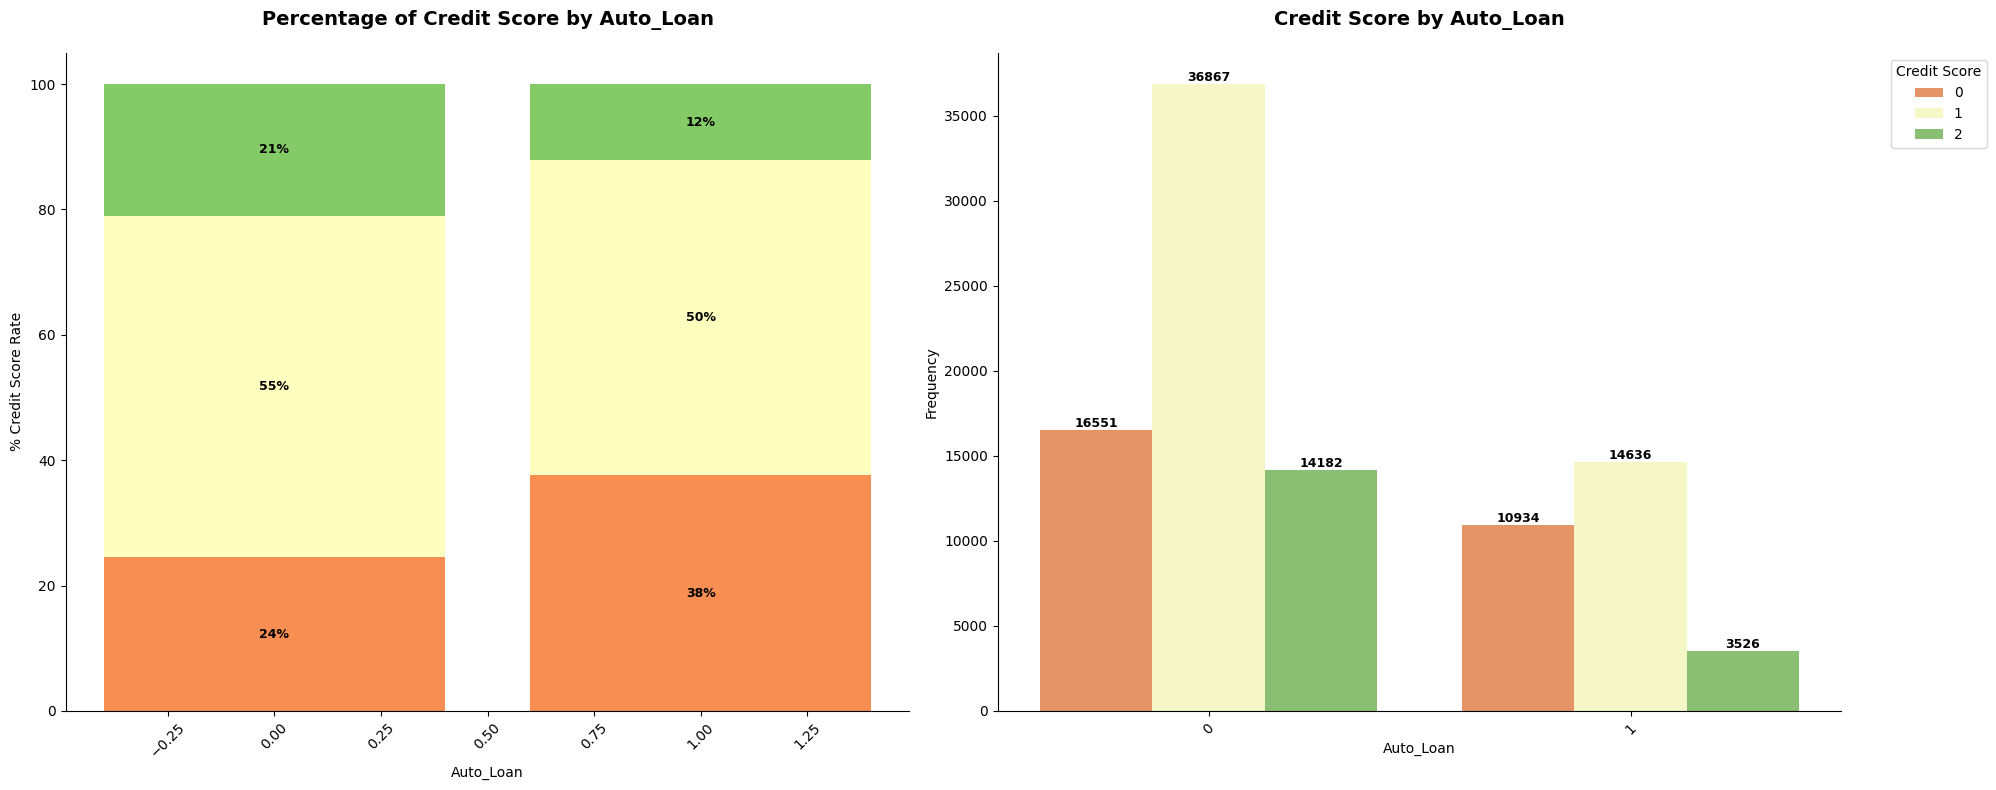


🔍 Chi-Square Test of Independence: 'Auto_Loan' vs. 'credit_score'
Chi-squared statistic: 2167.760
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Auto_Loan' and 'credit_score'.

📈 Standardized Residuals:
credit_score      0     1      2
Auto_Loan                       
0            -19.22  4.54  16.20
1             29.29 -6.92 -24.69


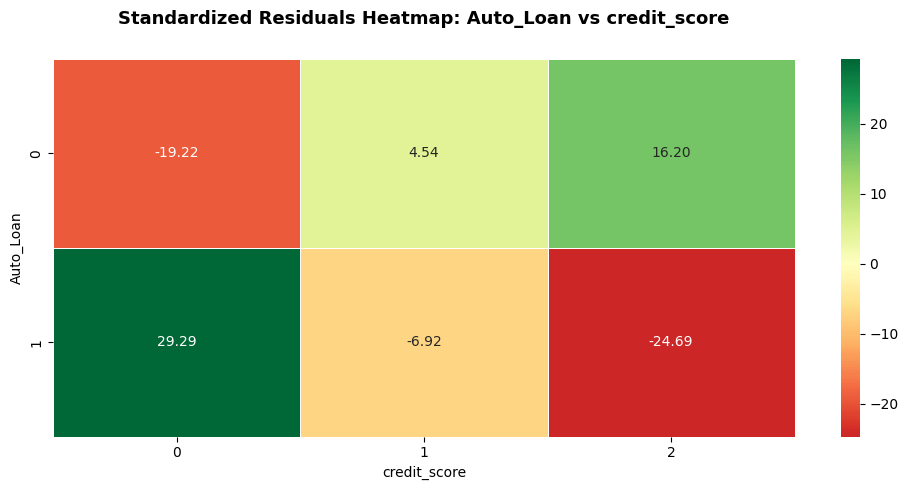

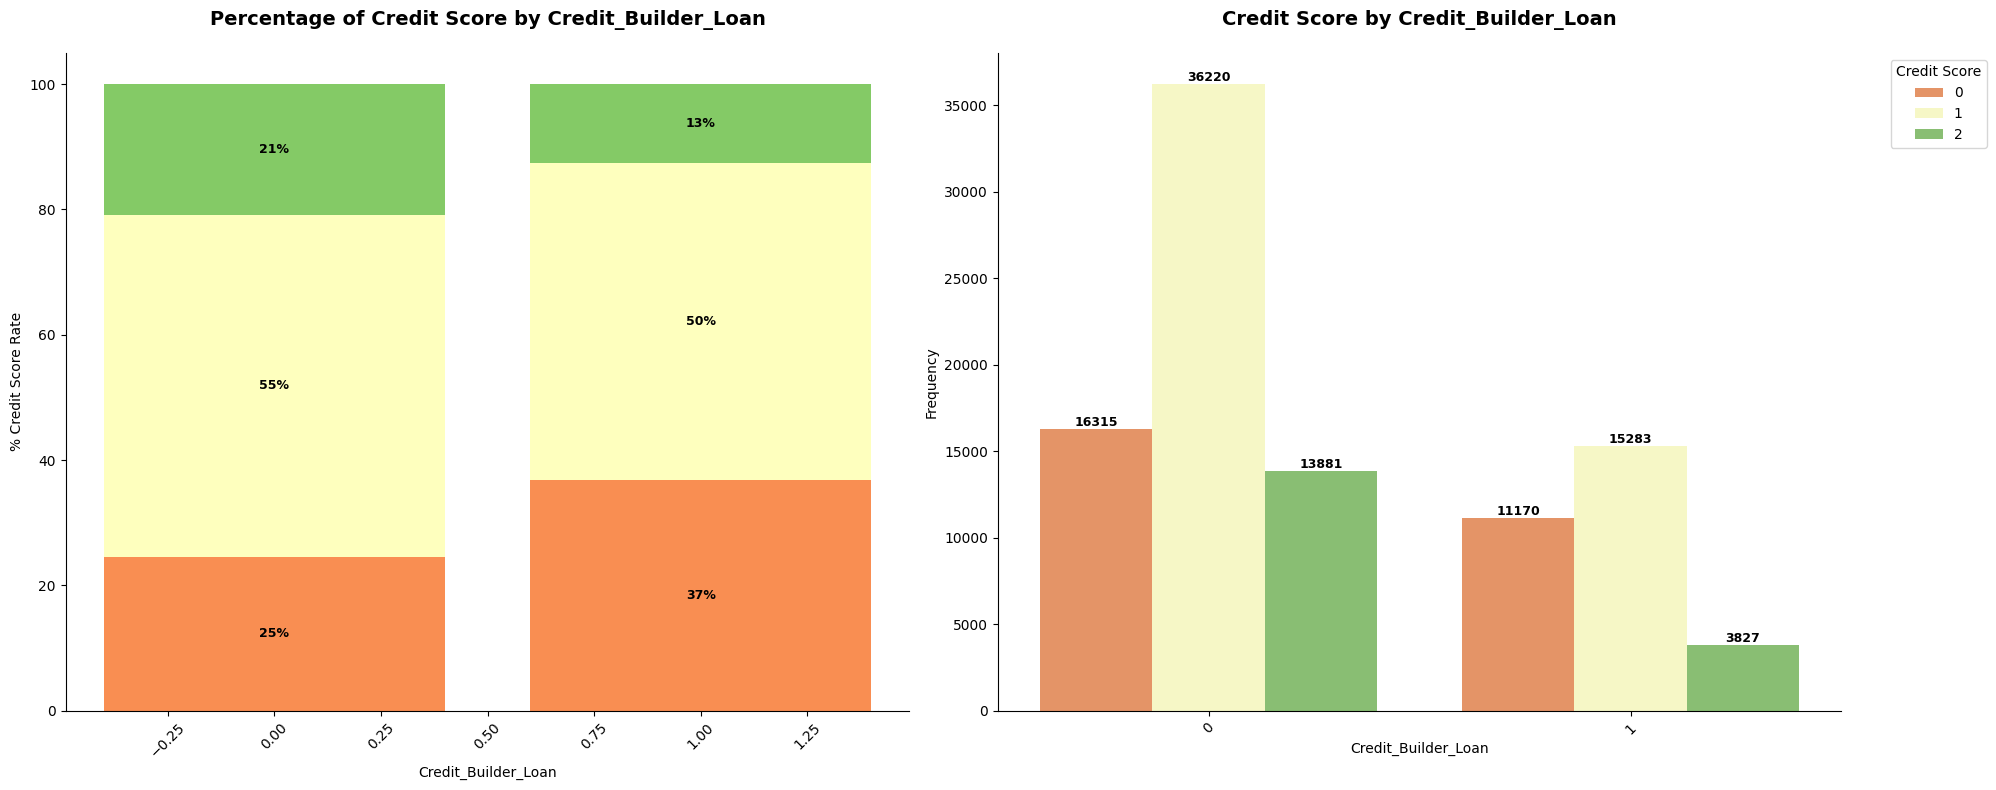


🔍 Chi-Square Test of Independence: 'Credit_Builder_Loan' vs. 'credit_score'
Chi-squared statistic: 1950.908
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Credit_Builder_Loan' and 'credit_score'.

📈 Standardized Residuals:
credit_score             0     1      2
Credit_Builder_Loan                    
0                   -18.66  4.49  15.58
1                    27.63 -6.65 -23.07


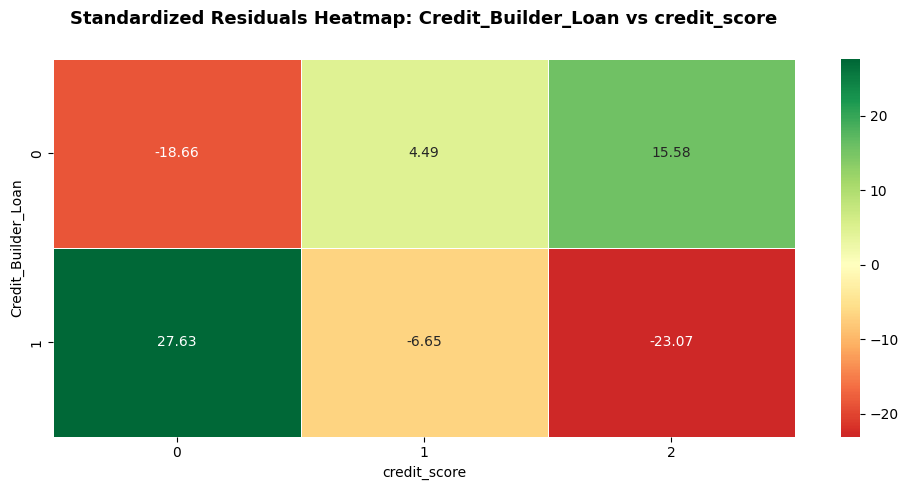

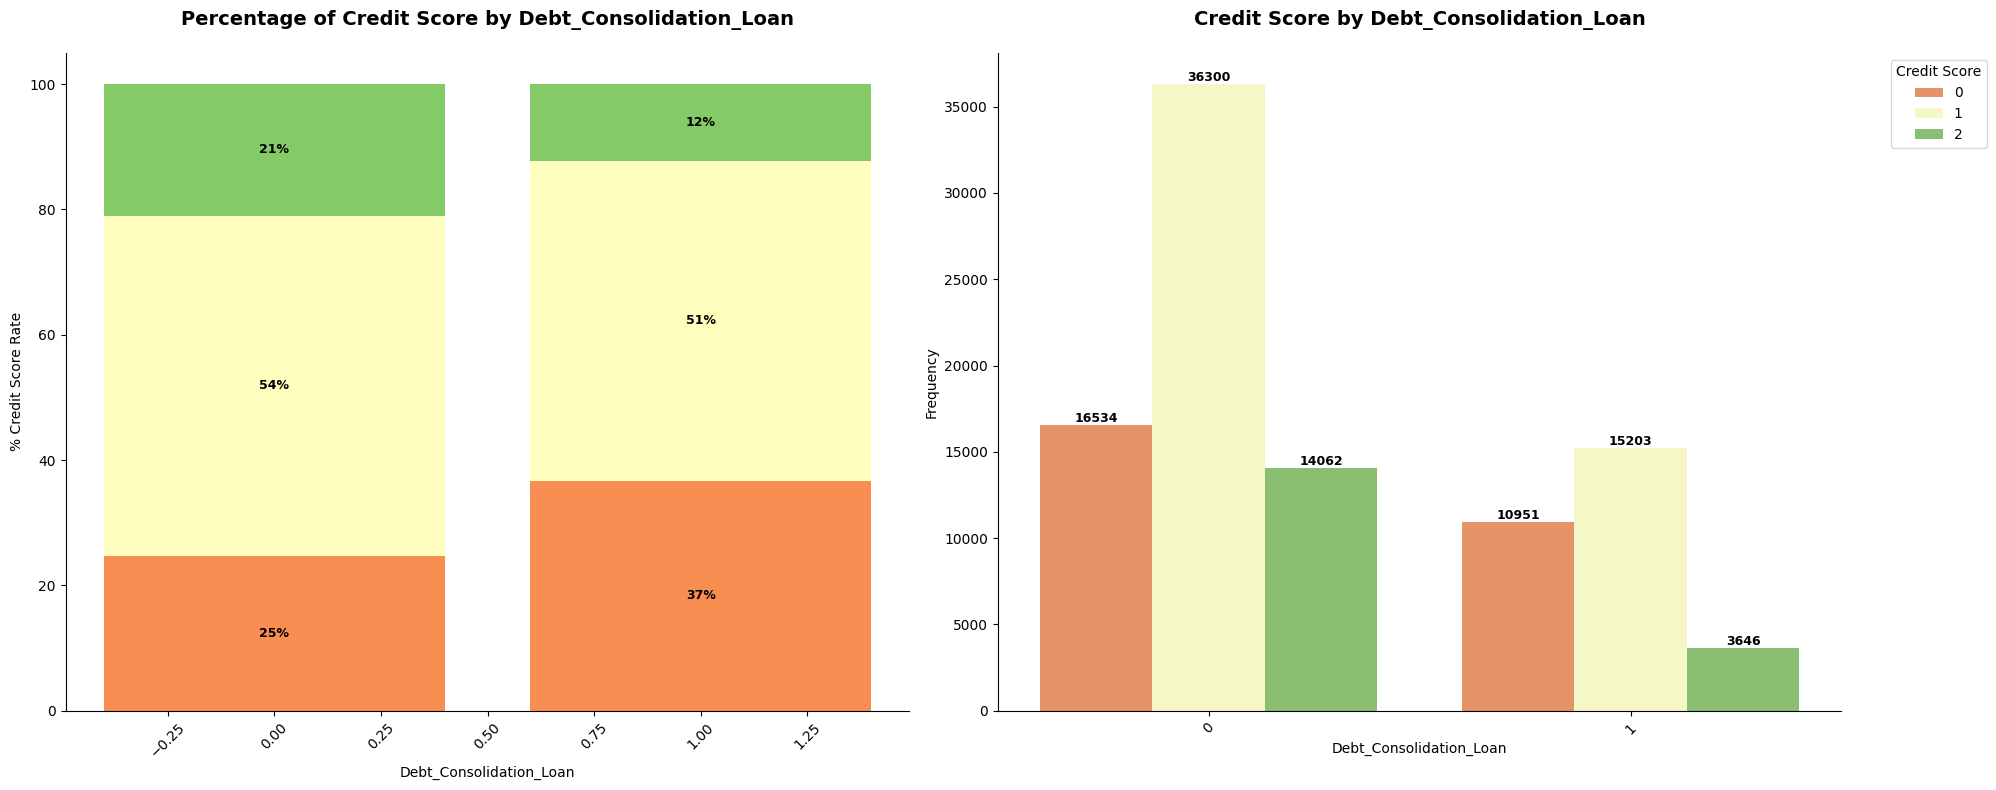


🔍 Chi-Square Test of Independence: 'Debt_Consolidation_Loan' vs. 'credit_score'
Chi-squared statistic: 1959.852
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Debt_Consolidation_Loan' and 'credit_score'.

📈 Standardized Residuals:
credit_score                 0     1      2
Debt_Consolidation_Loan                    
0                       -17.99  3.55  16.36
1                        26.95 -5.31 -24.52


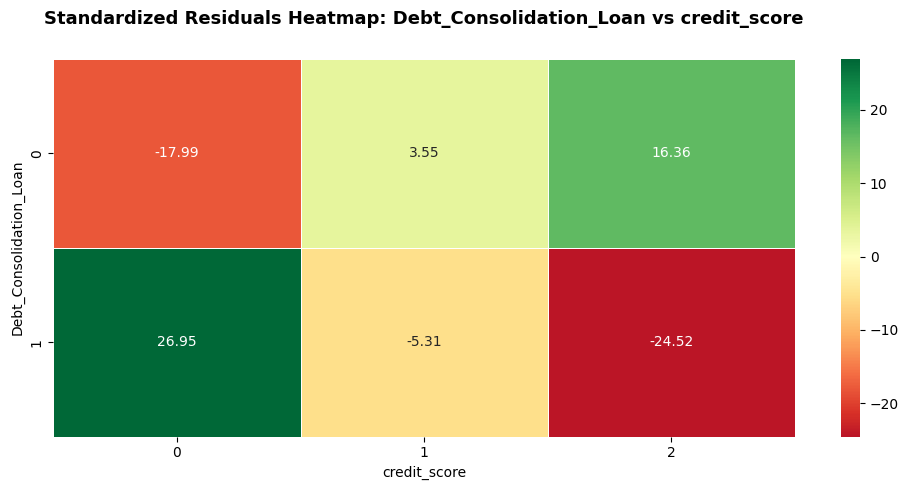

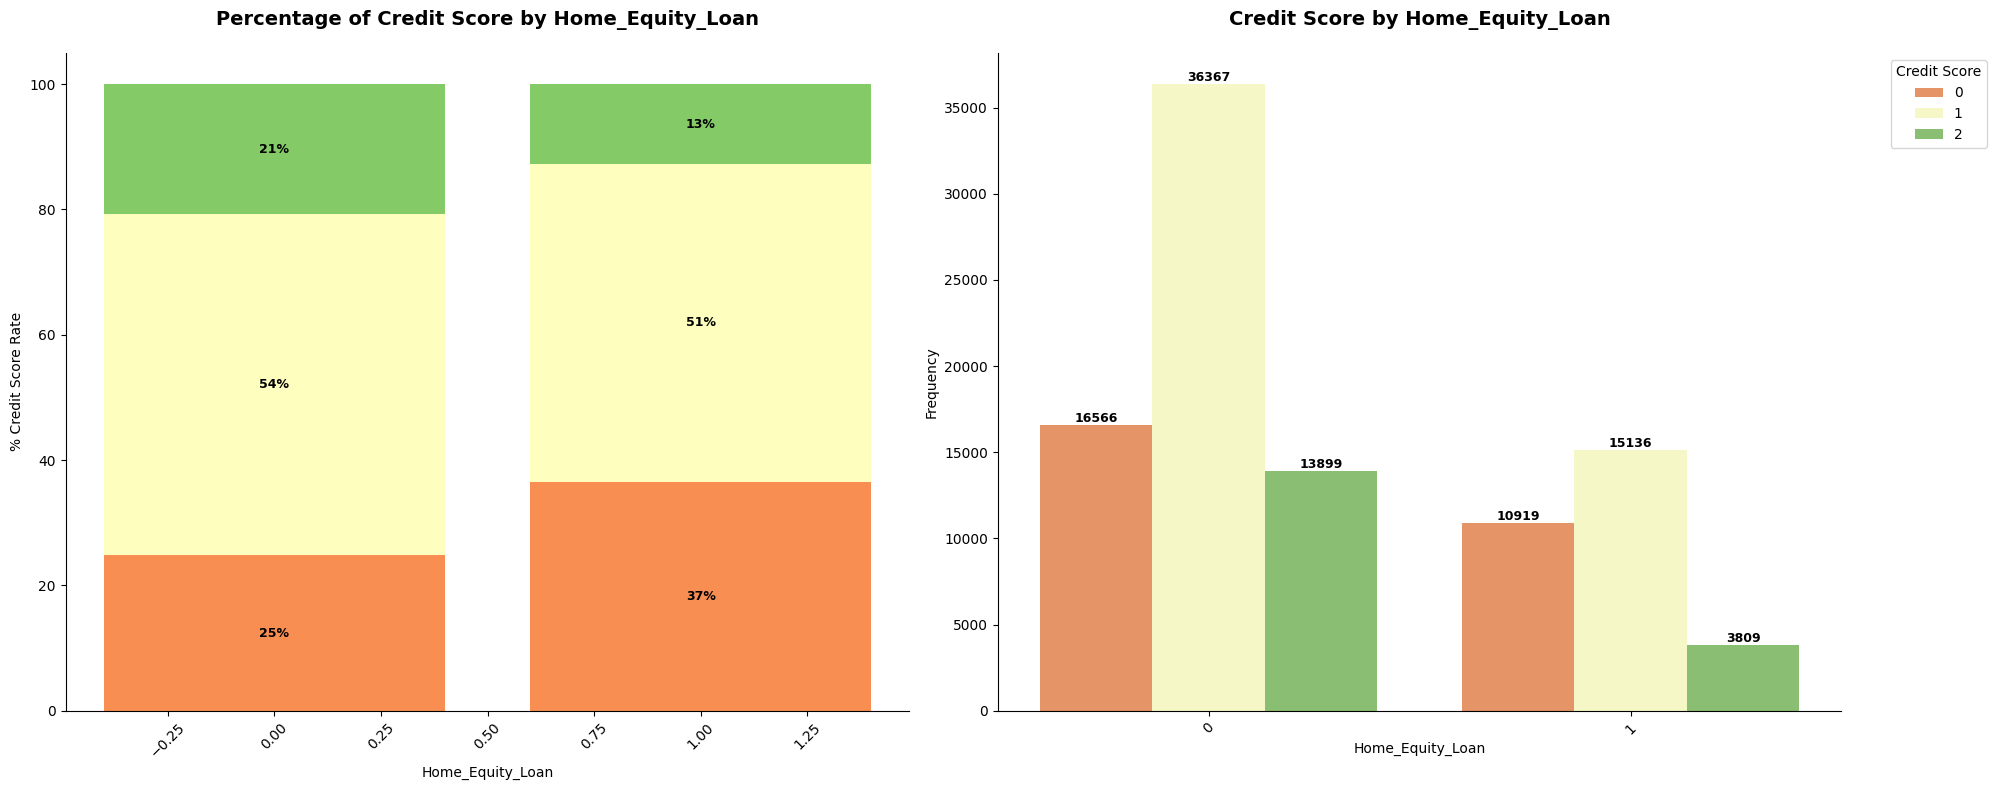


🔍 Chi-Square Test of Independence: 'Home_Equity_Loan' vs. 'credit_score'
Chi-squared statistic: 1789.821
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Home_Equity_Loan' and 'credit_score'.

📈 Standardized Residuals:
credit_score          0     1      2
Home_Equity_Loan                    
0                -17.63  4.08  15.01
1                 26.38 -6.11 -22.45


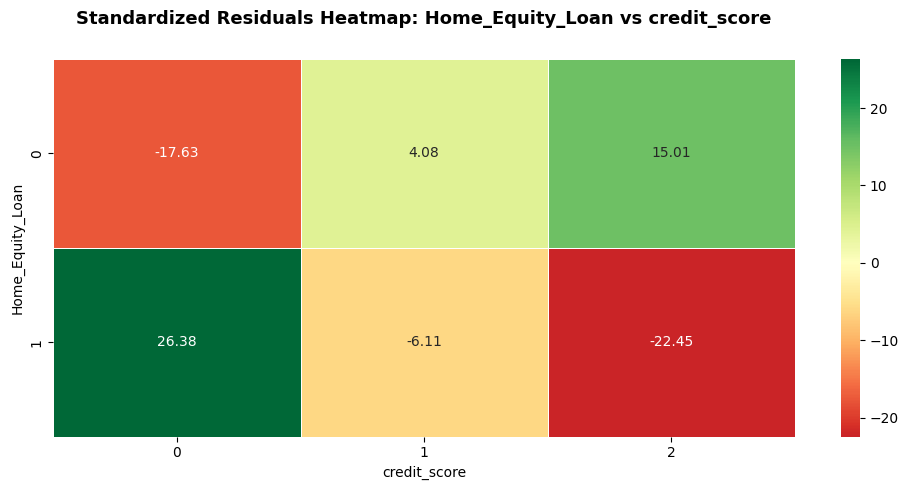

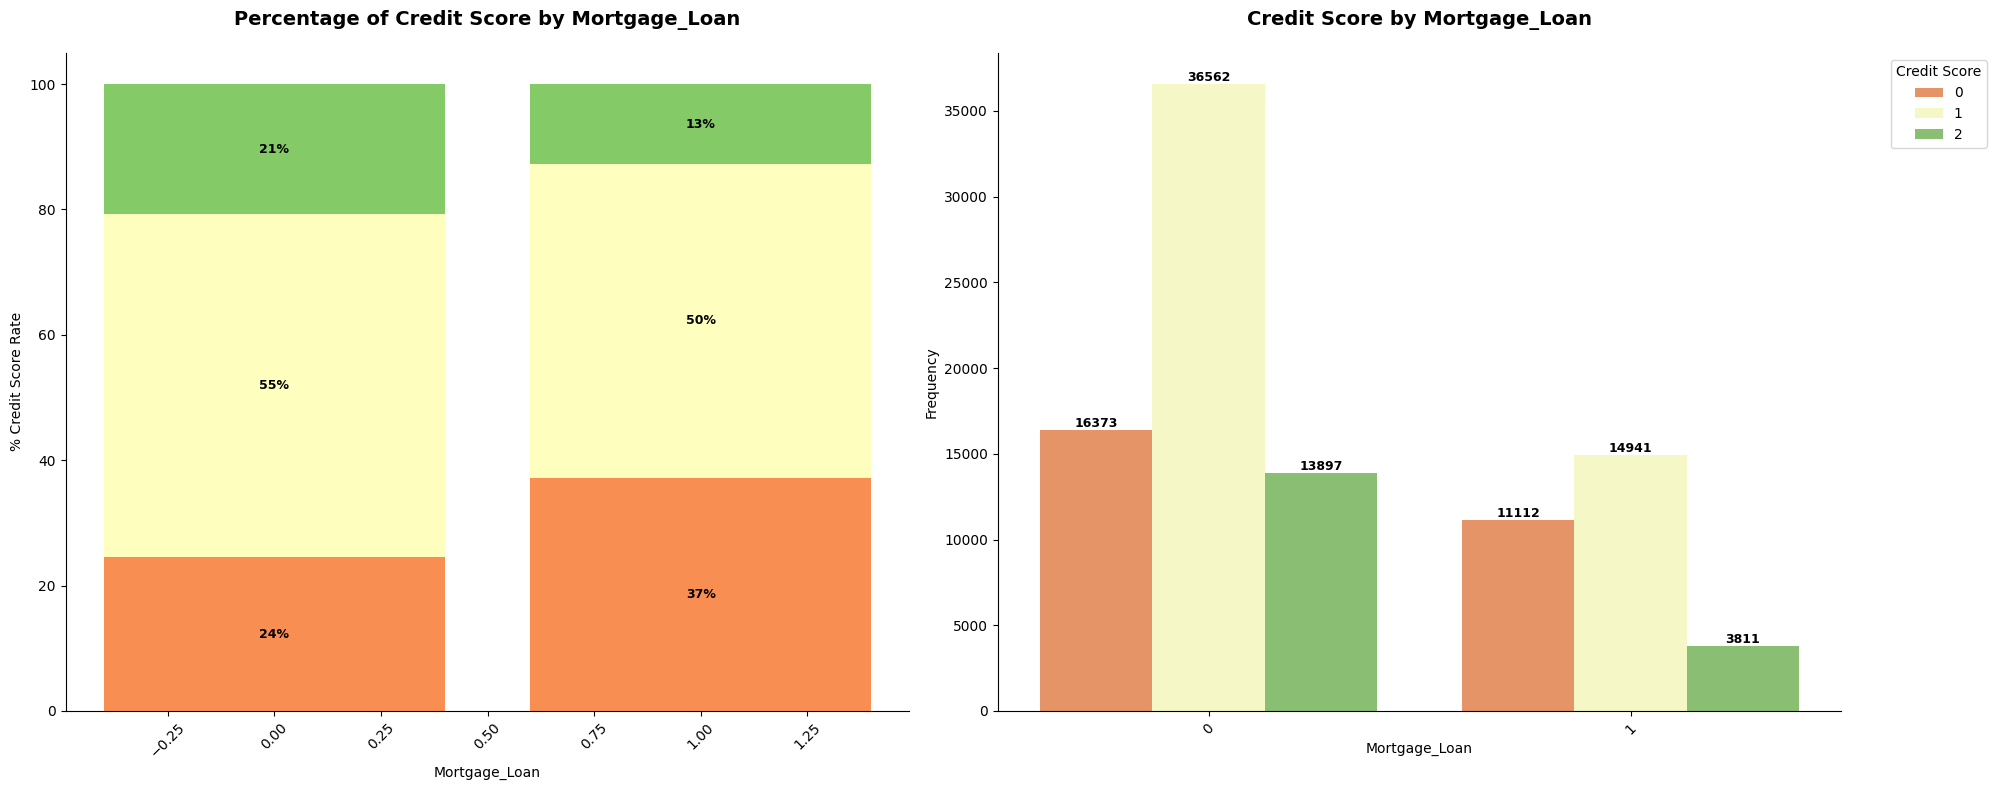


🔍 Chi-Square Test of Independence: 'Mortgage_Loan' vs. 'credit_score'
Chi-squared statistic: 1985.106
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Mortgage_Loan' and 'credit_score'.

📈 Standardized Residuals:
credit_score       0     1      2
Mortgage_Loan                    
0             -19.03  5.12  14.99
1              28.47 -7.65 -22.42


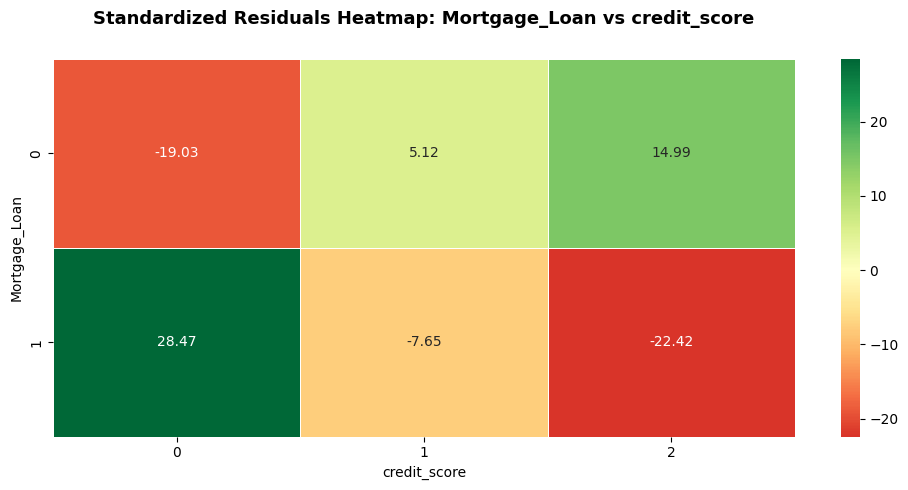

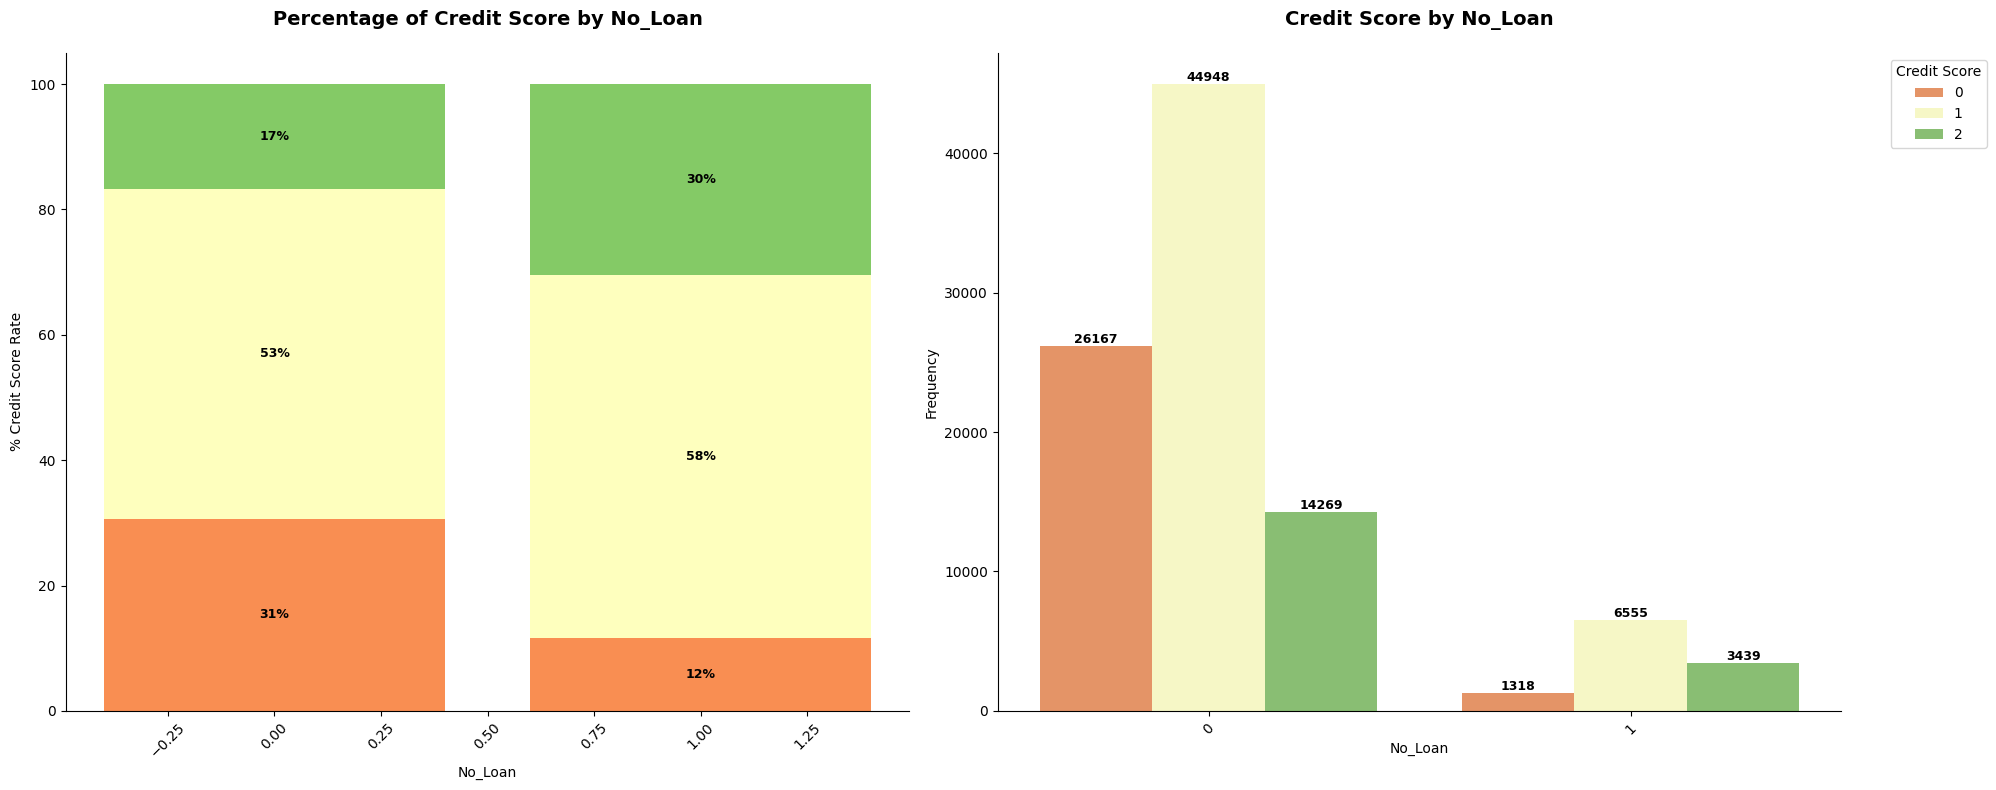


🔍 Chi-Square Test of Independence: 'No_Loan' vs. 'credit_score'
Chi-squared statistic: 2342.918
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'No_Loan' and 'credit_score'.

📈 Standardized Residuals:
credit_score      0     1      2
No_Loan                         
0             12.18 -2.48 -10.94
1            -33.46  6.83  30.04


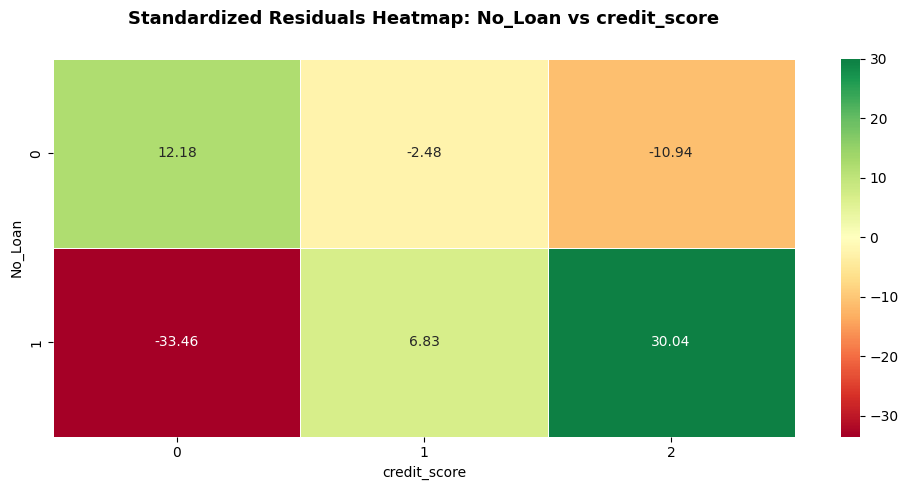

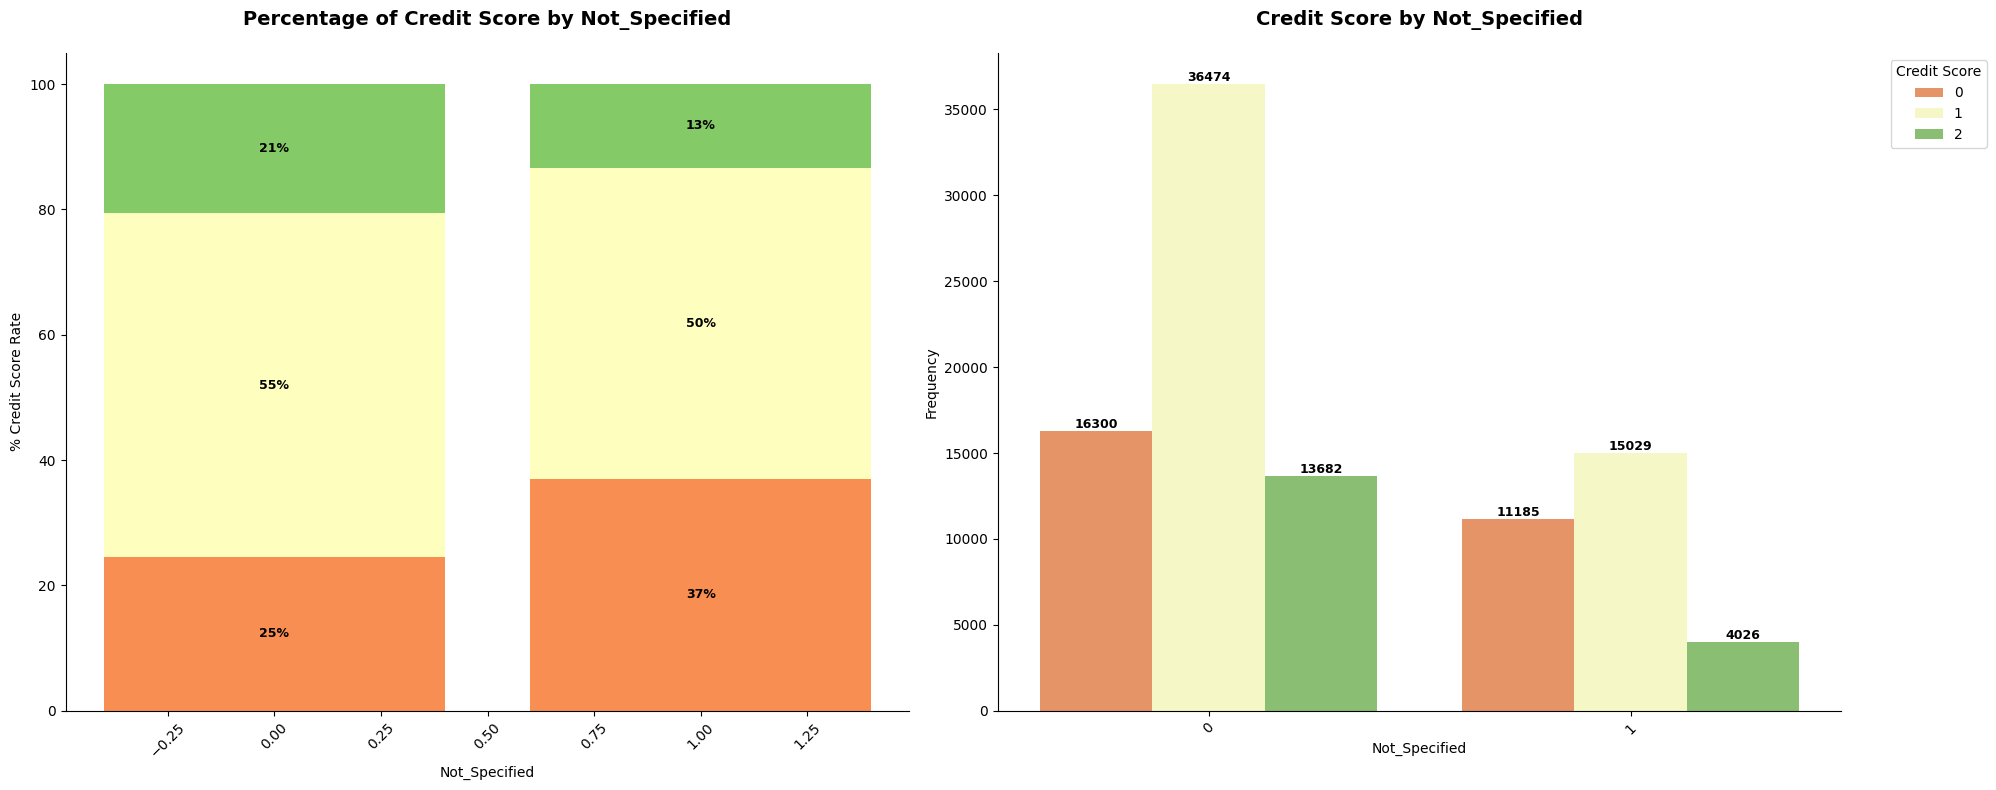


🔍 Chi-Square Test of Independence: 'Not_Specified' vs. 'credit_score'
Chi-squared statistic: 1840.627
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Not_Specified' and 'credit_score'.

📈 Standardized Residuals:
credit_score       0     1      2
Not_Specified                    
0             -18.84  5.73  13.70
1              27.93 -8.49 -20.32


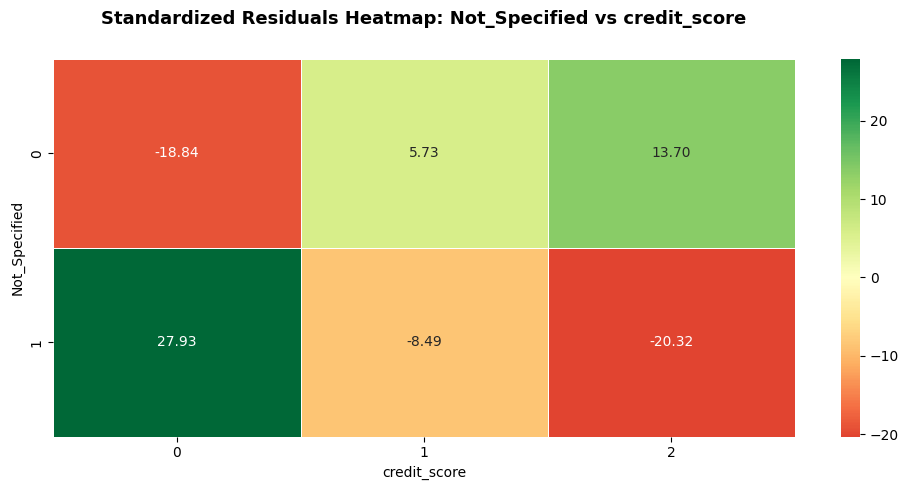

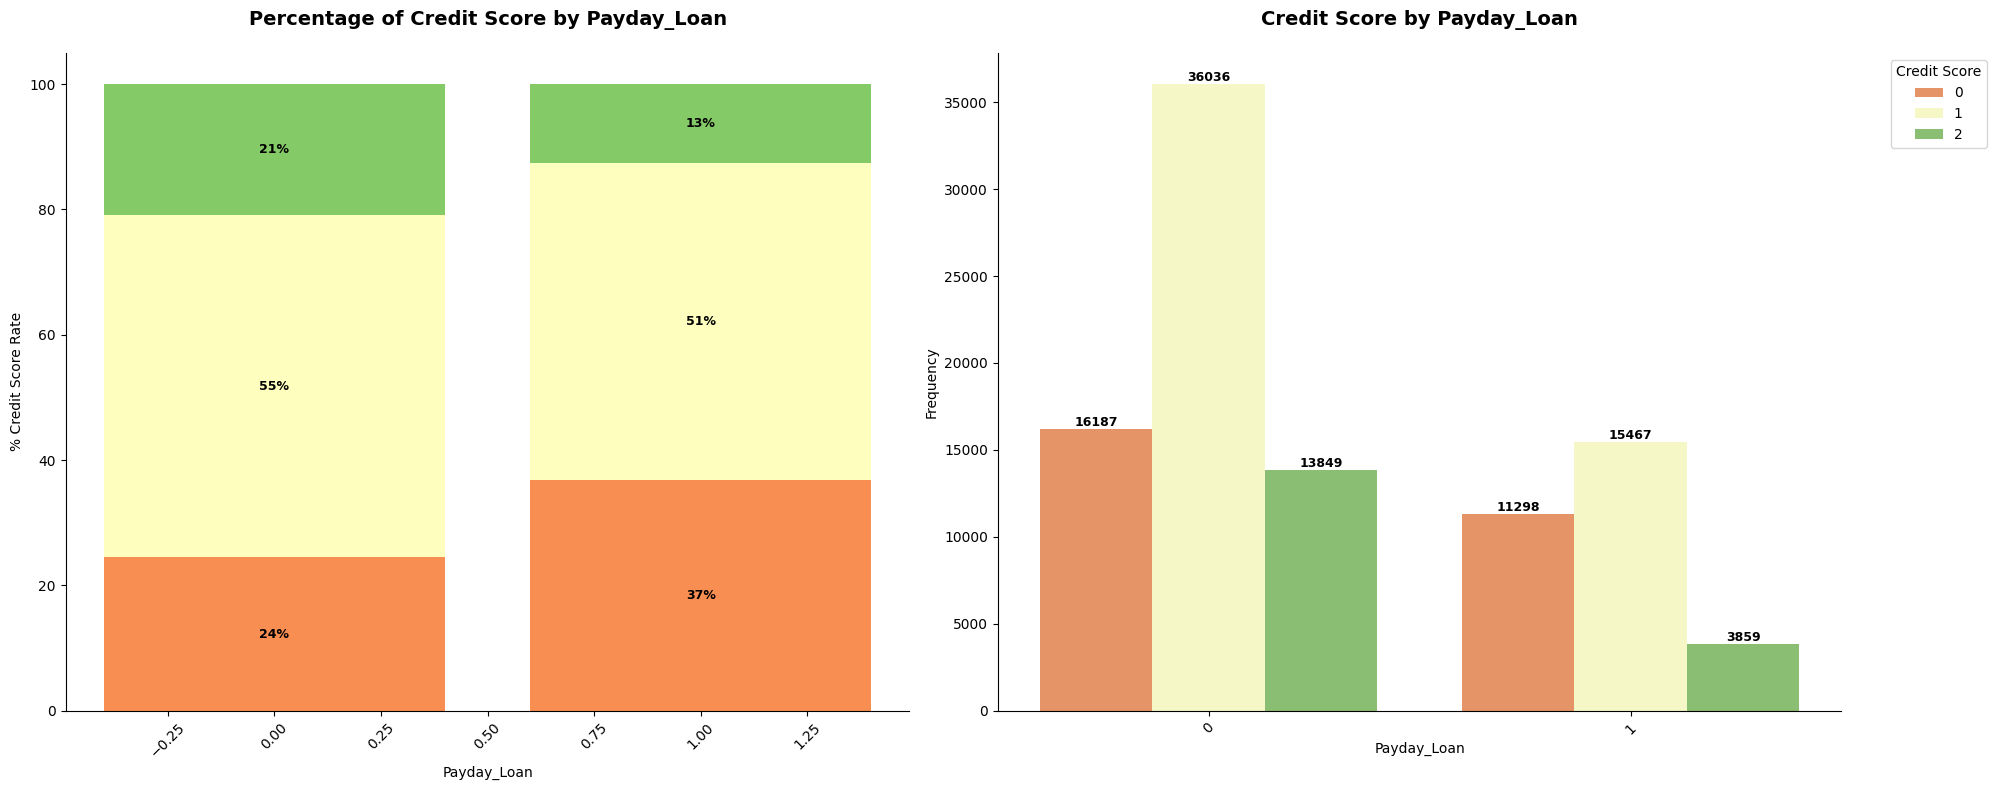


🔍 Chi-Square Test of Independence: 'Payday_Loan' vs. 'credit_score'
Chi-squared statistic: 1993.167
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Payday_Loan' and 'credit_score'.

📈 Standardized Residuals:
credit_score      0     1      2
Payday_Loan                     
0            -18.92  4.50  15.90
1             27.80 -6.61 -23.36


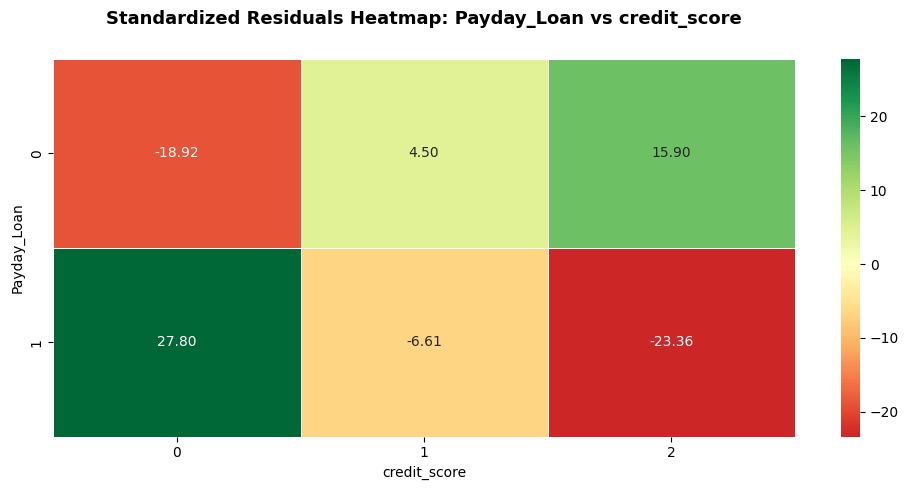

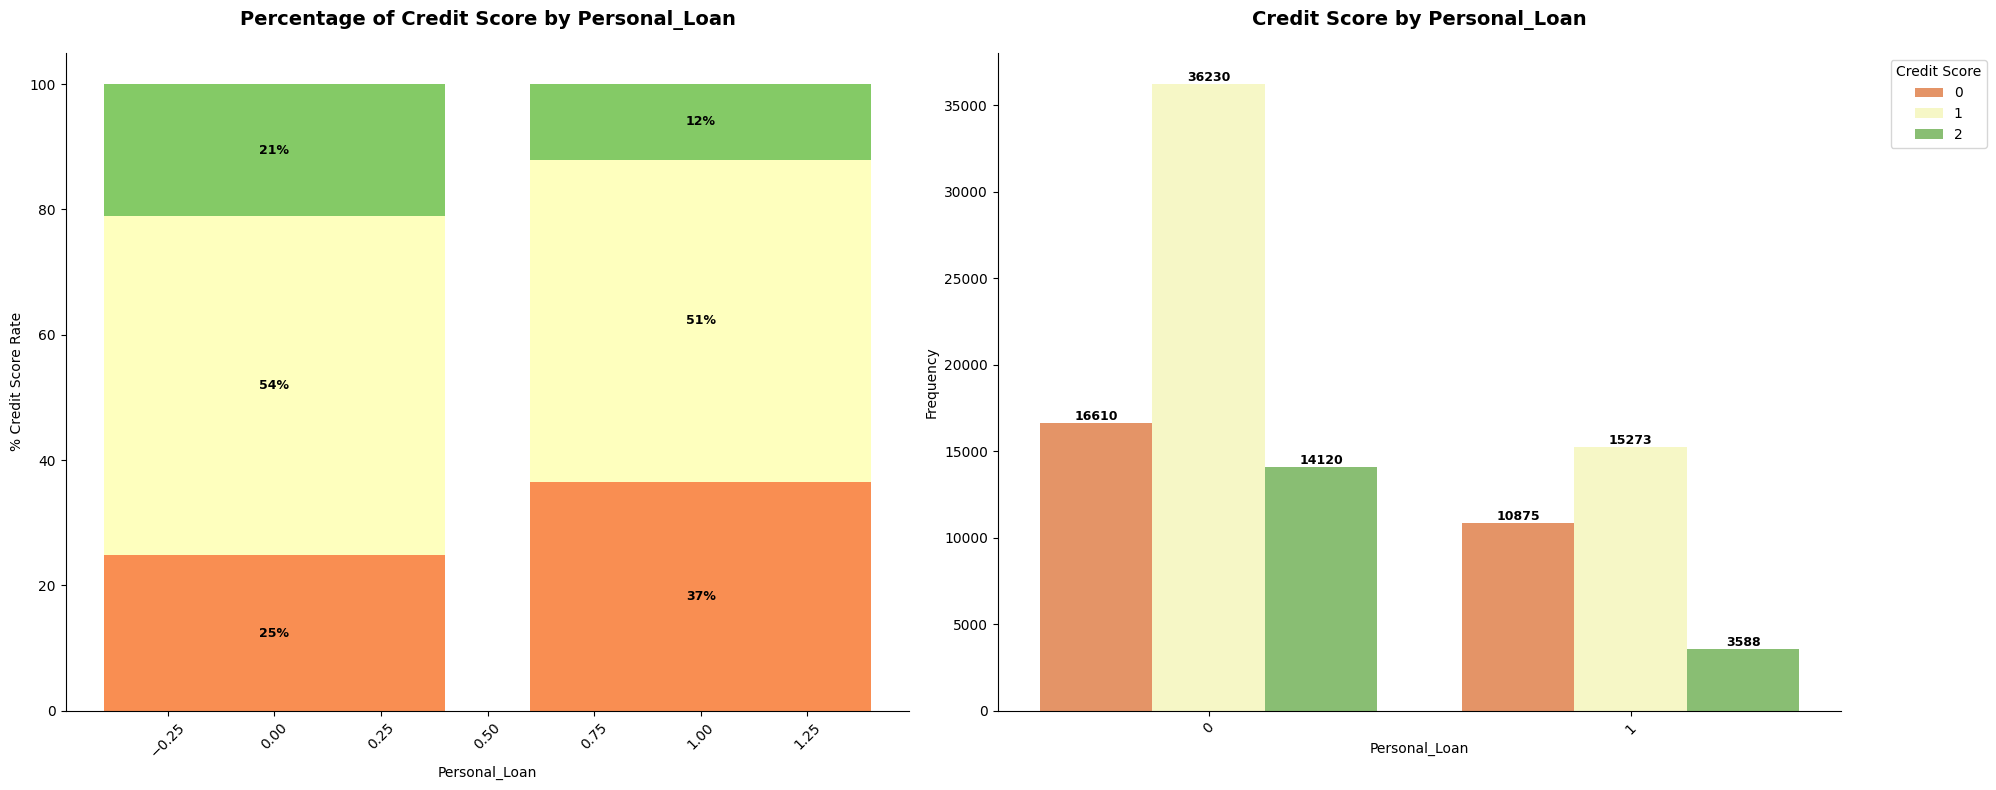


🔍 Chi-Square Test of Independence: 'Personal_Loan' vs. 'credit_score'
Chi-squared statistic: 1947.073
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Personal_Loan' and 'credit_score'.

📈 Standardized Residuals:
credit_score       0     1      2
Personal_Loan                    
0             -17.56  2.99  16.77
1              26.35 -4.49 -25.17


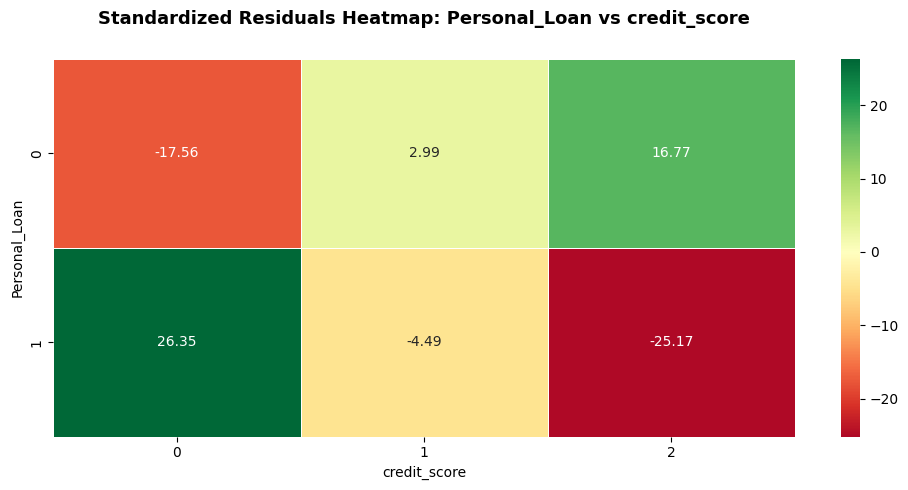

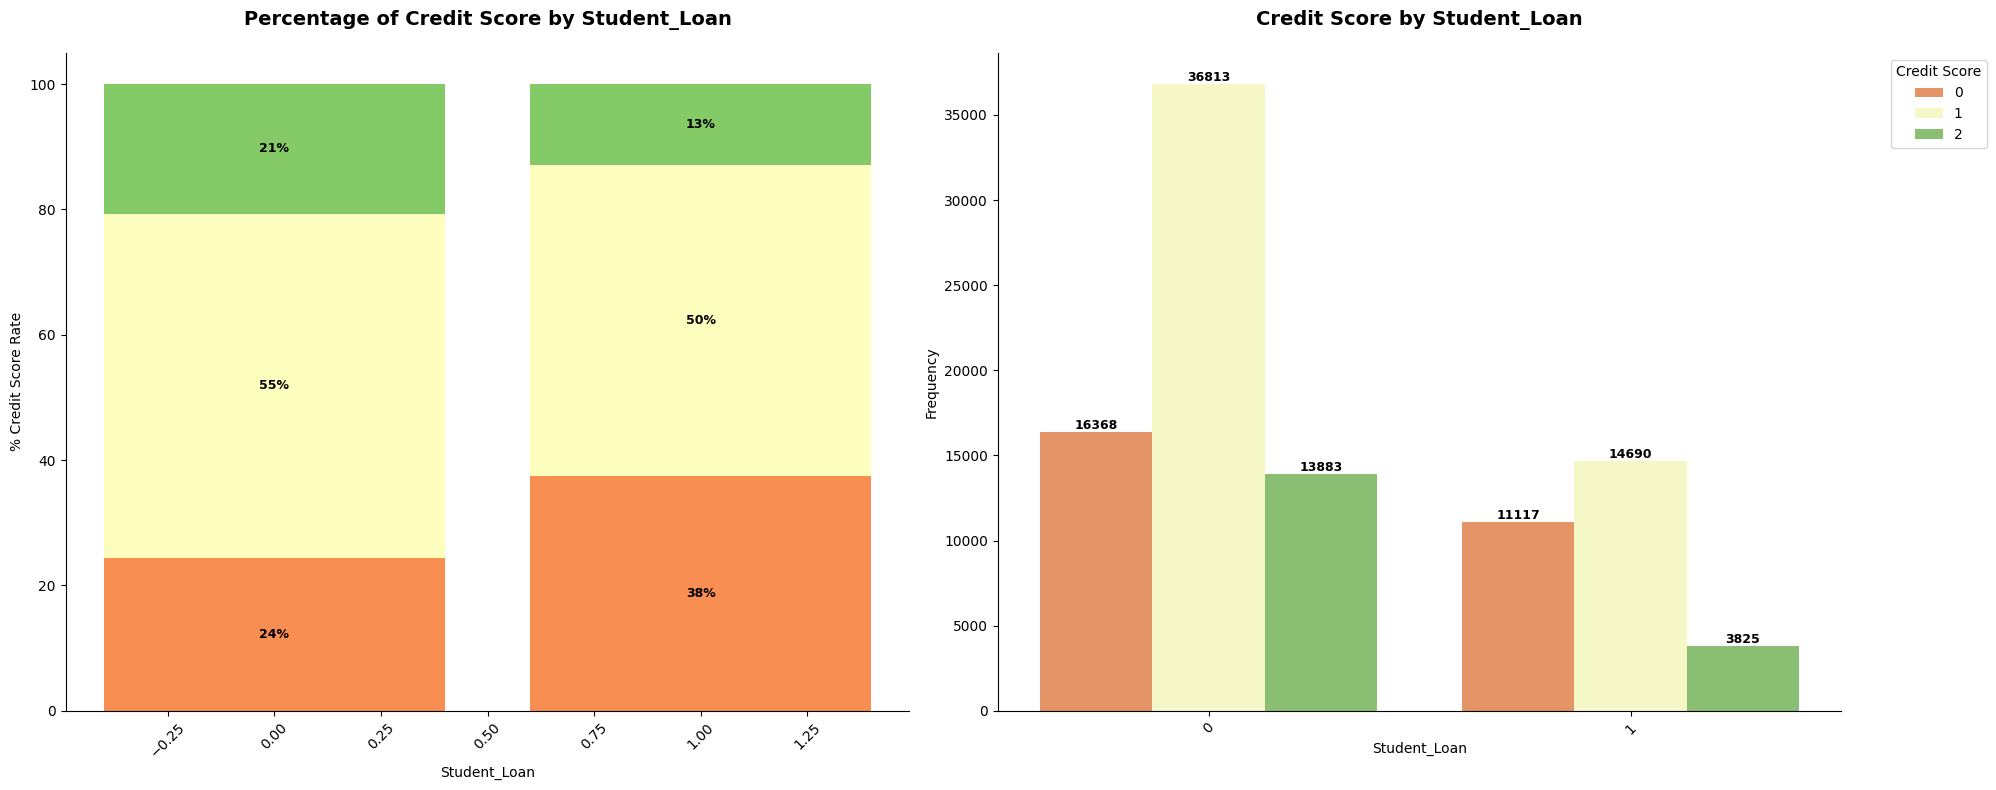


🔍 Chi-Square Test of Independence: 'Student_Loan' vs. 'credit_score'
Chi-squared statistic: 2033.350
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Student_Loan' and 'credit_score'.

📈 Standardized Residuals:
credit_score      0     1      2
Student_Loan                    
0            -19.51  5.78  14.45
1             29.36 -8.70 -21.74


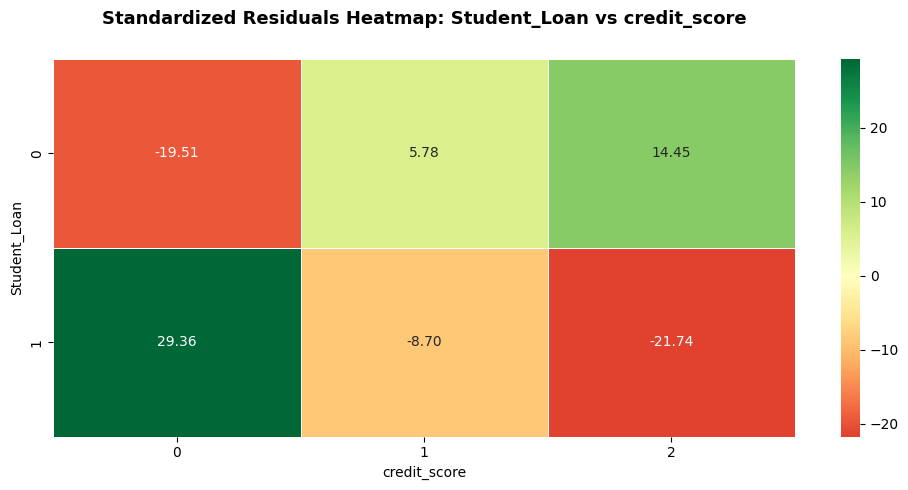

In [87]:
for feature in new_cat_features:
    bivariate_percent_plot(cat=feature, df= df_pre, rot=45)

## Re-checking Skew

In [88]:
skew_feature, skew_df = check_skewness(data=df_pre, numerical_features=num_features)


🔍 Skewness for dataset:
---------------------------------------------------------------------------
Feature                             | Skewness   | Remark
---------------------------------------------------------------------------
amount_invested_monthly             |  +4.306335 | Highly skewed
total_emi_per_month                 |  +4.142171 | Highly skewed
monthly_balance                     |  +1.570108 | Highly skewed
outstanding_debt                    |  +1.242221 | Highly skewed
annual_income                       |  +1.117978 | Highly skewed
monthly_inhand_salary               |  +1.116250 | Highly skewed
delay_from_due_date                 |  +0.992354 | Moderately skewed
changed_credit_limit                |  +0.661909 | Moderately skewed
interest_rate                       |  +0.520011 | Moderately skewed
num_of_loan                         |  +0.469714 | Approximately symmetric
num_credit_inquiries                |  +0.437872 | Approximately symmetric
num_credit_card   

In [89]:
from sklearn.preprocessing import PowerTransformer

def handle_skewed_features(
    df,
    zero_threshold=0.9,
    skew_threshold=0.5,
    num_features=None,
    exclude_cols=None
    
):
    """
    Handle skewed numerical features by applying appropriate transformations,
    *forcing* certain columns to be transformed even if they don't exceed skew_threshold.

    Parameters:
    - df: pandas.DataFrame
    - zero_threshold: float (default=0.9)
    - skew_threshold: float (default=0.5)
    - num_features: list of numerical columns to consider
    - exclude_cols: list of columns to skip entirely
    - dataset: Name of dataset

    Returns:
    - df: transformed DataFrame
    - transformed_cols: list of new feature names
    - high_zero_cols: list of sparse features (> zero_threshold)
    - skewed_cols: list of auto‑detected skewed features
    - pt_dict: dict mapping each YJ‑transformed col → its PowerTransformer
    """
    df = df.copy()
    if num_features is None:
        raise ValueError("`num_features` must be provided")
    if exclude_cols is None:
        exclude_cols = []


    # 1) pick the numeric cols to scan
    numerical_cols = [c for c in num_features if c not in exclude_cols]

    # 2) detect ultra‑sparse
    zero_ratios = (df[numerical_cols] == 0).sum() / len(df)
    high_zero_cols = zero_ratios[zero_ratios > zero_threshold].index.tolist()

    # 3) compute skew
    skew_vals = df[numerical_cols].apply(lambda s: skew(s.dropna()))
    auto_skewed = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()

    # 4) union these with your forced list
    to_transform = list(set(auto_skewed))

    transformed_cols = []
    dropped_cols     = []
    pt_dict          = {}

    for col in to_transform:
        # if it's sparse → binary+log
        if col in high_zero_cols:
            df[f"Has_{col}"] = (df[col] > 0).astype(int)
            df[f"Log_{col}"] = df[col].map(lambda x: np.log1p(x) if x > 0 else 0)
            transformed_cols += [f"Has_{col}", f"Log_{col}"]
            dropped_cols.append(col)
        # if it's discrete small‑cardinality, skip transform but keep
        elif df[col].nunique() <= 5:
            # do nothing (we still keep raw col in df)
            continue
        # otherwise apply Yeo‑Johnson
        else:
            pt = PowerTransformer(method="yeo-johnson")
            arr = df[[col]].values  # shape (n,1)
            df[f"PT_{col}"] = pt.fit_transform(arr)
            pt_dict[col] = pt
            transformed_cols.append(f"PT_{col}")
            dropped_cols.append(col)

    # drop originals for any column we did transform
    df.drop(columns=dropped_cols, inplace=True)

    return df, transformed_cols, high_zero_cols, auto_skewed, pt_dict

In [90]:
processed_df, transformed_columns, sparse_columns, skewed_columns, pt_dict_train = handle_skewed_features(df=df_pre, num_features=skew_feature)
num_features = ["age", "PT_annual_income", "PT_monthly_inhand_salary", "credit_history_age", "PT_total_emi_per_month", "num_bank_accounts", "num_credit_card", "PT_interest_rate", 
                 "num_of_loan", "PT_delay_from_due_date", "num_of_delayed_payment", "PT_changed_credit_limit", "num_credit_inquiries", "PT_outstanding_debt", 
                 "credit_utilization_ratio", "PT_amount_invested_monthly", "PT_monthly_balance"]
skew_feature, skew_df = check_skewness(data=processed_df, numerical_features=num_features)


🔍 Skewness for dataset:
---------------------------------------------------------------------------
Feature                             | Skewness   | Remark
---------------------------------------------------------------------------
num_of_loan                         |  +0.469714 | Approximately symmetric
num_credit_inquiries                |  +0.437872 | Approximately symmetric
PT_amount_invested_monthly          |  -0.245341 | Approximately symmetric
num_credit_card                     |  +0.229110 | Approximately symmetric
age                                 |  +0.192620 | Approximately symmetric
num_of_delayed_payment              |  -0.172589 | Approximately symmetric
num_bank_accounts                   |  -0.172356 | Approximately symmetric
PT_monthly_balance                  |  +0.107430 | Approximately symmetric
credit_history_age                  |  -0.080683 | Approximately symmetric
PT_changed_credit_limit             |  +0.077641 | Approximately symmetric
PT_interest_rat

**Observations from the Skewness Table (`processed_df`):**

**Approximately Symmetric**:

* Several features, such as:

  * `PT_amount_invested_monthly`, `PT_monthly_balance`, `PT_interest_rate`, `PT_total_emi_per_month`, `PT_outstanding_debt`, `PT_delay_from_due_date`, `PT_monthly_inhand_salary`, `PT_annual_income`  and `PT_changed_credit_limit` less than 0.5.
  * This indicates that **Yeo-Johnson transformation was effective** for these features.

## Re-check Outliers

In [91]:
checking_outlier(list_feature=num_features, df=processed_df, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,PT_total_emi_per_month,684
1,PT_delay_from_due_date,381
2,PT_changed_credit_limit,685
3,num_credit_inquiries,704
4,PT_outstanding_debt,208
5,credit_utilization_ratio,4
6,PT_amount_invested_monthly,5305
7,PT_monthly_balance,4349


## Create Test Set

🔴 Suppose you chatted with experts who told you that the **PT_annual_income** is a very important attribute to predict **credit_score**. <br>
🔴 We may want to ensure that the test set is representative of the various categories of study hours per day in the whole dataset. Since the study hours per day is a continuous numerical attribute, we first need to create an category attribute.

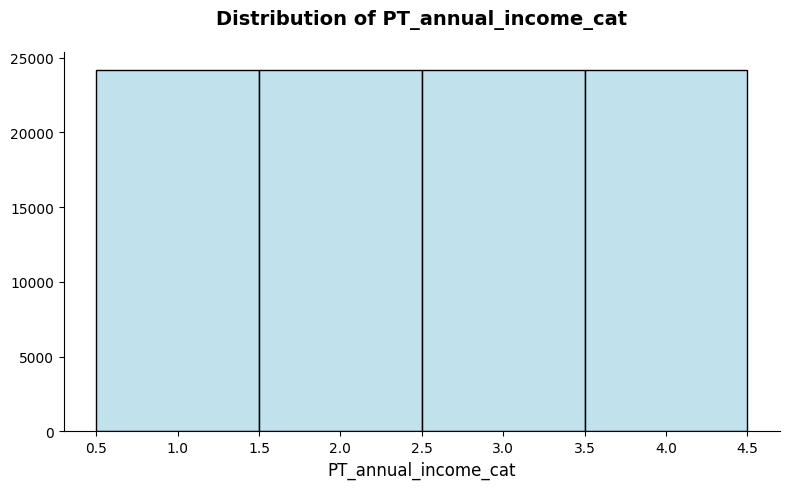

In [92]:
processed_df["PT_annual_income_cat"] = pd.qcut(processed_df["PT_annual_income"],
                                              q=4,
                                              labels=[1, 2, 3, 4])

plt.figure(figsize=(8, 5))
sns.histplot(data=processed_df, x="PT_annual_income_cat", color="lightblue", edgecolor="black")
sns.despine(top=True, right=True, left=False, bottom=False)
plt.title("Distribution of PT_annual_income_cat", fontsize=14, weight="bold",pad=20)
plt.xlabel("PT_annual_income_cat", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [93]:
split = StratifiedShuffleSplit(n_splits=Config.N_SPLIT, test_size=Config.TEST_SIZE, random_state=Config.SEED)
for train_index, val_index in split.split(processed_df, processed_df["PT_annual_income_cat"]):
    start_train_set = processed_df.loc[train_index]
    start_val_set = processed_df.loc[val_index]

# Now we should remove the listening_time_cat attribute so the data is back to its original state:
for set_ in (start_train_set, start_val_set): 
    set_.drop("PT_annual_income_cat", axis=1, inplace=True)

## Scale and Encode

In [94]:
df_new = start_train_set.drop("credit_score", axis=1)
df_label = start_train_set["credit_score"].copy()

list_standard = ["age", "PT_annual_income", "PT_monthly_inhand_salary", "credit_history_age", "num_bank_accounts", "num_credit_card", 
                 "PT_interest_rate", "num_of_loan", "num_of_delayed_payment"]
list_robust = ["PT_total_emi_per_month", "PT_delay_from_due_date", "PT_changed_credit_limit", "num_credit_inquiries", 
               "PT_outstanding_debt", "credit_utilization_ratio", "PT_amount_invested_monthly", "PT_monthly_balance"]

standard_transfomer = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("imputer", SimpleImputer(strategy="median"))
])

robust_transfomer = Pipeline(steps=[
    ("scaler", RobustScaler()),
    ("imputer", SimpleImputer(strategy="median"))
])

cat_transfomer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num_standard", standard_transfomer, list_standard),
        ("num_robust", robust_transfomer, list_robust),
        ("cat", cat_transfomer, cat_features),
    ]
)

preprocessor.fit(df_new)

df_train_new_prepared = preprocessor.transform(df_new)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
clean_features = [col.replace("num_standard__", "").replace("num_robust__", "").replace("cat__", "").replace("PT_", "") for col in list_feature_prepared]
clean_features

['age',
 'annual_income',
 'monthly_inhand_salary',
 'credit_history_age',
 'num_bank_accounts',
 'num_credit_card',
 'interest_rate',
 'num_of_loan',
 'num_of_delayed_payment',
 'total_emi_per_month',
 'delay_from_due_date',
 'changed_credit_limit',
 'num_credit_inquiries',
 'outstanding_debt',
 'credit_utilization_ratio',
 'amount_invested_monthly',
 'monthly_balance',
 'occupation_Accountant',
 'occupation_Architect',
 'occupation_Developer',
 'occupation_Doctor',
 'occupation_Engineer',
 'occupation_Entrepreneur',
 'occupation_Journalist',
 'occupation_Lawyer',
 'occupation_Manager',
 'occupation_Mechanic',
 'occupation_Media_Manager',
 'occupation_Musician',
 'occupation_Scientist',
 'occupation_Teacher',
 'occupation_Writer',
 'credit_mix_Bad',
 'credit_mix_Good',
 'credit_mix_Standard',
 'payment_of_min_amount_No',
 'payment_of_min_amount_Yes',
 'payment_behaviour_High_spent_Large_value_payments',
 'payment_behaviour_High_spent_Medium_value_payments',
 'payment_behaviour_High_sp

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Define Metric</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Define Metric
    </h1>
</div>

| Metric        | Definition                                                  | Meaning in Attrition Context                                          |
| ------------- | ----------------------------------------------------------- | --------------------------------------------------------------------- |
| **Recall**    | $\frac{TP}{TP + FN}$                                        | **Most important** – how many true leavers you can catch              |
| **Precision** | $\frac{TP}{TP + FP}$                                        | Among predicted leavers, how many are actually correct                |
| **Accuracy**  | $\frac{TP + TN}{Total}$                                     | Can be misleading with imbalanced data (e.g., <20% attrition)         |
| **F1-score**  | $\frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$ | Balanced trade-off between Precision and Recall                       |
| **AUC-ROC**   | Area under ROC Curve                                        | Measures ability to distinguish leavers vs. stayers at all thresholds |


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>

In [95]:
def shap_plot(model, X_test, list_feature, type = None):
     # https://towardsdatascience.com/using-shap-values-to-explain-how-your-machine-learning-model-works-732b3f40e137/
    if hasattr(X_test, "toarray"):
        X_test = X_test.toarray()
    X_test_sample = pd.DataFrame(X_test, columns=list_feature)
    explainer = shap.Explainer(model.predict, X_test_sample)
    shap_values = explainer(X_test_sample)
    if type =="bar":
        shap_importance = np.abs(shap_values.values).mean(axis=0)
        shap_df = pd.DataFrame({"feature": X_test_sample.columns, "importance": shap_importance})
        shap_df = shap_df.sort_values("importance", ascending=False).head(20)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=shap_df["importance"], y=shap_df["feature"], palette="viridis", order=shap_df["feature"])
        plt.xlabel("mean(|SHAP value|)")
        plt.title("SHAP Feature Importance", fontsize=14, weight="bold", pad=20)
        plt.tight_layout()
        plt.show()
    else:
        shap.summary_plot(shap_values, X_test_sample)

In [96]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score

def _get_scores(estimator, X):
    """Return y_score for plotting curves."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)
    elif hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    else:
        raise ValueError("Estimator does not support predict_proba or decision_function.")


def plot_ROC_confusionMatrix(estimator, X_val, y_val, figsize=(15, 6)):
    """
    Visualization layout:
    - [0,0]: ROC (Binary or Multiclass OvR)
    - [0,1]: Confusion Matrix
    - [1,0]: Precision-Recall (Binary or Multiclass OvR)
    - [1,1]: hidden
    """
    y_pred = estimator.predict(X_val)
    classes = np.array(sorted(np.unique(y_val)))
    n_classes = len(classes)

    y_score = _get_scores(estimator, X_val)

    # ===== Normalize binary shape =====
    if n_classes == 2:
        if y_score.ndim == 1:
            pos_scores = y_score
        elif y_score.ndim == 2 and y_score.shape[1] == 2:
            pos_scores = y_score[:, 1]
        elif y_score.ndim == 2 and y_score.shape[1] == 1:
            pos_scores = y_score[:, 0]
        else:
            pos_scores = y_score[:, -1]
    else:
        if y_score.ndim == 1:
            raise ValueError("Multiclass requires 2D y_score (n_samples, n_classes).")
        if hasattr(estimator, "classes_"):
            order = [np.where(estimator.classes_ == c)[0][0] for c in classes]
            y_score = y_score[:, order]

    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=figsize)

    # ===== (1) ROC curve =====
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_val, pos_scores, pos_label=classes.max())
        roc_auc = roc_auc_score(y_val, pos_scores)
        ax[0, 0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        ax[0, 0].plot([0, 1], [0, 1], linestyle="--")
        ax[0, 0].set_title("ROC Curve (Binary)", fontsize=13, weight="bold", pad=14)
        roc_auc_macro = float(roc_auc)
    else:
        y_val_bin = label_binarize(y_val, classes=classes)
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        roc_auc_macro = float(np.mean([roc_auc[i] for i in range(n_classes)]))

        order = np.argsort([roc_auc[i] for i in range(n_classes)])
        picks = [order[0], order[n_classes // 2], order[-1]] if n_classes >= 3 else list(range(n_classes))
        for i in picks:
            ax[0, 0].plot(fpr[i], tpr[i], label=f"class {classes[i]} AUC = {roc_auc[i]:.3f}")

        ax[0, 0].plot([0, 1], [0, 1], linestyle="--")
        ax[0, 0].set_title(f"ROC Curve (Multiclass, macro AUC = {roc_auc_macro:.3f})", fontsize=13, weight="bold", pad=14)
    ax[0, 0].set_xlabel("False Positive Rate")
    ax[0, 0].set_ylabel("True Positive Rate")
    ax[0, 0].legend(loc="lower right")

    # ===== (2) Confusion Matrix =====
    cm = confusion_matrix(y_val, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0, 1],
                xticklabels=classes, yticklabels=classes)
    ax[0, 1].set_title("Confusion Matrix", fontsize=13, weight="bold", pad=14)
    ax[0, 1].set_xlabel("Predicted")
    ax[0, 1].set_ylabel("Actual")

    # ===== (3) Precision–Recall curve =====
    if n_classes == 2:
        precision_curve, recall_curve, _ = precision_recall_curve(y_val, pos_scores, pos_label=classes.max())
        pr_ap = average_precision_score(y_val, pos_scores)
        ax[1, 0].plot(recall_curve, precision_curve, label=f"AP = {pr_ap:.3f}")
        pr_auc_macro = float(pr_ap)
        ax[1, 0].set_title("Precision–Recall (Binary)", fontsize=13, weight="bold", pad=14)
    else:
        y_val_bin = label_binarize(y_val, classes=classes)
        precision, recall, pr_ap = {}, {}, {}
        for i in range(n_classes):
            precision[i], recall[i], _ = precision_recall_curve(y_val_bin[:, i], y_score[:, i])
            pr_ap[i] = average_precision_score(y_val_bin[:, i], y_score[:, i])

        pr_auc_macro = float(np.mean([pr_ap[i] for i in range(n_classes)]))

        order_pr = np.argsort([pr_ap[i] for i in range(n_classes)])
        picks_pr = [order_pr[0], order_pr[n_classes // 2], order_pr[-1]] if n_classes >= 3 else list(range(n_classes))
        for i in picks_pr:
            ax[1, 0].plot(recall[i], precision[i], label=f"class {classes[i]} AP = {pr_ap[i]:.3f}")

        ax[1, 0].set_title(f"Precision–Recall (Multiclass, macro AP = {pr_auc_macro:.3f})", fontsize=13, weight="bold", pad=14)

    ax[1, 0].set_xlabel("Recall")
    ax[1, 0].set_ylabel("Precision")
    ax[1, 0].legend(loc="lower left")

    # ===== (4) Hide empty cell =====
    ax.flat[-1].set_visible(False)
    plt.tight_layout()
    plt.show()

    # ===== Classification Report =====
    print(classification_report(y_val, y_pred, digits=3))

    metrics = {
        "roc_auc_macro": float(roc_auc_macro),
        "pr_auc_macro": float(pr_auc_macro),
        "accuracy": float(accuracy_score(y_val, y_pred))
    }
    return metrics

In [97]:
# ===== evaluate_model keeps the same API, adds return metrics =====
def evaluate_model(model, X_train, X_val, y_train, y_val, figsize=(15, 6), show_shap_plot=False):
    print(f"Evaluating {model.__class__.__name__}...")
    model.fit(X_train, y_train)
    metrics = plot_ROC_confusionMatrix(estimator=model, X_val=X_val, y_val=y_val, figsize=figsize)

    if show_shap_plot:
        try:
            # Limit to 200 samples for faster SHAP computation
            shap_sample = X_val.iloc[:200] if hasattr(X_val, "iloc") else X_val[:200]
            shap_plot(model=model, X_test=shap_sample, list_feature=list_feature_prepared)
        except Exception as e:
            print("SHAP plot skipped:", e)

    return metrics

In [98]:
X_val = start_val_set.drop("credit_score", axis=1)
y_val = start_val_set["credit_score"].copy()
X_val_prepared = preprocessor.transform(X_val)

### CatBoostClassifier

Evaluating CatBoostClassifier...


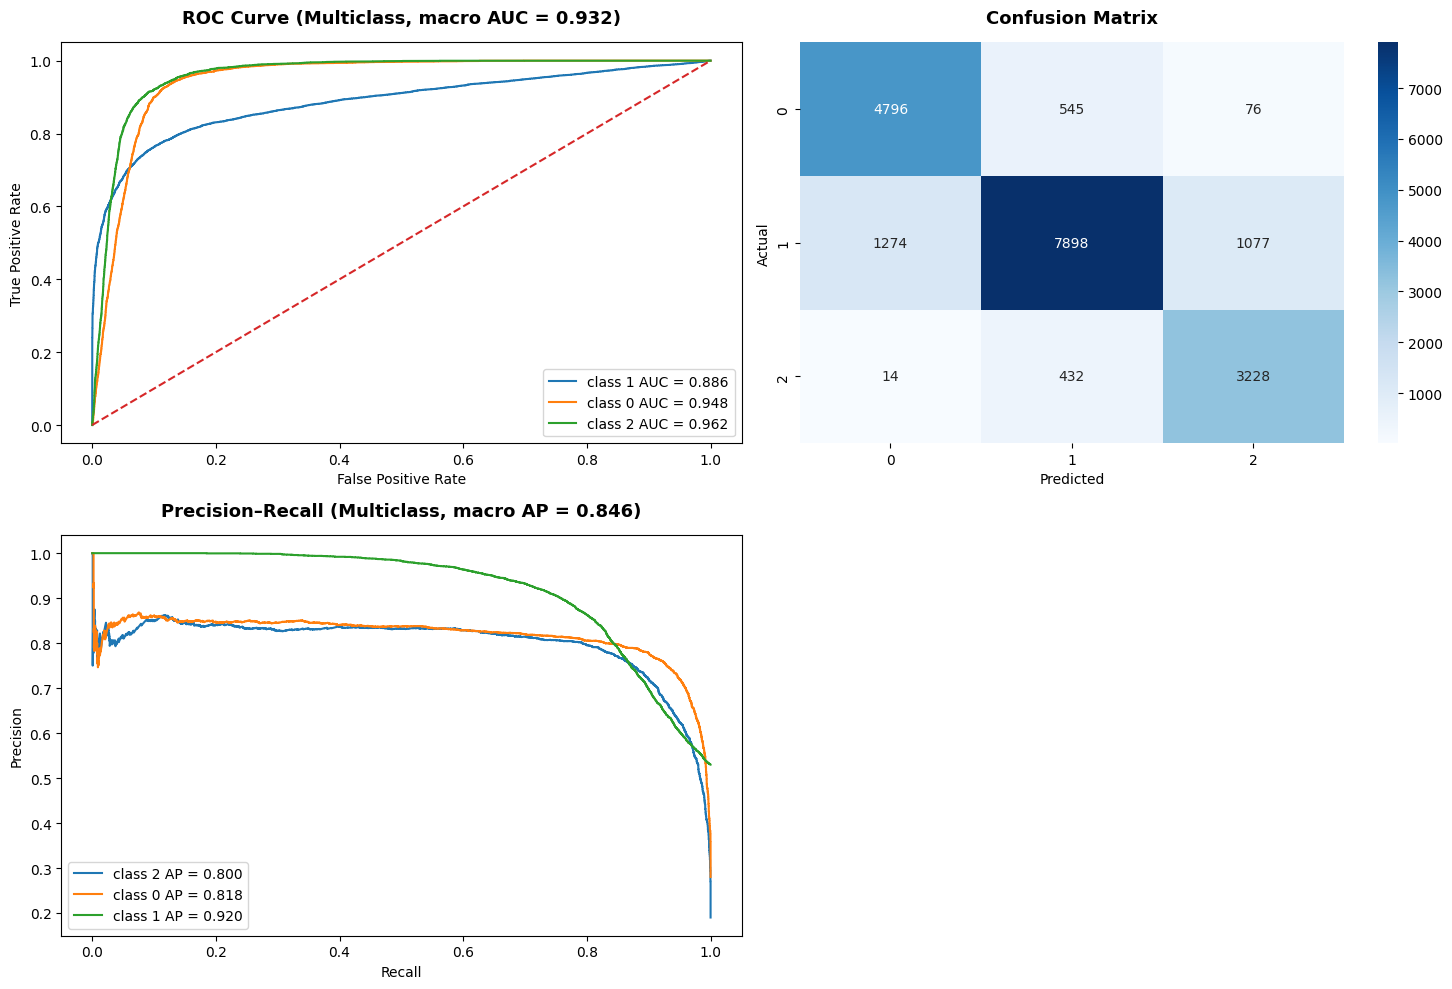

              precision    recall  f1-score   support

           0      0.788     0.885     0.834      5417
           1      0.890     0.771     0.826     10249
           2      0.737     0.879     0.801      3674

    accuracy                          0.823     19340
   macro avg      0.805     0.845     0.820     19340
weighted avg      0.832     0.823     0.824     19340



{'roc_auc_macro': 0.9318838627541477,
 'pr_auc_macro': 0.8460239077206992,
 'accuracy': 0.8232678386763185}

In [99]:
from catboost import CatBoostClassifier

param_cb = {
    "iterations": 1760, 
    "depth": 10, 
    "learning_rate": 0.050710196069766525, 
    "l2_leaf_reg": 2.4556736549180025, 
    "random_strength": 0.9096205868106635, 
    "bagging_temperature": 0.5909608232070956, 
    "border_count": 47,
    "loss_function": "MultiClass",   # Multi-class
    "eval_metric": "MultiClass",     # CatBoost built-in metric
    "verbose": 0,
    "random_seed": Config.SEED,
    "auto_class_weights":"Balanced",
    "bootstrap_type": "Bayesian",
    "task_type": "CPU",
    "thread_count": -1,
}

model_cb = CatBoostClassifier(**param_cb)

evaluate_model(model = model_cb, X_train=df_train_new_prepared, X_val=X_val_prepared,
                               y_train=df_label, y_val=y_val, figsize=(15, 10))

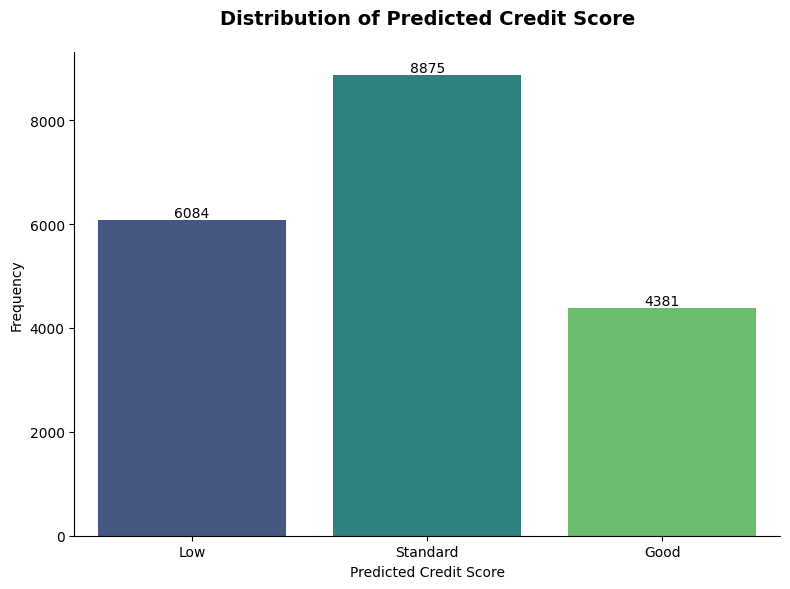

In [100]:
y_pred = model_cb.predict(X_val_prepared)

# Map the encoded predictions back to the original stress level categories
mapping = {0: "Low", 1: "Standard", 2: "Good"}
y_pred_mapped = pd.Series(np.array(y_pred).squeeze()).map(mapping)

# Plot the distribution of predicted stress levels
plt.figure(figsize=(8, 6))
ax = sns.countplot(x=y_pred_mapped, palette="viridis", order=["Low", "Standard", "Good"])
sns.despine(left=False, bottom=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", label_type="edge", fontsize=10)

plt.title("Distribution of Predicted Credit Score", weight="bold", fontsize=14, pad=20)
plt.ylabel("Frequency")
plt.xlabel("Predicted Credit Score")
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 1501it [03:49,  6.25it/s]                          


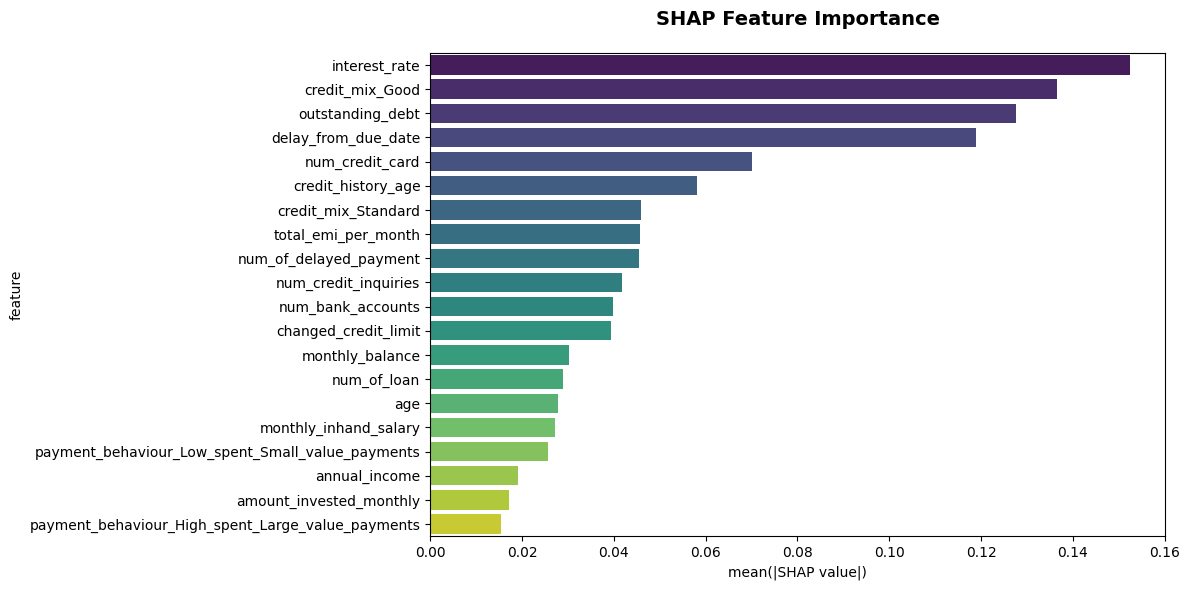

In [101]:
shap_sample = X_val_prepared.iloc[:1500] if isinstance(X_val_prepared, pd.DataFrame) else X_val_prepared[:1500]
shap_plot(model=model_cb, X_test=shap_sample, list_feature=clean_features, type="bar")

PermutationExplainer explainer: 1501it [03:52,  6.17it/s]                          


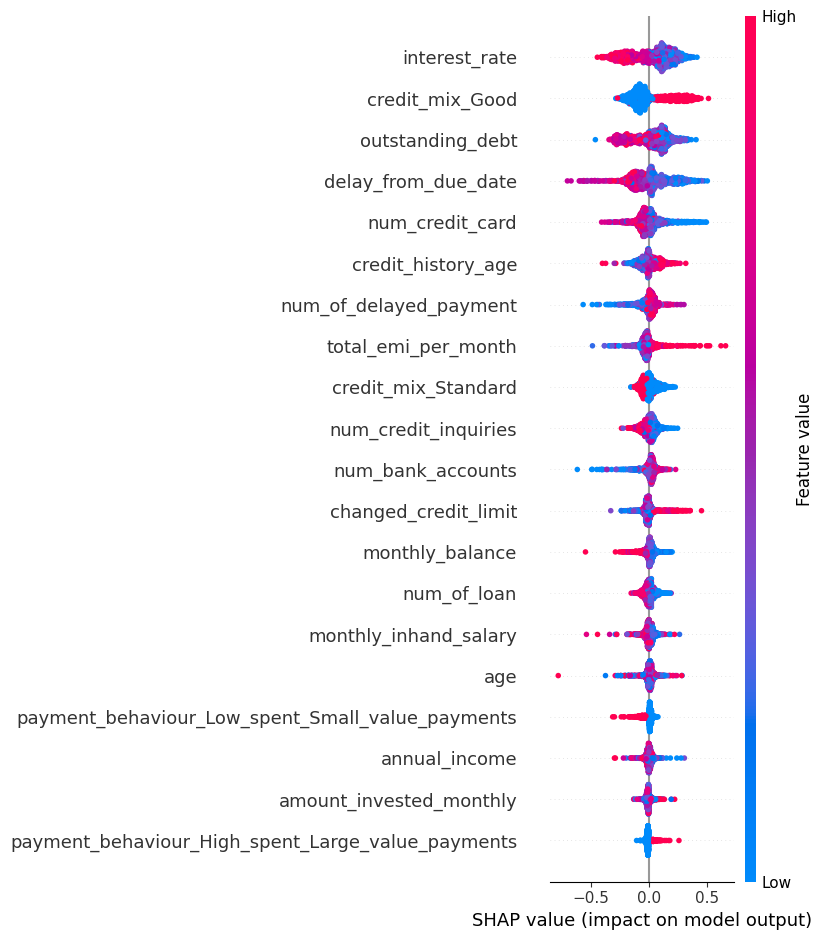

In [102]:
shap_sample = X_val_prepared.iloc[:1500] if isinstance(X_val_prepared, pd.DataFrame) else X_val_prepared[:1500]
shap_plot(model=model_cb, X_test=shap_sample, list_feature=clean_features)

**SHAP Summary — Key Drivers of Credit Score**

**Top Features Impacting Credit Score**

| Rank | Feature                    | Interpretation                                       |
| ---- | -------------------------- | ---------------------------------------------------- |
| 1️⃣  | **Interest Rate**          | Higher interest rates strongly reduce credit score.  |
| 2️⃣  | **Credit Mix (Good)**      | Diverse credit portfolios improve credit score.      |
| 3️⃣  | **Outstanding Debt**       | High debt levels negatively affect credit score.     |
| 4️⃣  | **Delay from Due Date**    | Frequent or long payment delays lower credit score.  |
| 5️⃣  | **Number of Credit Cards** | Moderate card ownership supports good credit health. |
| 6️⃣  | **Credit History Age**     | Longer credit history boosts score stability.        |
| 7️⃣  | **Total EMI per Month**    | High monthly obligations may increase risk.          |

**Insights**

* Financial behavior factors (interest rate, debt, delay) are the strongest risk indicators.
* Customers with **diverse credit mix** and **long credit history** maintain higher credit scores.
* Income, age, and investment behavior show **secondary but supportive effects**.

> **Credit performance is mainly driven by repayment discipline, debt level, and credit diversity.**

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
